**Tentang Dataset**
Dataset ini berisi 2.500 catatan parameter operasional mesin dan kejadian downtime dari beberapa lini perakitan. Dataset ini mencakup data sensor seperti tekanan, suhu, getaran, kecepatan, tegangan, dan torsi. Tujuannya kemungkinan untuk menganalisis atau memprediksi kegagalan mesin berdasarkan fitur-fitur tersebut untuk keperluan perawatan (maintenance) atau optimasi.

https://www.kaggle.com/datasets/uabhishek12345/machine-downtime

# **Warning Predictive Maintenance**
Membuat skor risiko failure untuk tiap mesin (misal “besok/next record akan failure?”) + alasan sensor apa yang paling memicu, supaya tim bisa melakukan preventive check sebelum downtime terjadi.

# **Baca Data**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import pandas as pd
import glob
import numpy as np

candidates = glob.glob("/content/drive/MyDrive/dataset/*Machine Downtime*")
print("Lokasi:", candidates)

df = pd.read_csv(candidates[0])
df.head()

Mounted at /content/drive
Lokasi: ['/content/drive/MyDrive/dataset/Machine Downtime.csv']


,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
0,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,335.0,24.055326,3.58,Machine_Failure
1,31-12-2021,Makino-L1-Unit1-2013,Shopfloor-L1,125.33,4.936892,6.196733,35.3,47.4,34.6,1.382,25.274,19856.0,368.0,14.202890,2.68,Machine_Failure
2,31-12-2021,Makino-L3-Unit1-2015,Shopfloor-L3,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,325.0,24.049267,3.55,Machine_Failure
3,31-05-2022,Makino-L2-Unit1-2015,Shopfloor-L2,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,360.0,25.860029,3.55,Machine_Failure
4,31-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,60.51,6.893182,6.141238,4.1,47.3,31.4,0.983,25.516,26526.0,354.0,25.515874,3.55,Machine_Failure


# **Cek bentuk & struktur data (sanity check)**

## --- **Sanity check: bentuk & struktur** ---

In [ ]:
print("Shape (baris, kolom):", df.shape)

Shape (baris, kolom): (2500, 16)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Date                             2500 non-null   object 
 1   Machine_ID                       2500 non-null   object 
 2   Assembly_Line_No                 2500 non-null   object 
 3   Hydraulic_Pressure(bar)          2490 non-null   float64
 4   Coolant_Pressure(bar)            2481 non-null   float64
 5   Air_System_Pressure(bar)         2483 non-null   float64
 6   Coolant_Temperature              2488 non-null   float64
 7   Hydraulic_Oil_Temperature(°C)    2484 non-null   float64
 8   Spindle_Bearing_Temperature(°C)  2493 non-null   float64
 9   Spindle_Vibration(µm)            2489 non-null   float64
 10  Tool_Vibration(µm)               2489 non-null   float64
 11  Spindle_Speed(RPM)               2494 non-null   float64
 12  Voltage(volts)      

## --- **Nama kolom** ---

In [ ]:
print("\nKolom:", list(df.columns))


Kolom: ['Date', 'Machine_ID', 'Assembly_Line_No', 'Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)', 'Downtime']


## --- **Tipe data tiap kolom** ---

In [ ]:
print("\nTipe data per kolom:")
print(df.dtypes)


Tipe data per kolom:
Date                                object
Machine_ID                          object
Assembly_Line_No                    object
Hydraulic_Pressure(bar)            float64
Coolant_Pressure(bar)              float64
Air_System_Pressure(bar)           float64
Coolant_Temperature                float64
Hydraulic_Oil_Temperature(°C)      float64
Spindle_Bearing_Temperature(°C)    float64
Spindle_Vibration(µm)              float64
Tool_Vibration(µm)                 float64
Spindle_Speed(RPM)                 float64
Voltage(volts)                     float64
Torque(Nm)                         float64
Cutting(kN)                        float64
Downtime                            object
dtype: object


## --- **Missing values per kolom** ---

In [ ]:
print("\nMissing values per kolom:")
print(df.isna().sum().sort_values(ascending=False))


Missing values per kolom:
Torque(Nm)                         21
Coolant_Pressure(bar)              19
Air_System_Pressure(bar)           17
Hydraulic_Oil_Temperature(°C)      16
Coolant_Temperature                12
Spindle_Vibration(µm)              11
Tool_Vibration(µm)                 11
Hydraulic_Pressure(bar)            10
Cutting(kN)                         7
Spindle_Bearing_Temperature(°C)     7
Voltage(volts)                      6
Spindle_Speed(RPM)                  6
Machine_ID                          0
Date                                0
Assembly_Line_No                    0
Downtime                            0
dtype: int64


## --- **Contoh nilai (beberapa unique) per kolom** ---

In [ ]:
print("\nContoh nilai per kolom (maks 5 unique):")
for col in df.columns:
    uniques = df[col].dropna().unique()[:5]
    print(f"- {col} ({df[col].dtype}): {uniques}")


Contoh nilai per kolom (maks 5 unique):
- Date (object): ['31-12-2021' '31-05-2022' '31-03-2022' '31-01-2022' '30-12-2021']
- Machine_ID (object): ['Makino-L1-Unit1-2013' 'Makino-L3-Unit1-2015' 'Makino-L2-Unit1-2015']
- Assembly_Line_No (object): ['Shopfloor-L1' 'Shopfloor-L3' 'Shopfloor-L2']
- Hydraulic_Pressure(bar) (float64): [ 71.04 125.33  71.12 139.34  60.51]
- Coolant_Pressure(bar) (float64): [6.93372491 4.93689186 6.83941316 4.57438201 6.89318192]
- Air_System_Pressure(bar) (float64): [6.28496451 6.19673253 6.65544845 6.56039396 6.14123775]
- Coolant_Temperature (float64): [25.6 35.3 13.1 24.4  4.1]
- Hydraulic_Oil_Temperature(°C) (float64): [46.  47.4 40.7 44.2 47.3]
- Spindle_Bearing_Temperature(°C) (float64): [33.4 34.6 33.  40.6 31.4]
- Spindle_Vibration(µm) (float64): [1.291 1.382 1.319 0.618 0.983]
- Tool_Vibration(µm) (float64): [26.492 25.274 30.608 30.791 25.516]
- Spindle_Speed(RPM) (float64): [25892. 19856. 19851. 18461. 26526.]
- Voltage(volts) (float64): [335. 368

## --- **Ringkasan numerik & kategorikal** ---

In [ ]:
print("\nDescribe (numerik):")
display(df.describe())


Describe (numerik):


,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN)
count,2490.000000,2481.000000,2483.000000,2488.000000,2484.000000,2493.000000,2489.000000,2489.000000,2494.000000,2494.000000,2479.000000,2493.000000
mean,101.409084,4.947058,6.499275,18.559887,47.618317,35.063698,1.009334,25.411975,20274.792302,348.996792,25.234968,2.782551
std,30.289301,0.997357,0.407279,8.554480,3.768674,3.764823,0.342898,6.437142,3852.660056,45.376024,6.138564,0.616688
min,-14.326454,0.325000,5.063480,4.100000,35.200000,22.600000,-0.461000,2.161000,0.000000,202.000000,0.000000,1.800000
25%,76.355000,4.462464,6.217987,10.400000,45.100000,32.500000,0.777000,21.089000,17919.000000,319.000000,21.666115,2.250000
50%,96.763486,4.939960,6.505191,21.200000,47.700000,35.100000,1.008000,25.455000,20137.500000,349.000000,24.647736,2.780000
75%,126.415727,5.518401,6.780550,25.600000,50.100000,37.600000,1.236000,29.790000,22501.750000,380.000000,30.514008,3.270000
max,191.000000,11.350000,7.973992,98.200000,61.400000,49.500000,2.000000,45.726000,27957.000000,479.000000,55.552400,3.930000


In [ ]:
print("\nDescribe (semua kolom, termasuk kategorikal):")
display(df.describe(include="all"))


Describe (semua kolom, termasuk kategorikal):


,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),Downtime
count,2500,2500,2500,2490.000000,2481.000000,2483.000000,2488.000000,2484.000000,2493.000000,2489.000000,2489.000000,2494.000000,2494.000000,2479.000000,2493.000000,2500
unique,164,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,15-03-2022,Makino-L1-Unit1-2013,Shopfloor-L1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Machine_Failure
freq,64,874,874,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1265
mean,NaN,NaN,NaN,101.409084,4.947058,6.499275,18.559887,47.618317,35.063698,1.009334,25.411975,20274.792302,348.996792,25.234968,2.782551,NaN
std,NaN,NaN,NaN,30.289301,0.997357,0.407279,8.554480,3.768674,3.764823,0.342898,6.437142,3852.660056,45.376024,6.138564,0.616688,NaN
min,NaN,NaN,NaN,-14.326454,0.325000,5.063480,4.100000,35.200000,22.600000,-0.461000,2.161000,0.000000,202.000000,0.000000,1.800000,NaN
25%,NaN,NaN,NaN,76.355000,4.462464,6.217987,10.400000,45.100000,32.500000,0.777000,21.089000,17919.000000,319.000000,21.666115,2.250000,NaN
50%,NaN,NaN,NaN,96.763486,4.939960,6.505191,21.200000,47.700000,35.100000,1.008000,25.455000,20137.500000,349.000000,24.647736,2.780000,NaN
75%,NaN,NaN,NaN,126.415727,5.518401,6.780550,25.600000,50.100000,37.600000,1.236000,29.790000,22501.750000,380.000000,30.514008,3.270000,NaN


## --- **Analisis** ---

Dataset memiliki **2.500 baris dan 16 kolom**: **12 kolom numerik (sensor/operasional)** dan **4 kolom kategorikal** (`Date`, `Machine_ID`, `Assembly_Line_No`, `Downtime`). Data mencakup **164 tanggal unik**, **3 mesin** dan **3 assembly line**; kombinasi yang paling dominan adalah **Makino-L1-Unit1-2013** dan **Shopfloor-L1** (masing-masing **874** catatan). Label `Downtime` memiliki **2 kelas** dengan kelas terbanyak **Machine_Failure (1265)** sehingga distribusi label **hampir seimbang**. Kolom identitas dan label **tidak memiliki missing**, sedangkan missing hanya terjadi pada kolom sensor dan jumlahnya **kecil** (terbesar pada `Torque(Nm)` **21**, lalu `Coolant_Pressure(bar)` **19**, `Air_System_Pressure(bar)` **17**, dan seterusnya). Secara statistik, nilai rata-rata sensor berada di kisaran seperti `Hydraulic_Pressure(bar)` **101,41**, `Coolant_Pressure(bar)` **4,95**, `Air_System_Pressure(bar)` **6,50**, `Spindle_Speed(RPM)` **20.274,79**, `Voltage(volts)` **348,99**, `Torque(Nm)` **25,23**, dan `Cutting(kN)` **2,78**, dengan rentang nilai yang menunjukkan adanya nilai ekstrem/aneh pada beberapa fitur seperti `Hydraulic_Pressure(bar)` minimum **-14,33**, `Spindle_Vibration(µm)` minimum **-0,461**, `Spindle_Speed(RPM)` minimum **0**, dan `Torque(Nm)` minimum **0**.

# **Cek Kualitas Data**

## --- **Missing Values per kolom (%)** ---

In [ ]:
miss_cnt = df.isna().sum()
miss_pct = (miss_cnt / len(df) * 100).round(2)
missing_report = (
    pd.DataFrame({"missing_cnt": miss_cnt, "missing_pct": miss_pct})
      .sort_values("missing_pct", ascending=False)
)

print("=== Missing values report ===")
display(missing_report)

=== Missing values report ===


,missing_cnt,missing_pct
Torque(Nm),21,0.84
Coolant_Pressure(bar),19,0.76
Air_System_Pressure(bar),17,0.68
Hydraulic_Oil_Temperature(°C),16,0.64
Coolant_Temperature,12,0.48
Spindle_Vibration(µm),11,0.44
Tool_Vibration(µm),11,0.44
Hydraulic_Pressure(bar),10,0.40
Cutting(kN),7,0.28
Spindle_Bearing_Temperature(°C),7,0.28


## --- **Duplikasi baris** ---

In [ ]:
dup_rows = df.duplicated().sum()
print(f"\n=== Duplicate rows ===\nJumlah baris duplikat: {dup_rows}")

if dup_rows > 0:
    display(df[df.duplicated(keep=False)].head(10))


=== Duplicate rows ===
Jumlah baris duplikat: 0


## --- **Nilai aneh (negatif, nol, outlier) [Kolom Numerik]** ---

In [ ]:
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
print(f"\nKolom numerik terdeteksi: {num_cols}")


Kolom numerik terdeteksi: ['Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)']


In [ ]:
if num_cols:

    neg_cnt = (df[num_cols] < 0).sum().sort_values(ascending=False)
    print("\n=== Negative values count (per kolom) ===")
    display(neg_cnt[neg_cnt > 0] if (neg_cnt > 0).any() else neg_cnt.head(0))


=== Negative values count (per kolom) ===


,0
Hydraulic_Pressure(bar),1
Spindle_Vibration(µm),1


In [ ]:
    zero_cnt = (df[num_cols] == 0).sum().sort_values(ascending=False)
    zero_pct = ((df[num_cols] == 0).mean() * 100).round(2).sort_values(ascending=False)
    zero_report = pd.DataFrame({"zero_cnt": zero_cnt, "zero_pct": zero_pct})
    print("\n=== Zero values (count & %) ===")
    display(zero_report)


=== Zero values (count & %) ===


,zero_cnt,zero_pct
Spindle_Speed(RPM),7,0.28
Torque(Nm),2,0.08
Hydraulic_Pressure(bar),0,0.00
Coolant_Pressure(bar),0,0.00
Coolant_Temperature,0,0.00
Air_System_Pressure(bar),0,0.00
Hydraulic_Oil_Temperature(°C),0,0.00
Spindle_Bearing_Temperature(°C),0,0.00
Tool_Vibration(µm),0,0.00
Spindle_Vibration(µm),0,0.00


In [ ]:
    outlier_rows = {}
    for c in num_cols:
        s = df[c].dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        if iqr == 0:
            continue
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        outlier_rows[c] = int(((df[c] < low) | (df[c] > high)).sum())
    outlier_report = pd.Series(outlier_rows).sort_values(ascending=False)
    print("\n=== Outlier count (IQR rule) ===")
    display(outlier_report.head(20) if not outlier_report.empty else outlier_report)


=== Outlier count (IQR rule) ===


,0
Hydraulic_Oil_Temperature(°C),21
Tool_Vibration(µm),17
Spindle_Bearing_Temperature(°C),16
Spindle_Vibration(µm),15
Voltage(volts),15
Air_System_Pressure(bar),13
Spindle_Speed(RPM),7
Coolant_Pressure(bar),3
Torque(Nm),3
Hydraulic_Pressure(bar),1


## --- **Analisis** ---

Secara umum data sudah cukup bersih: **missing value sangat rendah** (semua kolom <1%) dengan yang paling banyak pada `Torque(Nm)`, `Coolant_Pressure(bar)`, `Air_System_Pressure(bar)`, dan `Hydraulic_Oil_Temperature(°C)`, sementara kolom kunci (`Machine_ID`, `Date`, `Assembly_Line_No`, `Downtime`) **lengkap**; **tidak ada baris duplikat**. Terdapat **2 nilai negatif** (masing-masing 1 pada `Hydraulic_Pressure(bar)` dan `Spindle_Vibration(µm)`) yang kemungkinan besar **error sensor** sehingga sebaiknya diperlakukan sebagai **nilai tidak valid** (mis. jadi NA lalu **imputasi**). **Nilai nol** hanya muncul pada `Spindle_Speed(RPM)` (7) dan `Torque(Nm)` (2) dan bisa saja mencerminkan kondisi mesin **berhenti/idle** sehingga **jangan otomatis dianggap salah**. **Outlier** berdasarkan IQR cukup sering pada `Hydraulic_Oil_Temperature(°C)`, `Tool_Vibration(µm)`, `Spindle_Vibration(µm)`, `Spindle_Bearing_Temperature(°C)`, `Voltage(volts)`, dan `Air_System_Pressure(bar)`—yang berpotensi merupakan **sinyal kondisi abnormal** penting, sehingga lebih aman ditangani dengan metode **robust** (winsor/**robust scaling**) atau dijadikan **fitur flag** daripada **langsung dibuang**.

# **Cleaning & preprocessing**

## --- **Parse Date -> datetime + fitur waktu** ---

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
print("NaT (gagal parse) count:", int(df["Date"].isna().sum()))
print("Date range:", df["Date"].min(), "->", df["Date"].max())
display(df[["Date"]].head())

df["year"] = df["Date"].dt.year
df["month"] = df["Date"].dt.month
df["day"] = df["Date"].dt.day
df["dayofweek"] = df["Date"].dt.dayofweek

NaT (gagal parse) count: 0
Date range: 2021-11-24 00:00:00 -> 2022-07-03 00:00:00


,Date
0,2021-12-31
1,2021-12-31
2,2021-12-31
3,2022-05-31
4,2022-03-31


## --- **Imputasi missing (median numerik, mode kategorikal** ---

In [ ]:
import numpy as np
import pandas as pd

def clean_df_missing(
    df: pd.DataFrame,
    target: str = "Downtime",
    fallback_numeric: float = 0.0,
    unknown_token: str = "UNKNOWN",
    negative_to_nan: bool = True,
    numeric_like_threshold: float = 0.90,
):
    df_clean = df.copy()

    if target not in df_clean.columns:
        raise ValueError(f"Target '{target}' tidak ada di df")

    feature_cols = [c for c in df_clean.columns if c != target]

    obj_cols = df_clean[feature_cols].select_dtypes(include=["object", "string", "category"]).columns
    df_clean.loc[:, obj_cols] = df_clean.loc[:, obj_cols].replace(r"^\s*$", np.nan, regex=True)
    df_clean.loc[:, obj_cols] = df_clean.loc[:, obj_cols].replace(
        ["NA", "N/A", "NULL", "null", "None", "none", "NaN", "nan"], np.nan
    )

    for c in obj_cols:
        conv = pd.to_numeric(df_clean[c], errors="coerce")
        if conv.notna().mean() >= numeric_like_threshold:
            df_clean[c] = conv

    num_cols = df_clean[feature_cols].select_dtypes(include=["number", "boolean"]).columns.tolist()
    dt_cols  = df_clean[feature_cols].select_dtypes(include=["datetime64[ns]"]).columns.tolist()
    cat_cols = df_clean[feature_cols].select_dtypes(include=["object", "string", "category"]).columns.tolist()

    if num_cols:
        df_clean.loc[:, num_cols] = df_clean.loc[:, num_cols].replace([np.inf, -np.inf], np.nan)

    if negative_to_nan and num_cols:
        df_clean.loc[:, num_cols] = df_clean.loc[:, num_cols].mask(df_clean.loc[:, num_cols] < 0, np.nan)

    all_nan_num = []
    for c in num_cols:
        med = df_clean[c].median(skipna=True)
        if pd.isna(med):
            all_nan_num.append(c)
            med = fallback_numeric
        df_clean[c] = df_clean[c].fillna(med)

    for c in dt_cols:
        mode = df_clean[c].mode(dropna=True)
        df_clean[c] = df_clean[c].fillna(mode.iloc[0] if len(mode) else pd.Timestamp("1970-01-01"))

    for c in cat_cols:
        mode = df_clean[c].mode(dropna=True)
        df_clean[c] = df_clean[c].fillna(mode.iloc[0] if len(mode) else unknown_token)

    left_feat = df_clean[feature_cols].isna().sum()
    left_feat = left_feat[left_feat > 0]
    if not left_feat.empty:
        raise ValueError(f"Masih ada missing di fitur setelah imputasi: {left_feat.to_dict()}")

    if df_clean[target].isna().any():
        cnt = int(df_clean[target].isna().sum())
        raise ValueError(f"Kolom target '{target}' masih missing: {cnt} baris. "
                         f"Solusi umum: drop baris target-missing atau tentukan cara isi target.")

    return df_clean, all_nan_num


df_clean, all_nan_num = clean_df_missing(df, target="Downtime")

print("✅ OK. Missing fitur:", int(df_clean.drop(columns=["Downtime"]).isna().sum().sum()))
if all_nan_num:
    print("⚠️ Kolom numerik all-NaN -> pakai fallback 0.0:", all_nan_num)

✅ OK. Missing fitur: 0


## --- **Outlier handling (winsorize/clip)** ---

In [ ]:
DO_CLIP = True
WINSOR_P = 0.01

if DO_CLIP:
    before_q = df_clean[num_cols].quantile([WINSOR_P, 0.5, 1 - WINSOR_P]).T
    for c in num_cols:
        lo, hi = df_clean[c].quantile([WINSOR_P, 1 - WINSOR_P])
        df_clean[c] = df_clean[c].clip(lo, hi)
    after_q = df_clean[num_cols].quantile([WINSOR_P, 0.5, 1 - WINSOR_P]).T

    print("Contoh quantile sebelum clip (head):")
    display(before_q.head())
    print("Contoh quantile sesudah clip (head):")
    display(after_q.head())
else:
    print("Skip outlier handling.")

Contoh quantile sebelum clip (head):


,0.01,0.50,0.99
Hydraulic_Pressure(bar),51.318900,96.786973,163.971296
Coolant_Pressure(bar),3.053149,4.939960,6.960636
Air_System_Pressure(bar),5.574570,6.505191,7.438313
Coolant_Temperature,4.500000,21.200000,32.600000
Hydraulic_Oil_Temperature(°C),38.800000,47.700000,56.300000


Contoh quantile sesudah clip (head):


,0.01,0.50,0.99
Hydraulic_Pressure(bar),51.319989,96.786973,163.961009
Coolant_Pressure(bar),3.053149,4.939960,6.960636
Air_System_Pressure(bar),5.574683,6.505191,7.438277
Coolant_Temperature,4.500000,21.200000,32.600000
Hydraulic_Oil_Temperature(°C),38.800000,47.700000,56.300000


## --- **Encode kategorikal (One-hot / Target Encoding sederhana)** ---

In [ ]:
target_col = "Downtime"
USE_TARGET_ENCODING = False

df_model = df_clean.copy()

y = (df_model[target_col].astype(str).str.strip() == "Machine_Failure").astype(int)

X = df_model.drop(columns=[target_col])

cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()

if not USE_TARGET_ENCODING:

    X_final = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    print("One-hot done. Shape:", X_final.shape)
    display(X_final.head())

else:

    X_te = X.copy()
    global_mean = y.mean()

    for c in cat_cols:
        enc = y.groupby(X_te[c]).mean()
        X_te[c + "_te"] = X_te[c].map(enc).fillna(global_mean)
        X_te = X_te.drop(columns=[c])

    X_final = X_te
    print("Target encoding done. Shape:", X_final.shape)
    display(X_final.head())

assert X_final.isna().sum().sum() == 0, "Masih ada missing di X_final!"
print("✅ X_final & y siap untuk modeling.")

One-hot done. Shape: (2500, 21)


,Date,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),...,Torque(Nm),Cutting(kN),year,month,day,dayofweek,Machine_ID_Makino-L2-Unit1-2015,Machine_ID_Makino-L3-Unit1-2015,Assembly_Line_No_Shopfloor-L2,Assembly_Line_No_Shopfloor-L3
0,2021-12-31,71.04,6.933725,6.284965,25.6,46.0,33.4,1.291,26.492,25892.0,...,24.055326,3.58,2021,12,31,4,False,False,False,False
1,2021-12-31,125.33,4.936892,6.196733,32.6,47.4,34.6,1.382,25.274,19856.0,...,14.202890,2.68,2021,12,31,4,False,False,False,False
2,2021-12-31,71.12,6.839413,6.655448,13.1,40.7,33.0,1.319,30.608,19851.0,...,24.049267,3.55,2021,12,31,4,False,True,False,True
3,2022-05-31,139.34,4.574382,6.560394,24.4,44.2,40.6,0.618,30.791,18461.0,...,25.860029,3.55,2022,5,31,1,True,False,True,False
4,2022-03-31,60.51,6.893182,6.141238,4.5,47.3,31.4,0.983,25.516,26526.0,...,25.515874,3.55,2022,3,31,3,False,False,False,False


✅ X_final & y siap untuk modeling.


## --- **Analisis** ---

Data tanggal sudah **valid**: jumlah `NaT` (gagal parse) = **0** dan rentang `Date` mencakup **2021-11-24 s.d. 2022-07-03**. Proses feature engineering juga **lengkap** karena **missing fitur = 0**. Proses **clipping quantile (p01–p99)** terlihat berjalan baik: nilai quantile sebelum vs sesudah clip **hampir sama** (hanya berubah tipis pada beberapa kolom seperti `Hydraulic_Pressure(bar)` dan `Air_System_Pressure(bar)`), yang mengindikasikan clipping hanya “menahan” nilai ekstrem tanpa mengganggu distribusi utama. Setelah **one-hot encoding**, dataset menjadi berukuran **(2500, 21)** dengan tambahan fitur waktu (`year`, `month`, `day`, `dayofweek`) serta dummy untuk kategori seperti `Machine_ID_...` dan `Assembly_Line_No_...`. Secara keseluruhan, **`X_final` dan `y` sudah siap untuk modeling** dengan data yang rapi, konsisten, dan minim isu kualitas.

# **Buat target “ke depan” (next-step failure)**

## --- **Buat label saat ini: is_failure** ---

In [ ]:
df_model = df_clean.copy()

df_model["is_failure"] = (df_model["Downtime"].astype(str).str.strip() == "Machine_Failure").astype(int)

print("Downtime raw counts:")
display(df_model["Downtime"].astype(str).str.strip().value_counts(dropna=False))

print("is_failure counts:")
display(df_model["is_failure"].value_counts(dropna=False))

display(df_model[["Downtime", "is_failure"]].head())


Downtime raw counts:


,count
Downtime,
Machine_Failure,1265
No_Machine_Failure,1235


is_failure counts:


,count
is_failure,
1,1265
0,1235


,Downtime,is_failure
0,Machine_Failure,1
1,Machine_Failure,1
2,Machine_Failure,1
3,Machine_Failure,1
4,Machine_Failure,1


## --- **Sort data per Machine_ID dan Date** ---

In [ ]:
df_model = df_model.sort_values(["Machine_ID", "Date"], ascending=[True, True])
display(df_model[["Machine_ID", "Date", "is_failure"]].head(10))

,Machine_ID,Date,is_failure
1055,Makino-L1-Unit1-2013,2021-12-17,1
1056,Makino-L1-Unit1-2013,2021-12-17,1
464,Makino-L1-Unit1-2013,2021-12-24,0
465,Makino-L1-Unit1-2013,2021-12-24,0
321,Makino-L1-Unit1-2013,2021-12-26,0
240,Makino-L1-Unit1-2013,2021-12-27,1
242,Makino-L1-Unit1-2013,2021-12-27,1
153,Makino-L1-Unit1-2013,2021-12-28,1
155,Makino-L1-Unit1-2013,2021-12-28,0
45,Makino-L1-Unit1-2013,2021-12-30,1


## --- **Buat target next-step: y_next = shift(-1) per Machine_ID** ---

In [ ]:
df_model["y_next"] = df_model.groupby("Machine_ID")["is_failure"].shift(-1)

df_model["next_date"] = df_model.groupby("Machine_ID")["Date"].shift(-1)
df_model["days_to_next"] = (df_model["next_date"] - df_model["Date"]).dt.days

print("y_next missing (baris terakhir tiap mesin):", int(df_model["y_next"].isna().sum()))
print("Contoh pasangan current -> next (10 baris):")
display(df_model[["Machine_ID", "Date", "is_failure", "next_date", "y_next", "days_to_next"]].head(10))

y_next missing (baris terakhir tiap mesin): 3
Contoh pasangan current -> next (10 baris):


,Machine_ID,Date,is_failure,next_date,y_next,days_to_next
1055,Makino-L1-Unit1-2013,2021-12-17,1,2021-12-17,1.0,0.0
1056,Makino-L1-Unit1-2013,2021-12-17,1,2021-12-24,0.0,7.0
464,Makino-L1-Unit1-2013,2021-12-24,0,2021-12-24,0.0,0.0
465,Makino-L1-Unit1-2013,2021-12-24,0,2021-12-26,0.0,2.0
321,Makino-L1-Unit1-2013,2021-12-26,0,2021-12-27,1.0,1.0
240,Makino-L1-Unit1-2013,2021-12-27,1,2021-12-27,1.0,0.0
242,Makino-L1-Unit1-2013,2021-12-27,1,2021-12-28,1.0,1.0
153,Makino-L1-Unit1-2013,2021-12-28,1,2021-12-28,0.0,0.0
155,Makino-L1-Unit1-2013,2021-12-28,0,2021-12-30,1.0,2.0
45,Makino-L1-Unit1-2013,2021-12-30,1,2021-12-31,1.0,1.0


## --- **Siapkan dataset modeling (drop last record per mesin)** ---

In [ ]:
df_model = df_model.dropna(subset=["y_next"]).copy()
df_model["y_next"] = df_model["y_next"].astype(int)

print("df_model shape:", df_model.shape)
print("Distribusi target y_next:")
display(df_model["y_next"].value_counts())

df_model shape: (2497, 24)
Distribusi target y_next:


,count
y_next,
1,1263
0,1234


## --- **Split fitur dan target (X_next, y_next)** ---

In [ ]:
X_next = df_model.drop(columns=["Downtime", "is_failure", "y_next", "next_date"])
y_next = df_model["y_next"]

na_cols = X_next.columns[X_next.isna().any()]
print("Kolom X_next yang masih punya NaN:", na_cols.tolist())
print("Total NaN di X_next:", int(X_next.isna().sum().sum()))
print("NaN di y_next:", int(y_next.isna().sum()))

print("X_next shape:", X_next.shape)
print("y_next shape:", y_next.shape)
display(X_next.head())

Kolom X_next yang masih punya NaN: []
Total NaN di X_next: 0
NaN di y_next: 0
X_next shape: (2497, 20)
y_next shape: (2497,)


,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),Tool_Vibration(µm),Spindle_Speed(RPM),Voltage(volts),Torque(Nm),Cutting(kN),year,month,day,dayofweek,days_to_next
1055,2021-12-17,Makino-L1-Unit1-2013,Shopfloor-L1,74.540000,6.580195,6.528837,24.4,48.1,36.6,0.778,25.048,27957.0,307.0,23.923929,3.59,2021,12,17,4,0.0
1056,2021-12-17,Makino-L1-Unit1-2013,Shopfloor-L1,88.280000,6.839413,6.560381,5.2,49.4,34.2,1.266,30.206,27957.0,340.0,15.900716,2.70,2021,12,17,4,7.0
464,2021-12-24,Makino-L1-Unit1-2013,Shopfloor-L1,96.786973,5.150505,6.585693,9.9,44.4,32.2,0.436,18.025,15217.0,359.0,23.041749,1.95,2021,12,24,4,0.0
465,2021-12-24,Makino-L1-Unit1-2013,Shopfloor-L1,114.145368,5.145508,6.637016,21.7,45.5,30.3,0.666,30.961,20695.0,363.0,23.068471,2.89,2021,12,24,4,2.0
321,2021-12-26,Makino-L1-Unit1-2013,Shopfloor-L1,115.776093,3.164805,6.156036,11.9,49.5,40.5,1.147,32.166,20705.0,359.0,23.057329,2.17,2021,12,26,6,1.0


## --- **Analisis** ---

Distribusi label **seimbang**: `Downtime` menunjukkan `Machine_Failure` **1265** vs `No_Machine_Failure` **1235**, dan mapping ke `is_failure` sudah **konsisten** (`Machine_Failure`→1, `No_Machine_Failure`→0) sehingga tidak ada isu label encoding. Target prediksi **next-step** (`y_next`) berhasil dibentuk per `Machine_ID` dengan menggeser ke observasi berikutnya: hanya ada **3 baris terakhir tiap mesin** yang `y_next`-nya missing (wajar karena tidak punya “next record”), lalu setelah dibuang dataset modeling menjadi `df_model` berukuran **(2497, 24)**. Distribusi `y_next` tetap **nyaris 50:50** (`1`: **1263**, `0`: **1234**) sehingga bagus untuk model klasifikasi tanpa penanganan imbalance yang berat. Fitur tambahan `days_to_next` ikut terbentuk dan terlihat variatif (mis. 0, 1, 2, 7 hari), yang bisa menjadi sinyal operasional penting namun juga perlu diwaspadai potensi **data leakage** bila `days_to_next` tidak tersedia saat prediksi real-time. Kualitas data untuk modeling sudah **bersih**: tidak ada `NaN` tersisa di `X_next` maupun `y_next`, dengan ukuran akhir `X_next` **(2497, 20)** dan `y_next` **(2497,)**—artinya pipeline siap lanjut ke training/validasi.

# **Validasi timeline & gap**

## --- **Urutkan per Machine_ID & Date + hitung gap (hari) antar record** ---

In [ ]:
df_t = df_clean.dropna(subset=["Date"]).copy()

df_t = df_t.sort_values(["Machine_ID", "Date"])
df_t["gap_days"] = df_t.groupby("Machine_ID")["Date"].diff().dt.days

print("Ringkas gap_days (seluruh data):")
display(df_t["gap_days"].describe())

gap_by_machine = (
    df_t.groupby("Machine_ID")["gap_days"]
        .agg(n_gaps="count", max_gap="max", mean_gap="mean", p95_gap=lambda s: s.quantile(0.95))
        .sort_values("max_gap", ascending=False)
)


display(gap_by_machine.head(10))

Ringkas gap_days (seluruh data):


,gap_days
count,2497.000000
mean,0.234682
std,1.001297
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,33.000000


,n_gaps,max_gap,mean_gap,p95_gap
Machine_ID,,,,
Makino-L3-Unit1-2015,817,33.0,0.238678,1.0
Makino-L1-Unit1-2013,873,14.0,0.226804,1.0
Makino-L2-Unit1-2015,807,9.0,0.239157,1.0


## --- **Deteksi tanggal loncat ekstrem (gap besar)** ---

In [ ]:
EXTREME_GAP_DAYS = 30

extreme = df_t[df_t["gap_days"] > EXTREME_GAP_DAYS].copy()
print(f"Threshold ekstrem: > {EXTREME_GAP_DAYS} hari")
print("Jumlah record yang punya gap ekstrem:", len(extreme))
print("Jumlah mesin yang terdampak:", extreme["Machine_ID"].nunique())

if len(extreme) > 0:
    extreme = extreme.sort_values("gap_days", ascending=False)
    extreme["prev_date"] = extreme.groupby("Machine_ID")["Date"].shift(1)
    display(extreme[["Machine_ID", "prev_date", "Date", "gap_days"]].head(20))
else:
    print("Tidak ada gap yang melewati threshold ini.")

neg = df_t[df_t["gap_days"] < 0]
print("Jumlah gap negatif:", len(neg))

Threshold ekstrem: > 30 hari
Jumlah record yang punya gap ekstrem: 1
Jumlah mesin yang terdampak: 1


,Machine_ID,prev_date,Date,gap_days
241,Makino-L3-Unit1-2015,NaT,2021-12-27,33.0


Jumlah gap negatif: 0


## --- **Plot record count per hari (Top-N mesin)** ---

Top machines: ['Makino-L1-Unit1-2013', 'Makino-L3-Unit1-2015', 'Makino-L2-Unit1-2015']


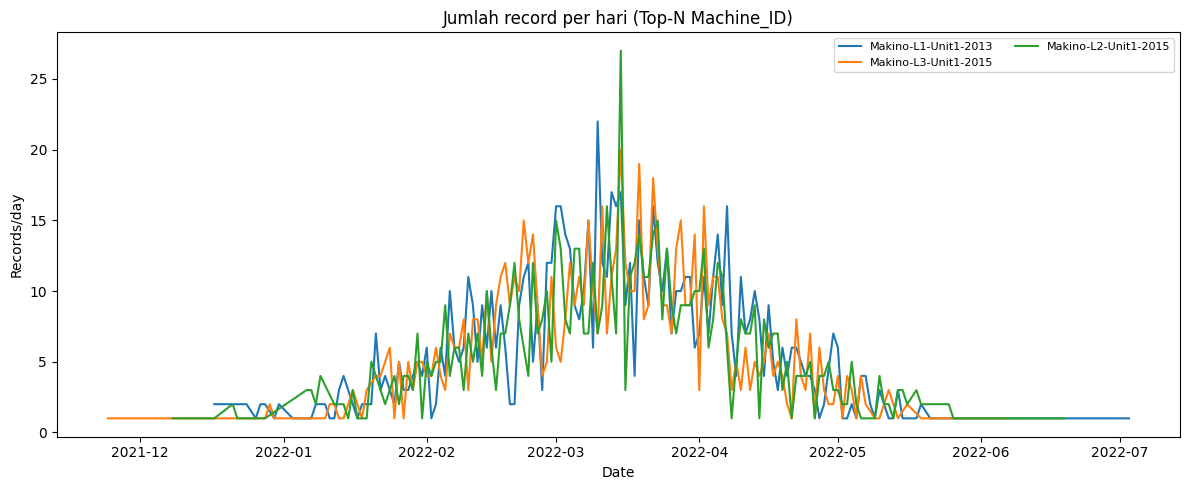

In [ ]:
import matplotlib.pyplot as plt

TOP_N = 10

top_machines = (
    df_t["Machine_ID"].value_counts()
        .head(TOP_N)
        .index
        .tolist()
)
print("Top machines:", top_machines)

daily = (
    df_t[df_t["Machine_ID"].isin(top_machines)]
      .assign(Date_day=lambda x: x["Date"].dt.floor("D"))
      .groupby(["Machine_ID", "Date_day"])
      .size()
      .rename("n_records")
      .reset_index()
)

plt.figure(figsize=(12, 5))
for mid in top_machines:
    d = daily[daily["Machine_ID"] == mid]
    plt.plot(d["Date_day"], d["n_records"], label=str(mid))
plt.title("Jumlah record per hari (Top-N Machine_ID)")
plt.xlabel("Date")
plt.ylabel("Records/day")
plt.legend(ncols=2, fontsize=8)
plt.tight_layout()
plt.show()

## --- **Heatmap record/day untuk Top-N mesin** ---

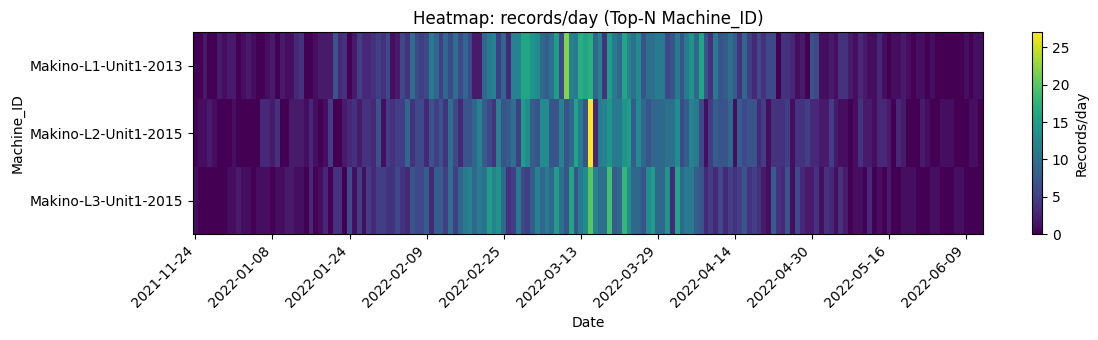

In [ ]:
pivot = daily.pivot_table(index="Machine_ID", columns="Date_day", values="n_records", fill_value=0)

plt.figure(figsize=(12, 0.5 * len(pivot) + 2))
plt.imshow(pivot.values, aspect="auto")
plt.yticks(range(len(pivot.index)), [str(i) for i in pivot.index])

cols = pivot.columns
step = max(1, len(cols)//10)
xt = list(range(0, len(cols), step))
plt.xticks(xt, [cols[i].strftime("%Y-%m-%d") for i in xt], rotation=45, ha="right")
plt.title("Heatmap: records/day (Top-N Machine_ID)")
plt.xlabel("Date")
plt.ylabel("Machine_ID")
plt.colorbar(label="Records/day")
plt.tight_layout()
plt.show()

## --- **Catatan keterbatasan (gap besar)** ---

In [ ]:
if len(extreme) > 0:
    impacted = (extreme.groupby("Machine_ID")["gap_days"].max().sort_values(ascending=False))
    print("Mesin dengan max gap terbesar (Top 10):")
    display(impacted.head(10))
    print("Saran: gap besar bisa berarti missing logs / mesin tidak tercatat;")
    print("pertimbangkan: (a) tandai feature gap_days/days_to_next, (b) filter periode, atau (c) catat sebagai limitation.")
else:
    print("Tidak terdeteksi gap ekstrem dengan threshold saat ini.")

Mesin dengan max gap terbesar (Top 10):


,gap_days
Machine_ID,
Makino-L3-Unit1-2015,33.0


Saran: gap besar bisa berarti missing logs / mesin tidak tercatat;
pertimbangkan: (a) tandai feature gap_days/days_to_next, (b) filter periode, atau (c) catat sebagai limitation.


## --- **Prep: parse Date + is_failure** ---**bold text**

In [ ]:
df = df_clean.copy()
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["Date"]).copy()

df["Downtime_clean"] = df["Downtime"].astype(str).str.strip()
df["is_failure"] = (df["Downtime_clean"] == "Machine_Failure").astype(int)

print("Date range:", df["Date"].min(), "->", df["Date"].max())
print("Class distribution (is_failure):")
display(df["is_failure"].value_counts())

Date range: 2021-11-24 00:00:00 -> 2022-07-03 00:00:00
Class distribution (is_failure):


,count
is_failure,
1,1265
0,1235


## --- **Failure rate per Machine_ID (Top 10 paling sering failure** ---

,total_records,failures,failure_rate
Machine_ID,,,
Makino-L1-Unit1-2013,874,454,0.519451
Makino-L3-Unit1-2015,818,415,0.507335
Makino-L2-Unit1-2015,808,396,0.490099


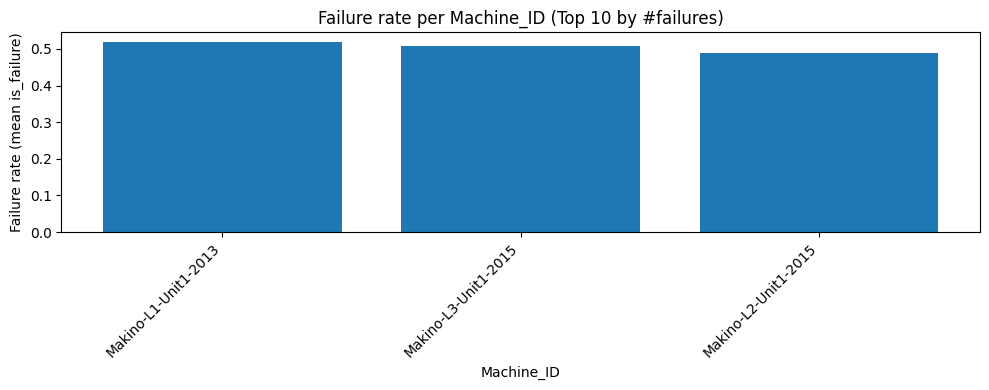

In [ ]:
m = (df.groupby("Machine_ID")["is_failure"]
       .agg(total_records="count", failures="sum", failure_rate="mean")
       .sort_values("failures", ascending=False)
       .head(10))

display(m)

plt.figure(figsize=(10, 4))
plt.bar(m.index.astype(str), m["failure_rate"])
plt.title("Failure rate per Machine_ID (Top 10 by #failures)")
plt.xlabel("Machine_ID")
plt.ylabel("Failure rate (mean is_failure)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## --- **Failure rate per Assembly_Line_No** ---

,total_records,failures,failure_rate
Assembly_Line_No,,,
Shopfloor-L1,874,454,0.519451
Shopfloor-L2,808,396,0.490099
Shopfloor-L3,818,415,0.507335


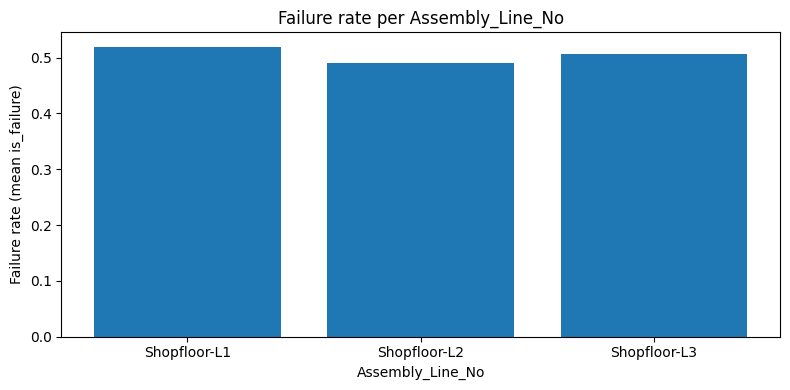

In [ ]:
a = (df.groupby("Assembly_Line_No")["is_failure"]
       .agg(total_records="count", failures="sum", failure_rate="mean")
       .sort_index())

display(a)

plt.figure(figsize=(8, 4))
plt.bar(a.index.astype(str), a["failure_rate"])
plt.title("Failure rate per Assembly_Line_No")
plt.xlabel("Assembly_Line_No")
plt.ylabel("Failure rate (mean is_failure)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## --- **Tren global: jumlah failure per minggu & per bulan** ---

Weekly failures head:


/tmp/ipython-input-1852370411.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fail_month = ts["is_failure"].resample("M").sum()


,is_failure
Date,
2021-11-28,1
2021-12-05,0
2021-12-12,0
2021-12-19,2
2021-12-26,2


Monthly failures head:


,is_failure
Date,
2021-11-30,1
2021-12-31,13
2022-01-31,87
2022-02-28,296
2022-03-31,533


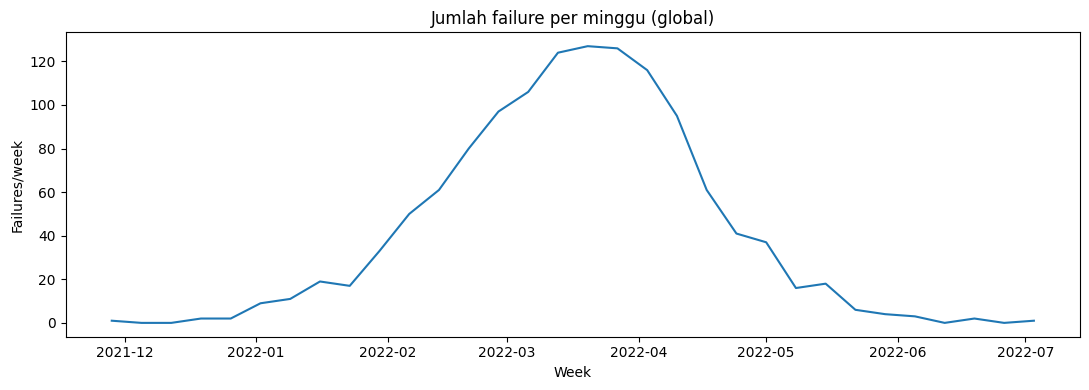

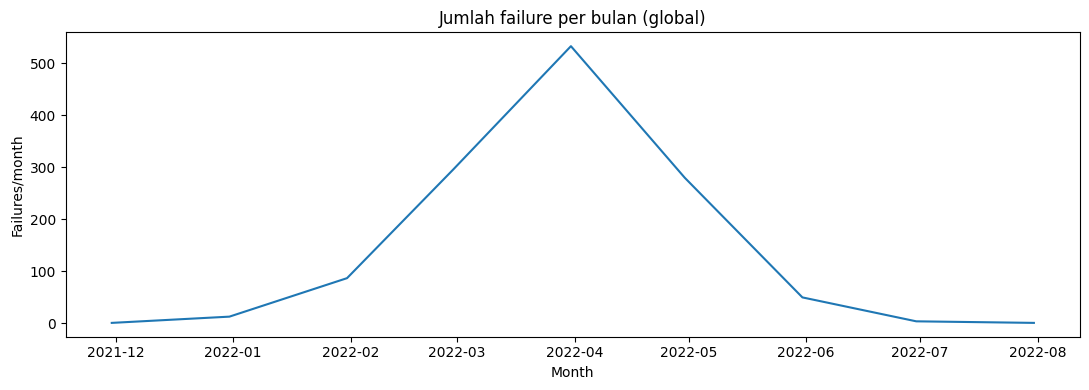

In [ ]:
ts = df.set_index("Date").sort_index()

fail_week = ts["is_failure"].resample("W").sum()
fail_month = ts["is_failure"].resample("M").sum()

print("Weekly failures head:")
display(fail_week.head())
print("Monthly failures head:")
display(fail_month.head())

plt.figure(figsize=(11, 4))
plt.plot(fail_week.index, fail_week.values)
plt.title("Jumlah failure per minggu (global)")
plt.xlabel("Week")
plt.ylabel("Failures/week")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
plt.plot(fail_month.index, fail_month.values)
plt.title("Jumlah failure per bulan (global)")
plt.xlabel("Month")
plt.ylabel("Failures/month")
plt.tight_layout()
plt.show()

## --- **Sensor distribution: histogram + boxplot (failure vs non-failure** ---

Sensor cols: ['Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)']


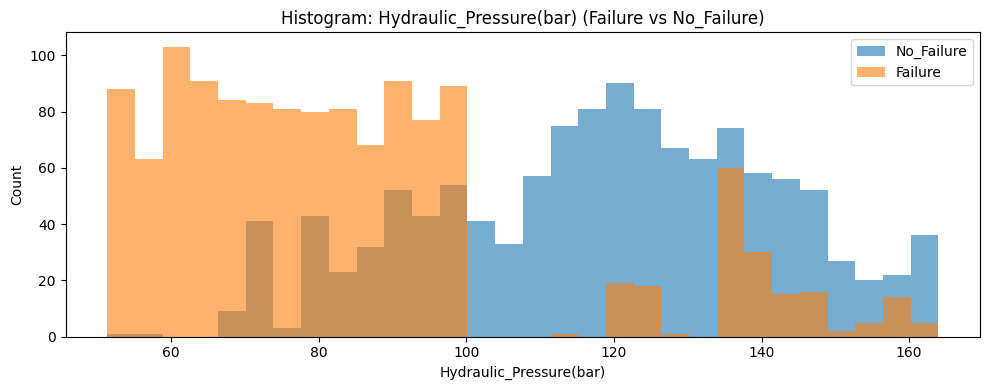

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


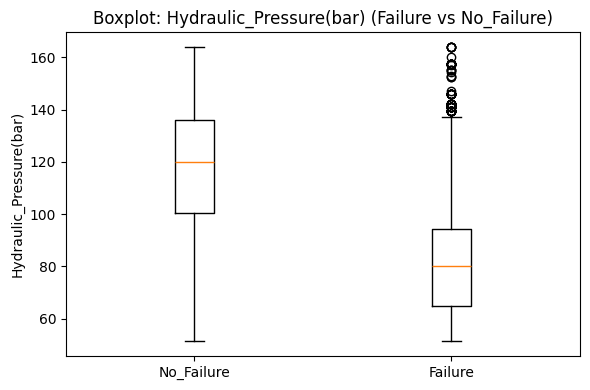

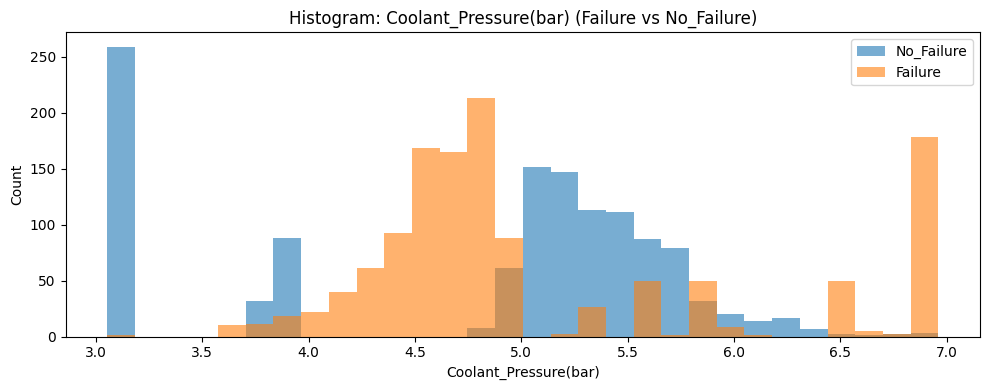

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


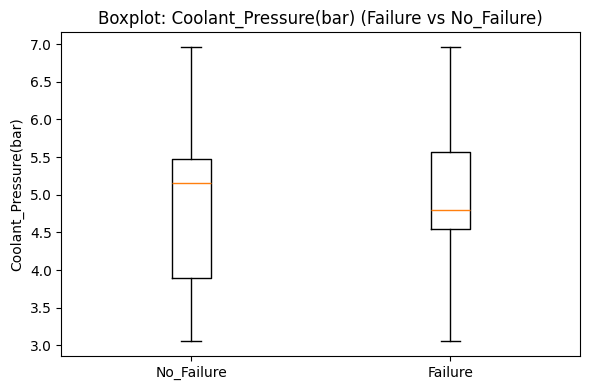

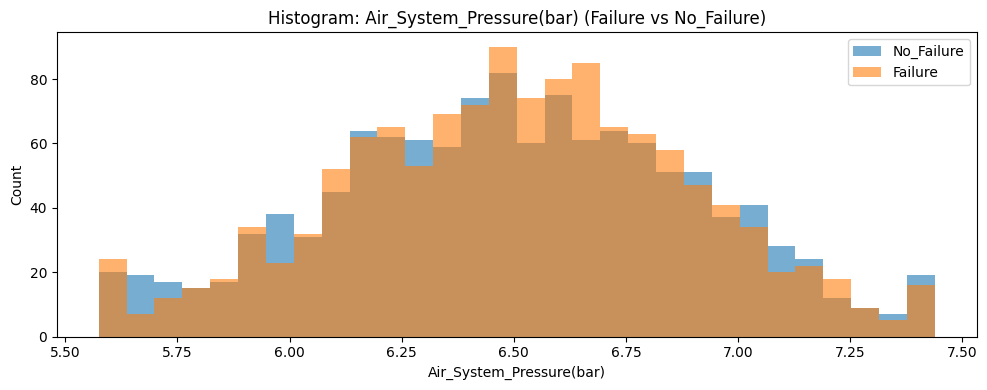

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


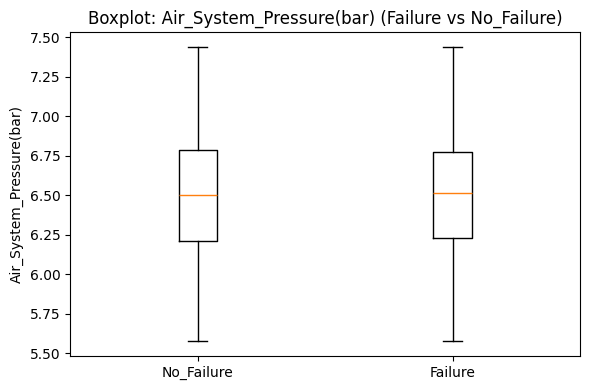

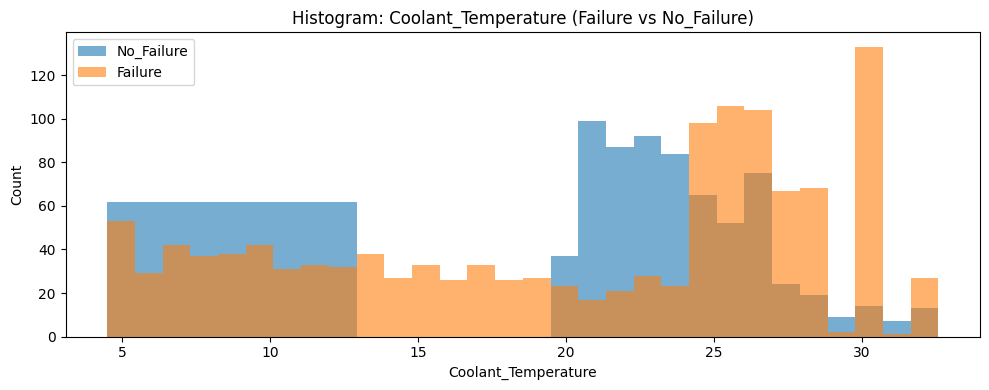

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


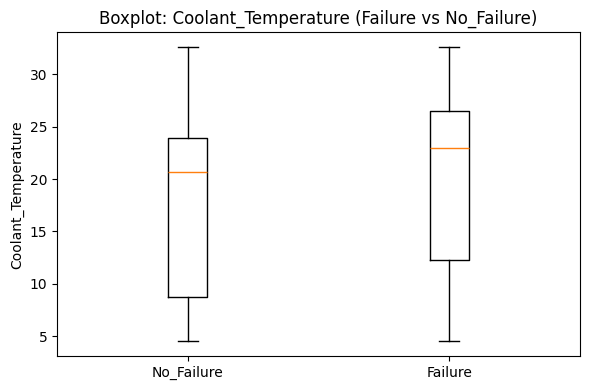

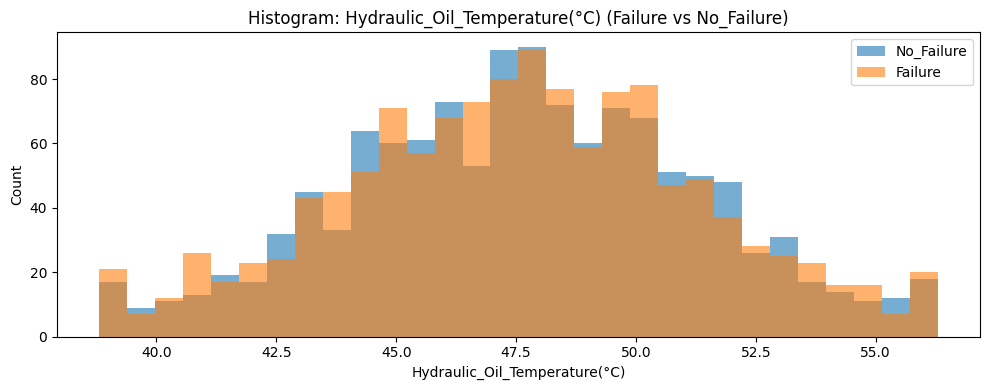

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


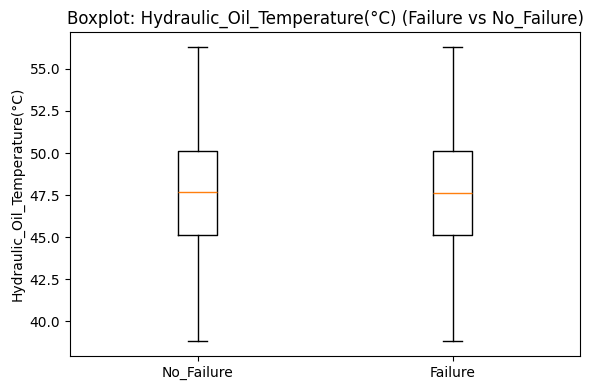

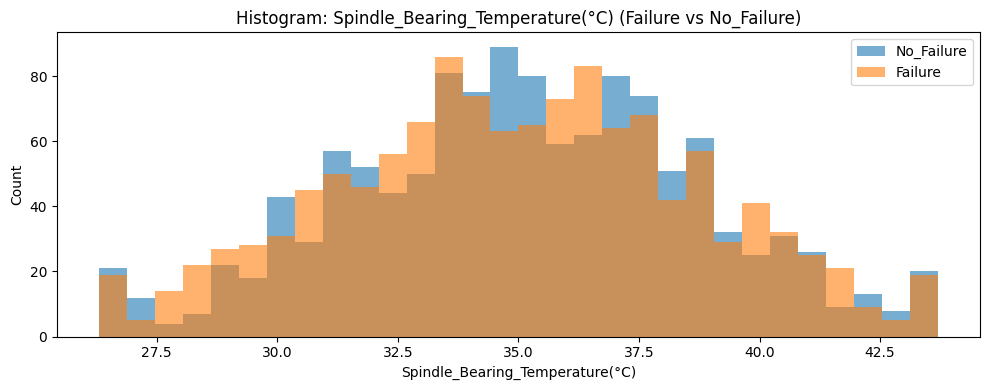

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


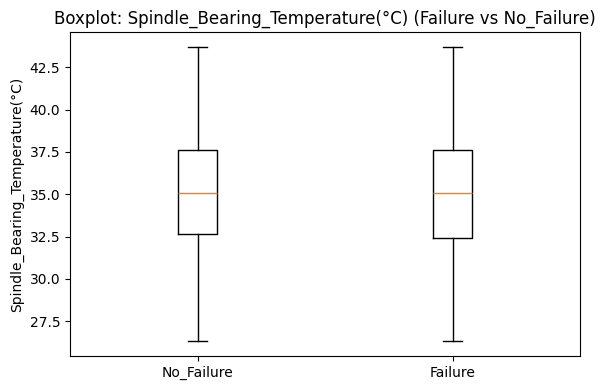

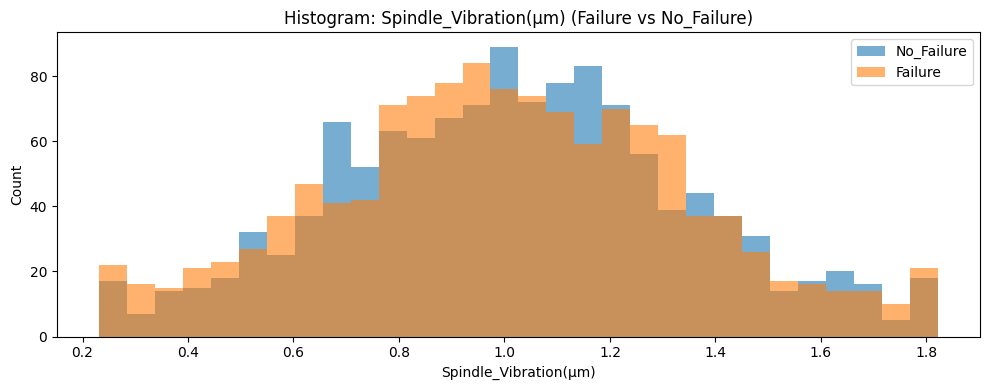

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


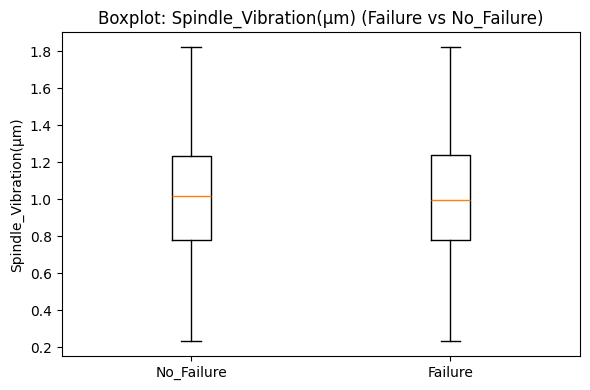

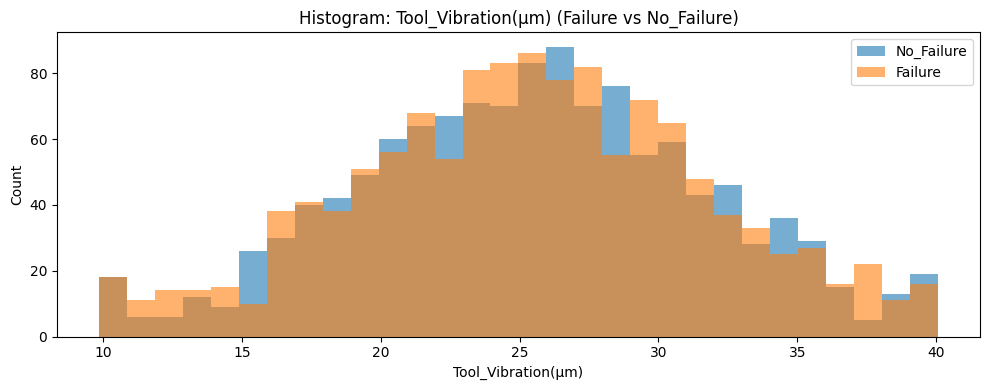

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


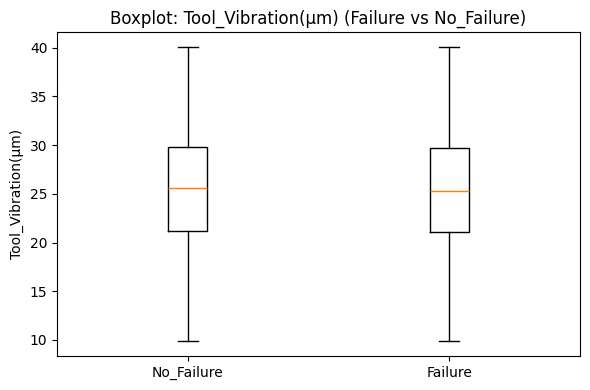

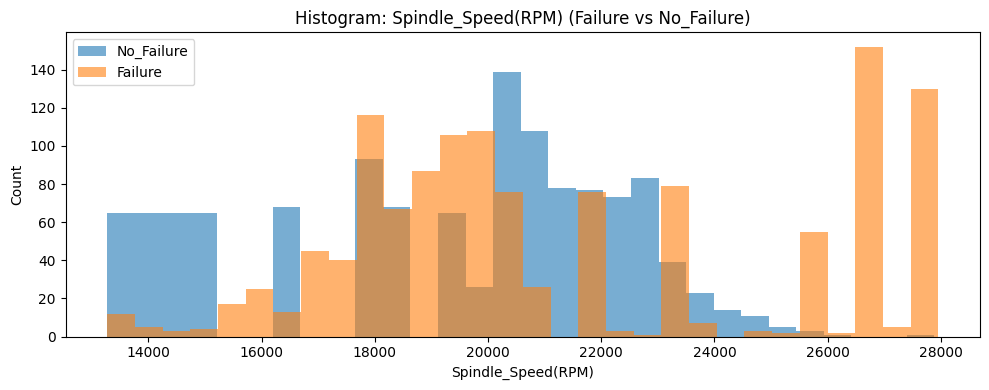

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


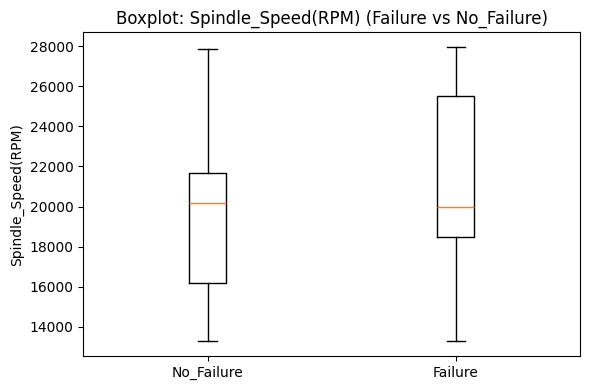

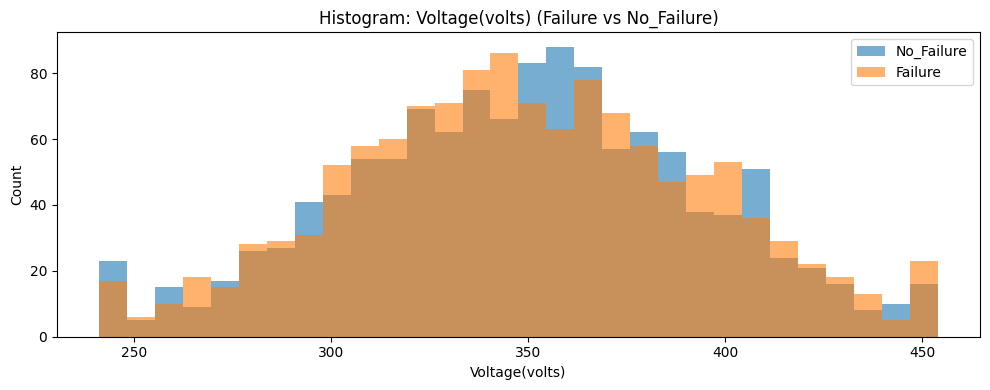

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


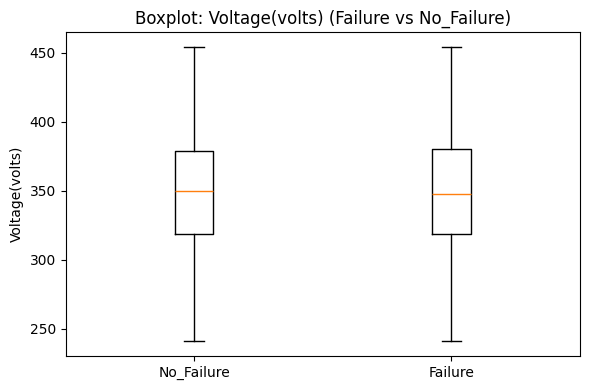

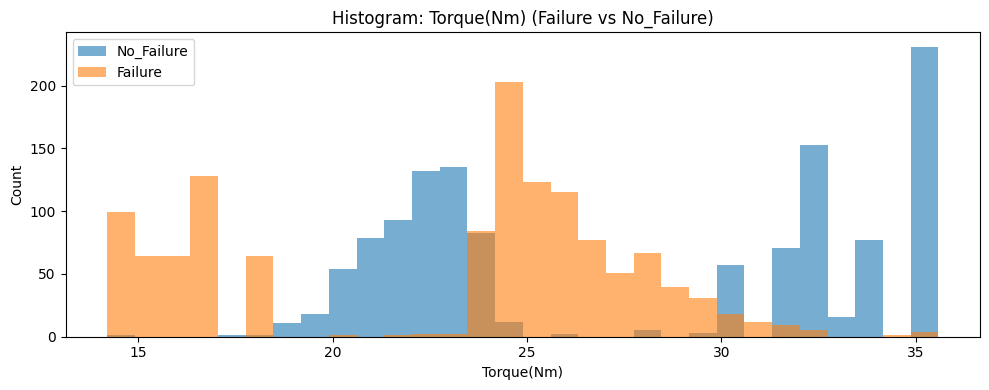

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


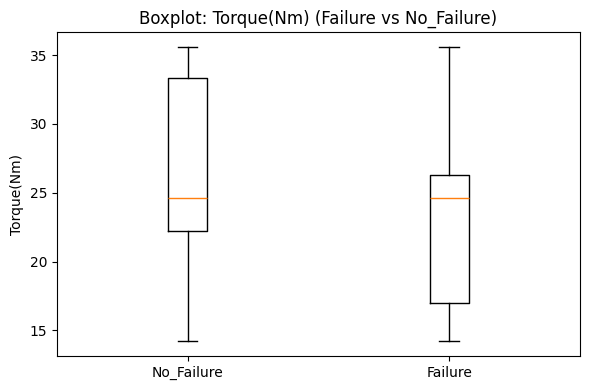

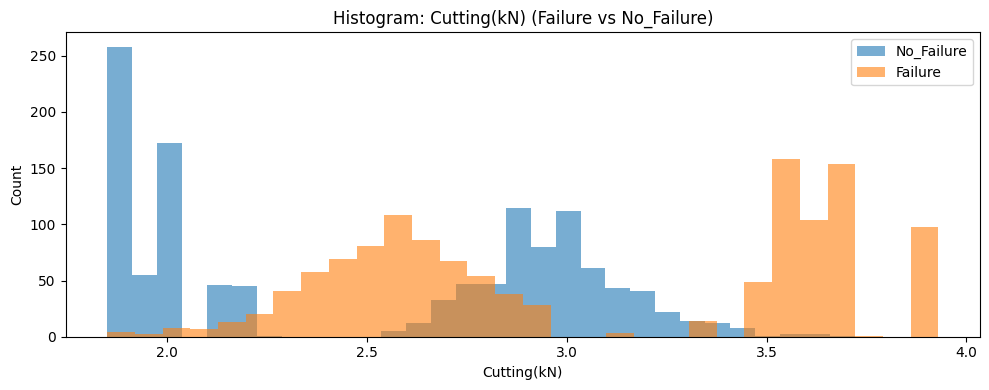

/tmp/ipython-input-2433590598.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)


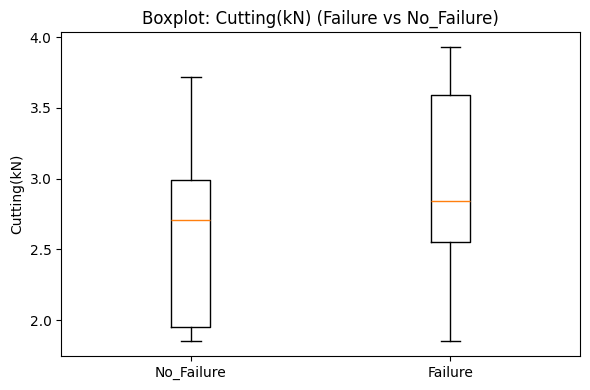

In [ ]:
import matplotlib.pyplot as plt

exclude = {"is_failure"}
num_cols = df.select_dtypes(include=["number"]).columns.tolist()
sensor_cols = [c for c in num_cols if c not in exclude]

exclude_more = {"year","month","day","dayofweek","days_to_next","gap_days"}
sensor_cols = [c for c in sensor_cols if c not in exclude_more]

print("Sensor cols:", sensor_cols)

MAX_SENSORS = 12
sensor_cols = sensor_cols[:MAX_SENSORS]

df0 = df[df["is_failure"] == 0]
df1 = df[df["is_failure"] == 1]

def plot_sensor_hist_box(col, bins=30):

    plt.figure(figsize=(10, 4))
    plt.hist(df0[col].dropna().values, bins=bins, alpha=0.6, label="No_Failure")
    plt.hist(df1[col].dropna().values, bins=bins, alpha=0.6, label="Failure")
    plt.title(f"Histogram: {col} (Failure vs No_Failure)")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    data = [df0[col].dropna().values, df1[col].dropna().values]
    plt.boxplot(data, labels=["No_Failure", "Failure"], showfliers=True)
    plt.title(f"Boxplot: {col} (Failure vs No_Failure)")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


for c in sensor_cols:
    plot_sensor_hist_box(c, bins=30)

## --- **Prep: is_failure & kolom sensor** ---

In [ ]:
df = df_clean.copy()
df["Downtime_clean"] = df["Downtime"].astype(str).str.strip()
df["is_failure"] = (df["Downtime_clean"] == "Machine_Failure").astype(int)

print("Class distribution:")
display(df["is_failure"].value_counts(dropna=False))

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
exclude_numeric = {"is_failure", "year", "month", "day", "dayofweek", "gap_days", "days_to_next"}
sensor_cols = [c for c in num_cols if c not in exclude_numeric]

print("Sensor cols terdeteksi:", sensor_cols)

Class distribution:


,count
is_failure,
1,1265
0,1235


Sensor cols terdeteksi: ['Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)']


## --- **Summary stats per sensor (failure vs non-failure)** ---

In [ ]:
df0 = df[df["is_failure"] == 0]
df1 = df[df["is_failure"] == 1]

def pooled_std(s0, s1):
    n0, n1 = s0.count(), s1.count()
    if n0 < 2 or n1 < 2:
        return np.nan
    v0 = s0.var(ddof=1)
    v1 = s1.var(ddof=1)
    return np.sqrt(((n0 - 1)*v0 + (n1 - 1)*v1) / (n0 + n1 - 2))

rows = []
N = len(df)

for c in sensor_cols:
    s_all = df[c]
    s0 = df0[c]
    s1 = df1[c]

    miss_all = s_all.isna().mean() * 100
    miss0 = s0.isna().mean() * 100
    miss1 = s1.isna().mean() * 100

    n0 = s0.dropna().shape[0]
    n1 = s1.dropna().shape[0]

    mean0, mean1 = s0.mean(), s1.mean()
    std0, std1 = s0.std(ddof=1), s1.std(ddof=1)

    med0, med1 = s0.median(), s1.median()
    q10_0, q90_0 = s0.quantile(0.10), s0.quantile(0.90)
    q10_1, q90_1 = s1.quantile(0.10), s1.quantile(0.90)

    q25_0, q75_0 = s0.quantile(0.25), s0.quantile(0.75)
    q25_1, q75_1 = s1.quantile(0.25), s1.quantile(0.75)
    iqr0, iqr1 = (q75_0 - q25_0), (q75_1 - q25_1)

    ps = pooled_std(s0.dropna(), s1.dropna())
    smd = (mean1 - mean0) / ps if (ps is not None and pd.notna(ps) and ps != 0) else np.nan

    rows.append({
        "sensor": c,
        "n_no_fail": n0,
        "n_fail": n1,
        "missing_%_all": round(miss_all, 2),
        "missing_%_no_fail": round(miss0, 2),
        "missing_%_fail": round(miss1, 2),
        "mean_no_fail": mean0,
        "mean_fail": mean1,
        "std_no_fail": std0,
        "std_fail": std1,
        "median_no_fail": med0,
        "median_fail": med1,
        "IQR_no_fail": iqr0,
        "IQR_fail": iqr1,
        "p10_no_fail": q10_0,
        "p90_no_fail": q90_0,
        "p10_fail": q10_1,
        "p90_fail": q90_1,
        "delta_median": (med1 - med0),
        "SMD_(mean_diff/pooled_std)": smd,
        "abs_SMD": np.abs(smd) if pd.notna(smd) else np.nan
    })

summary = pd.DataFrame(rows)

summary_sorted = summary.sort_values("abs_SMD", ascending=False)

display(summary_sorted.head(12))

,sensor,n_no_fail,n_fail,missing_%_all,missing_%_no_fail,missing_%_fail,mean_no_fail,mean_fail,std_no_fail,std_fail,...,median_fail,IQR_no_fail,IQR_fail,p10_no_fail,p90_no_fail,p10_fail,p90_fail,delta_median,SMD_(mean_diff/pooled_std),abs_SMD
0,Hydraulic_Pressure(bar),1235,1265,0.0,0.0,0.0,118.416607,84.739689,23.162417,26.168318,...,80.130000,35.553176,29.480000,85.592798,147.726918,57.218000,134.540000,-39.884911,-1.361832,1.361832
11,Cutting(kN),1235,1265,0.0,0.0,0.0,2.502470,3.056016,0.526233,0.572595,...,2.840000,1.040000,1.040000,1.870000,3.120000,2.374000,3.690000,0.130000,1.006117,1.006117
10,Torque(Nm),1235,1265,0.0,0.0,0.0,27.740629,22.786236,5.873476,5.154175,...,24.647736,11.102818,9.350634,20.956333,35.580334,15.119739,28.390086,0.000000,-0.897335,0.897335
8,Spindle_Speed(RPM),1235,1265,0.0,0.0,0.0,19204.182186,21393.267984,3210.437632,3850.881260,...,19964.000000,5469.000000,7067.000000,14152.000000,22860.600000,17224.000000,27613.000000,-221.000000,0.616821,0.616821
1,Coolant_Pressure(bar),1235,1265,0.0,0.0,0.0,4.767963,5.117057,1.005952,0.911851,...,4.791397,1.583503,1.021824,3.106960,5.747930,4.302613,6.863944,-0.362084,0.363833,0.363833
3,Coolant_Temperature,1235,1265,0.0,0.0,0.0,17.061053,19.966719,8.119836,8.337351,...,23.000000,15.200000,14.200000,6.140000,26.400000,7.440000,29.800000,2.300000,0.353031,0.353031
5,Spindle_Bearing_Temperature(°C),1235,1265,0.0,0.0,0.0,35.139523,34.994003,3.636146,3.745628,...,35.100000,4.950000,5.200000,30.300000,39.900000,30.000000,40.060000,0.000000,-0.039415,0.039415
6,Spindle_Vibration(µm),1235,1265,0.0,0.0,0.0,1.016729,1.003576,0.330471,0.342753,...,0.996000,0.451000,0.462000,0.594000,1.449600,0.552000,1.435600,-0.022000,-0.039060,0.039060
4,Hydraulic_Oil_Temperature(°C),1235,1265,0.0,0.0,0.0,47.656680,47.573123,3.655556,3.714493,...,47.600000,5.000000,5.000000,42.900000,52.400000,42.740000,52.360000,-0.100000,-0.022672,0.022672
2,Air_System_Pressure(bar),1235,1265,0.0,0.0,0.0,6.495429,6.503211,0.407283,0.387778,...,6.512516,0.575650,0.546620,5.950338,7.026409,5.999683,7.000187,0.011852,0.019577,0.019577


## --- **Ranking sensor paling beda (Top)** ---

In [ ]:
top_k = 10
top = summary_sorted.head(top_k)[
    ["sensor", "n_no_fail", "n_fail",
     "mean_no_fail", "mean_fail", "median_no_fail", "median_fail",
     "delta_median", "SMD_(mean_diff/pooled_std)", "missing_%_all"]
].copy()

for col in ["mean_no_fail","mean_fail","median_no_fail","median_fail","delta_median","SMD_(mean_diff/pooled_std)"]:
    top[col] = top[col].astype(float).round(4)

display(top)

,sensor,n_no_fail,n_fail,mean_no_fail,mean_fail,median_no_fail,median_fail,delta_median,SMD_(mean_diff/pooled_std),missing_%_all
0,Hydraulic_Pressure(bar),1235,1265,118.4166,84.7397,120.0149,80.1300,-39.8849,-1.3618,0.0
11,Cutting(kN),1235,1265,2.5025,3.0560,2.7100,2.8400,0.1300,1.0061,0.0
10,Torque(Nm),1235,1265,27.7406,22.7862,24.6477,24.6477,0.0000,-0.8973,0.0
8,Spindle_Speed(RPM),1235,1265,19204.1822,21393.2680,20185.0000,19964.0000,-221.0000,0.6168,0.0
1,Coolant_Pressure(bar),1235,1265,4.7680,5.1171,5.1535,4.7914,-0.3621,0.3638,0.0
3,Coolant_Temperature,1235,1265,17.0611,19.9667,20.7000,23.0000,2.3000,0.3530,0.0
5,Spindle_Bearing_Temperature(°C),1235,1265,35.1395,34.9940,35.1000,35.1000,0.0000,-0.0394,0.0
6,Spindle_Vibration(µm),1235,1265,1.0167,1.0036,1.0180,0.9960,-0.0220,-0.0391,0.0
4,Hydraulic_Oil_Temperature(°C),1235,1265,47.6567,47.5731,47.7000,47.6000,-0.1000,-0.0227,0.0
2,Air_System_Pressure(bar),1235,1265,6.4954,6.5032,6.5007,6.5125,0.0119,0.0196,0.0


## --- **Sensor dengan missing tinggi (cek data quality)** ---

## ---**Analisis**---

Data target dan fitur menunjukkan pola yang konsisten dan siap untuk modeling. (1) Distribusi kelas `is_failure` **seimbang** (1=1265 vs 0=1235) dan setelah pembentukan label next-step, `df_model` menjadi **(2497, 24)** dengan `X_next` **(2497, 20)** serta **tanpa NaN** di `X_next` maupun `y_next`; hanya **3 baris terakhir tiap `Machine_ID`** yang awalnya tidak punya `y_next` (wajar). (2) Secara temporal, `records/day` dan jumlah failure **memuncak di sekitar Feb–Mar 2022** lalu **menurun tajam** menuju akhir periode, sehingga evaluasi model sebaiknya **time-aware** (hindari random split yang bisa bias). (3) Konsistensi urutan waktu cukup baik karena `gap_days` mayoritas **0 hari** (median=0, p95=1), namun ada **1 gap ekstrem 33 hari** pada `Makino-L3-Unit1-2015` yang mengindikasikan potensi **missing logs/periode tidak tercatat** dan layak ditandai sebagai fitur/limitation. (4) Dari perbandingan distribusi sensor (histogram/boxplot), sinyal pemisah paling jelas muncul pada `Hydraulic_Pressure(bar)` (Failure cenderung **lebih rendah**) dan `Cutting(kN)` (Failure cenderung **lebih tinggi**), sementara beberapa sensor lain seperti `Air_System_Pressure(bar)`, `Hydraulic_Oil_Temperature(°C)`, `Voltage(volts)`, serta vibrasi/temperatur spindle terlihat **overlap besar** sehingga lemah secara univariat. (5) Ini diperkuat oleh statistik efek `abs_SMD`: `Hydraulic_Pressure(bar)` (**1.36**) dan `Cutting(kN)` (**1.01**) paling kuat, diikuti `Torque(Nm)` (**0.90**, beda terutama di sebaran meski median sama) dan `Spindle_Speed(RPM)` (**0.62**, indikasi mode operasi), sedangkan sensor lain umumnya **kecil** (<~0.36); sehingga baseline model sebaiknya memprioritaskan **`Hydraulic_Pressure(bar)`, `Cutting(kN)`, `Torque(Nm)`, `Spindle_Speed(RPM)`** plus interaksi/threshold untuk menangkap mode operasi.

In [ ]:
high_missing = summary.sort_values("missing_%_all", ascending=False).head(10)[
    ["sensor", "missing_%_all", "missing_%_no_fail", "missing_%_fail", "n_no_fail", "n_fail"]
]
display(high_missing)

,sensor,missing_%_all,missing_%_no_fail,missing_%_fail,n_no_fail,n_fail
0,Hydraulic_Pressure(bar),0.0,0.0,0.0,1235,1265
1,Coolant_Pressure(bar),0.0,0.0,0.0,1235,1265
2,Air_System_Pressure(bar),0.0,0.0,0.0,1235,1265
3,Coolant_Temperature,0.0,0.0,0.0,1235,1265
4,Hydraulic_Oil_Temperature(°C),0.0,0.0,0.0,1235,1265
5,Spindle_Bearing_Temperature(°C),0.0,0.0,0.0,1235,1265
6,Spindle_Vibration(µm),0.0,0.0,0.0,1235,1265
7,Tool_Vibration(µm),0.0,0.0,0.0,1235,1265
8,Spindle_Speed(RPM),0.0,0.0,0.0,1235,1265
9,Voltage(volts),0.0,0.0,0.0,1235,1265


# **EDA “lead-up to failure”**

## --- **KONFIGURASI** ---

In [ ]:
WINDOW_DAYS = 7
MAX_EVENTS_PLOT = 6
AGG_USE_ALL_EVENTS = True

## --- **Prep data (Date, is_failure, sensor columns)** ---

In [ ]:
df_lead = df_clean.copy()

df_lead["Date"] = pd.to_datetime(df_lead["Date"], dayfirst=True, errors="coerce")
df_lead = df_lead.dropna(subset=["Date"]).copy()

df_lead["Downtime_clean"] = df_lead["Downtime"].astype(str).str.strip()
df_lead["is_failure"] = (df_lead["Downtime_clean"] == "Machine_Failure").astype(int)

df_lead = df_lead.sort_values(["Machine_ID", "Date"]).reset_index(drop=True)

num_cols = df_lead.select_dtypes(include=["number"]).columns.tolist()
exclude_numeric = {
    "Machine_ID",
    "is_failure",
    "y_next",
    "days_to_failure",
    "year", "month", "day", "dayofweek",
    "gap_days", "days_to_next"
}
sensor_cols = [c for c in num_cols if c not in exclude_numeric]

print("Date range:", df_lead["Date"].min(), "->", df_lead["Date"].max())
print("Total records:", len(df_lead))
print("Total failure records:", int(df_lead["is_failure"].sum()))
print("Sensor cols:", sensor_cols)

Date range: 2021-11-24 00:00:00 -> 2022-07-03 00:00:00
Total records: 2500
Total failure records: 1265
Sensor cols: ['Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)']


## --- **Ambil daftar event failure (Machine_ID, Date)** ---

In [ ]:
fail_events = df_lead.loc[df_lead["is_failure"] == 1, ["Machine_ID", "Date"]].copy()
fail_events = fail_events.sort_values(["Machine_ID", "Date"]).reset_index(drop=True)

print("Jumlah event failure:", len(fail_events))
display(fail_events.head(10))

events_to_plot = fail_events.head(MAX_EVENTS_PLOT).copy()
print(f"Event yang diplot (max {MAX_EVENTS_PLOT}):")
display(events_to_plot)

Jumlah event failure: 1265


,Machine_ID,Date
0,Makino-L1-Unit1-2013,2021-12-17
1,Makino-L1-Unit1-2013,2021-12-17
2,Makino-L1-Unit1-2013,2021-12-27
3,Makino-L1-Unit1-2013,2021-12-27
4,Makino-L1-Unit1-2013,2021-12-28
5,Makino-L1-Unit1-2013,2021-12-30
6,Makino-L1-Unit1-2013,2021-12-31
7,Makino-L1-Unit1-2013,2021-12-31
8,Makino-L1-Unit1-2013,2022-01-03
9,Makino-L1-Unit1-2013,2022-01-07


Event yang diplot (max 6):


,Machine_ID,Date
0,Makino-L1-Unit1-2013,2021-12-17
1,Makino-L1-Unit1-2013,2021-12-17
2,Makino-L1-Unit1-2013,2021-12-27
3,Makino-L1-Unit1-2013,2021-12-27
4,Makino-L1-Unit1-2013,2021-12-28
5,Makino-L1-Unit1-2013,2021-12-30


## --- **Bangun dataset aligned (sensor beberapa hari sebelum failure)** ---

In [ ]:
aligned_rows = []
event_ids = []

for i, row in events_to_plot.reset_index(drop=True).iterrows():
    mid = row["Machine_ID"]
    fdate = row["Date"]

    sub = df_lead[df_lead["Machine_ID"] == mid].copy()
    sub["days_to_failure"] = (sub["Date"] - fdate).dt.days
    win = sub[(sub["days_to_failure"] >= -WINDOW_DAYS) & (sub["days_to_failure"] <= 0)].copy()

    if win.empty:
        continue

    win["event_id"] = f"{mid}__{fdate.date()}"
    aligned_rows.append(win)
    event_ids.append(win["event_id"].iloc[0])

aligned = pd.concat(aligned_rows, axis=0) if len(aligned_rows) else pd.DataFrame()

print("Aligned rows:", len(aligned))
print("Unique aligned events:", aligned["event_id"].nunique() if not aligned.empty else 0)
if not aligned.empty:
    display(aligned[["event_id", "Machine_ID", "Date", "days_to_failure", "is_failure"]].head(10))
else:
    print("Tidak ada data aligned yang terbentuk. Cek WINDOW_DAYS / format Date / failure events.")

Aligned rows: 29
Unique aligned events: 4


,event_id,Machine_ID,Date,days_to_failure,is_failure
0,Makino-L1-Unit1-2013__2021-12-17,Makino-L1-Unit1-2013,2021-12-17,0,1
1,Makino-L1-Unit1-2013__2021-12-17,Makino-L1-Unit1-2013,2021-12-17,0,1
0,Makino-L1-Unit1-2013__2021-12-17,Makino-L1-Unit1-2013,2021-12-17,0,1
1,Makino-L1-Unit1-2013__2021-12-17,Makino-L1-Unit1-2013,2021-12-17,0,1
2,Makino-L1-Unit1-2013__2021-12-27,Makino-L1-Unit1-2013,2021-12-24,-3,0
3,Makino-L1-Unit1-2013__2021-12-27,Makino-L1-Unit1-2013,2021-12-24,-3,0
4,Makino-L1-Unit1-2013__2021-12-27,Makino-L1-Unit1-2013,2021-12-26,-1,0
5,Makino-L1-Unit1-2013__2021-12-27,Makino-L1-Unit1-2013,2021-12-27,0,1
6,Makino-L1-Unit1-2013__2021-12-27,Makino-L1-Unit1-2013,2021-12-27,0,1
2,Makino-L1-Unit1-2013__2021-12-27,Makino-L1-Unit1-2013,2021-12-24,-3,0


## --- **Plot aligned: sensor beberapa hari sebelum failure (per event)** ---

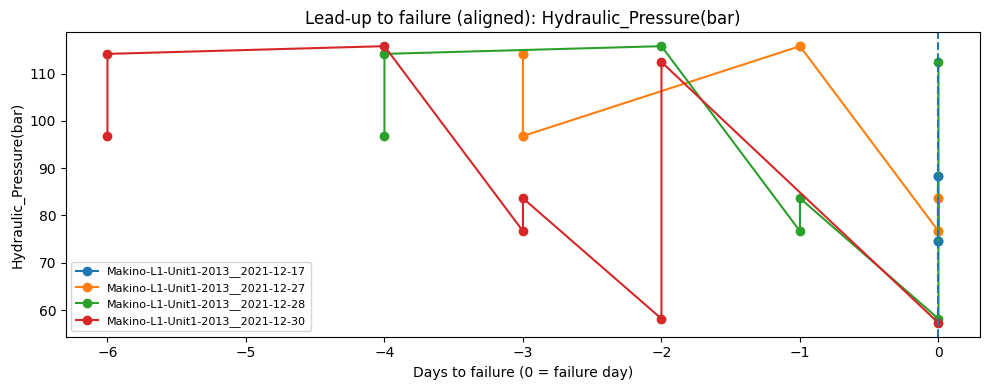

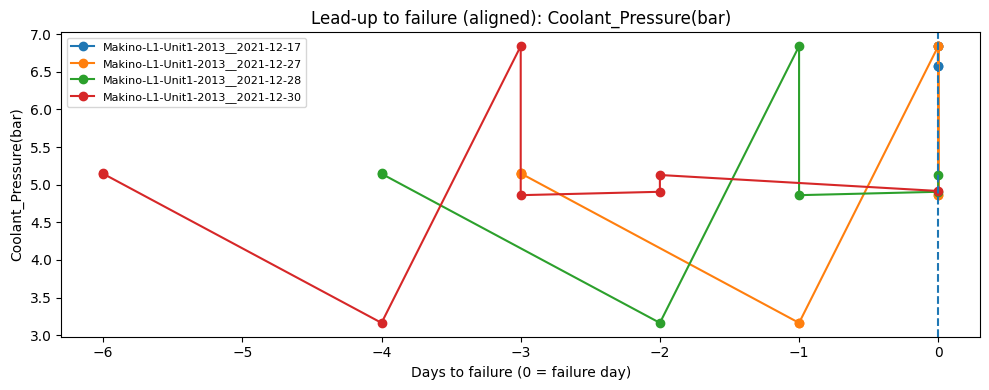

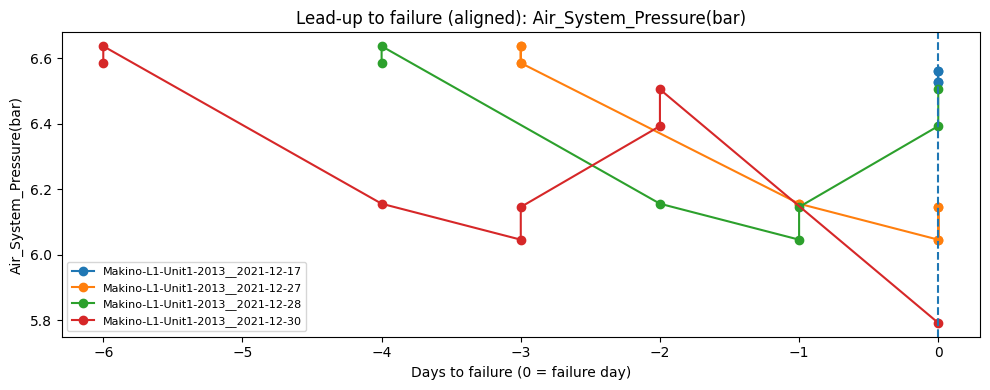

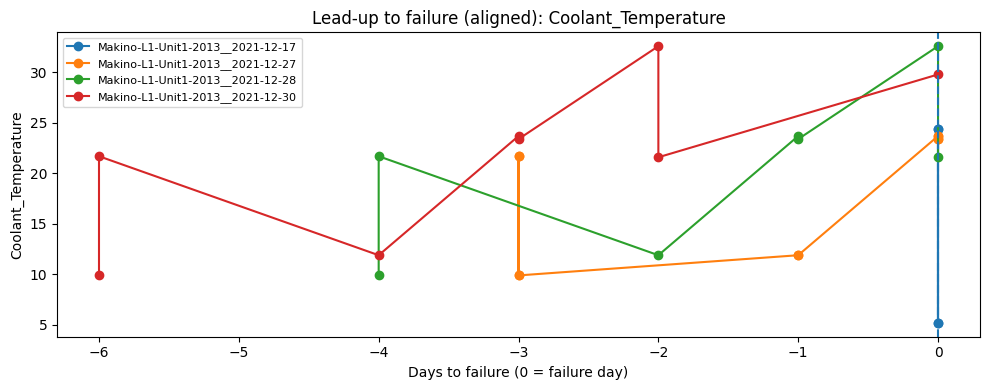

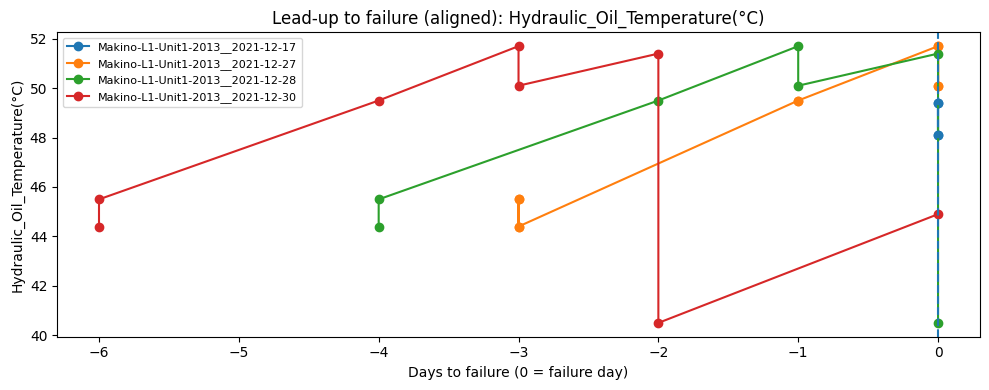

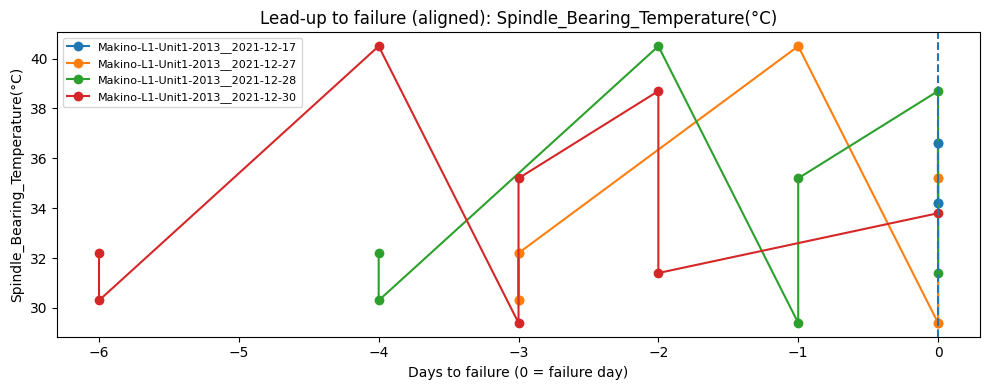

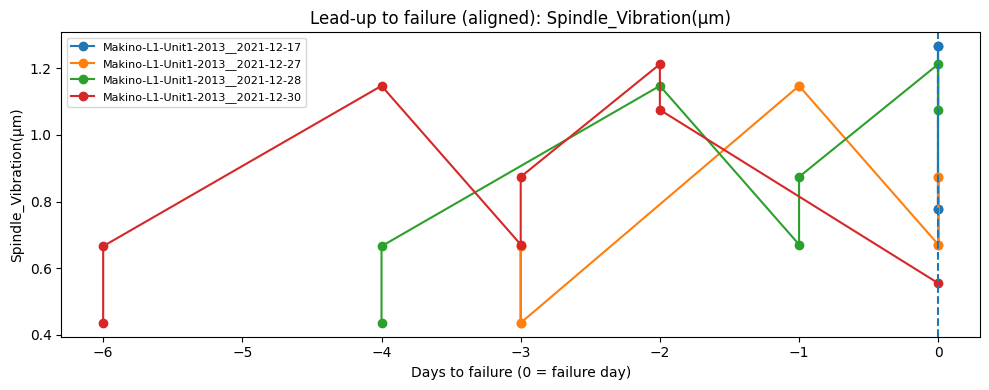

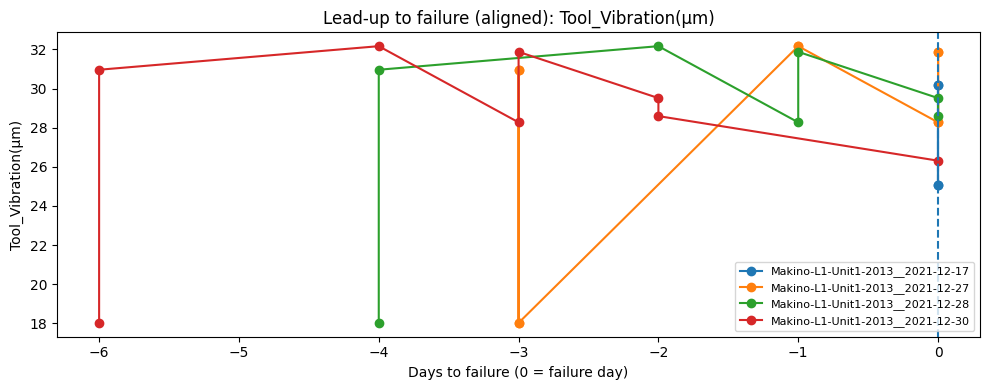

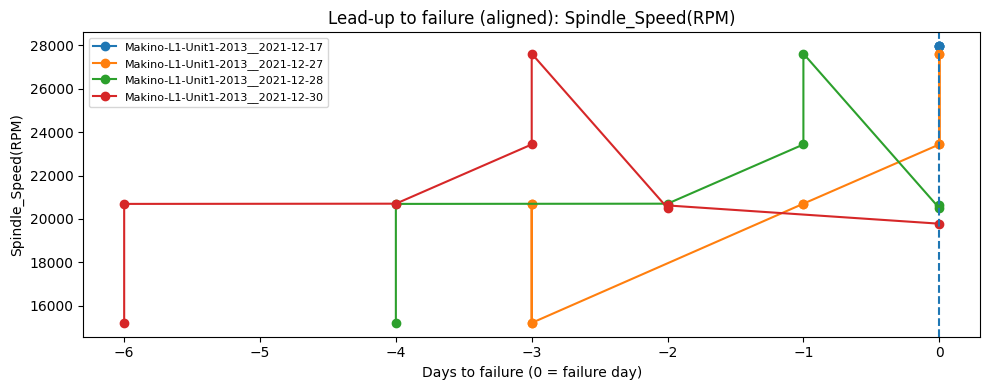

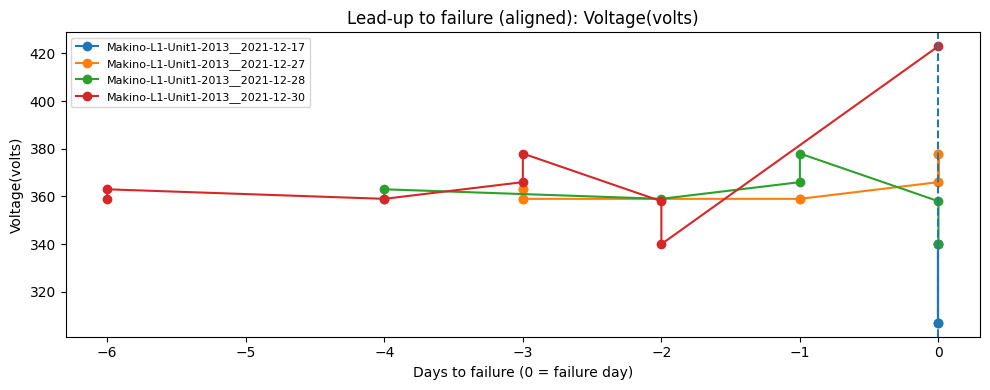

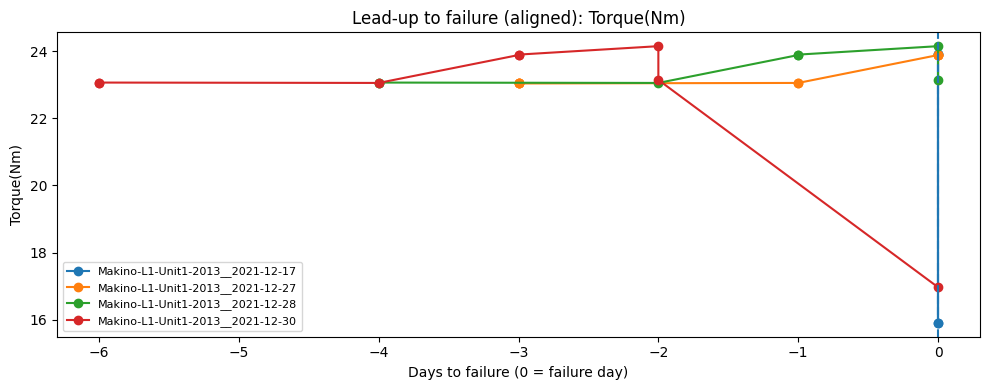

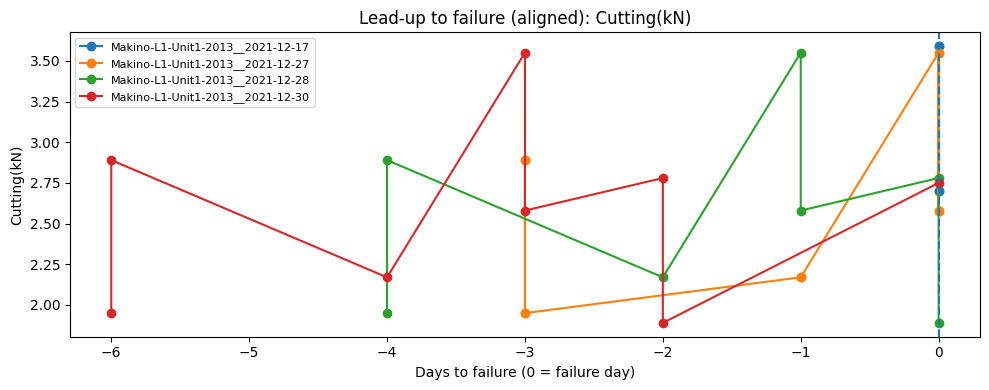

In [ ]:
if not aligned.empty:
    for col in sensor_cols:
        plt.figure(figsize=(10, 4))
        for eid, g in aligned.groupby("event_id"):
            g = g.sort_values("days_to_failure")
            g = g.dropna(subset=[col])
            plt.plot(g["days_to_failure"], g[col], marker="o", label=eid)
        plt.title(f"Lead-up to failure (aligned): {col}")
        plt.xlabel("Days to failure (0 = failure day)")
        plt.ylabel(col)
        plt.axvline(0, linestyle="--")
        plt.legend(fontsize=8, ncols=1)
        plt.tight_layout()
        plt.show()

## --- **Agregasi pola lead-up (median + IQR across events)** ---

Global aligned events: 354


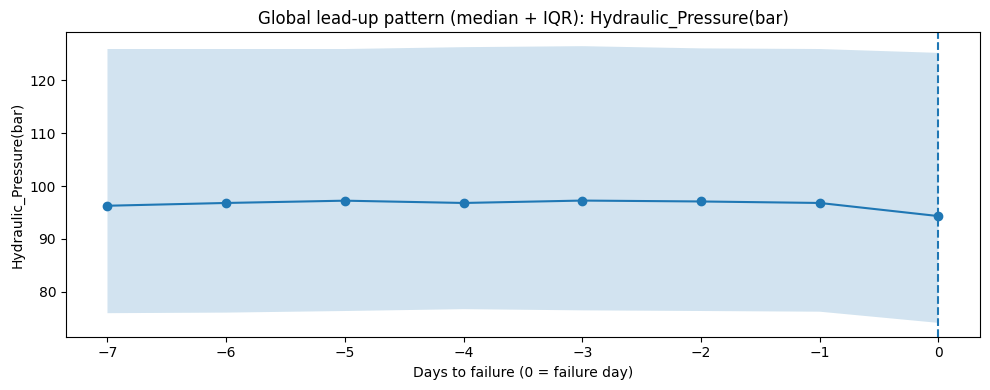

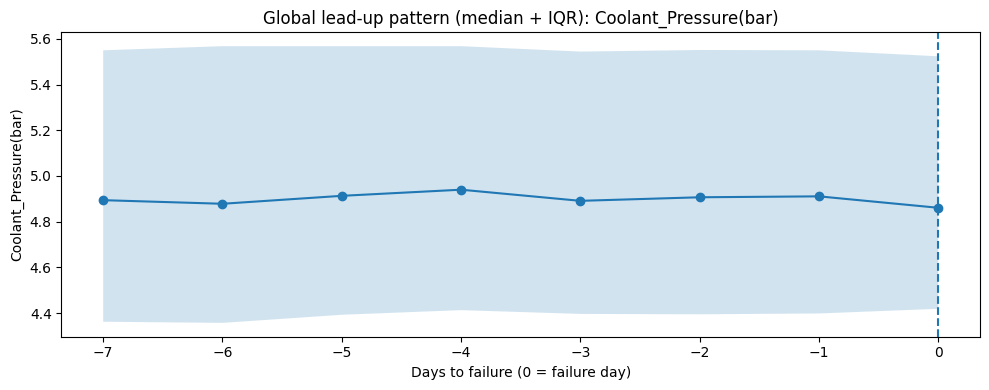

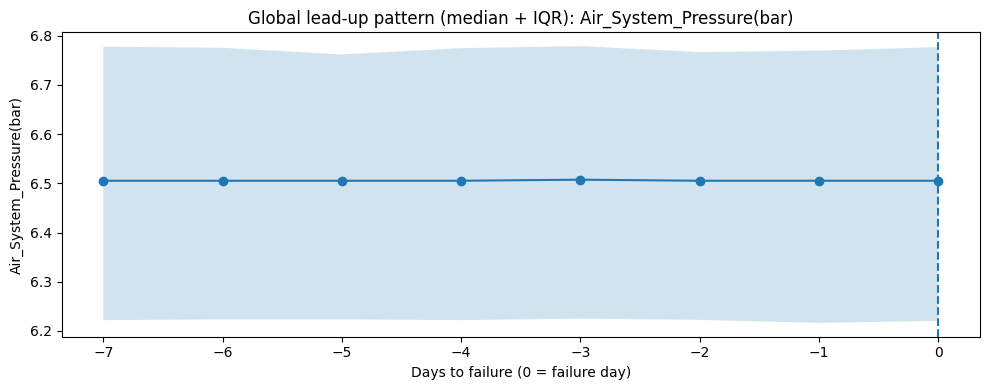

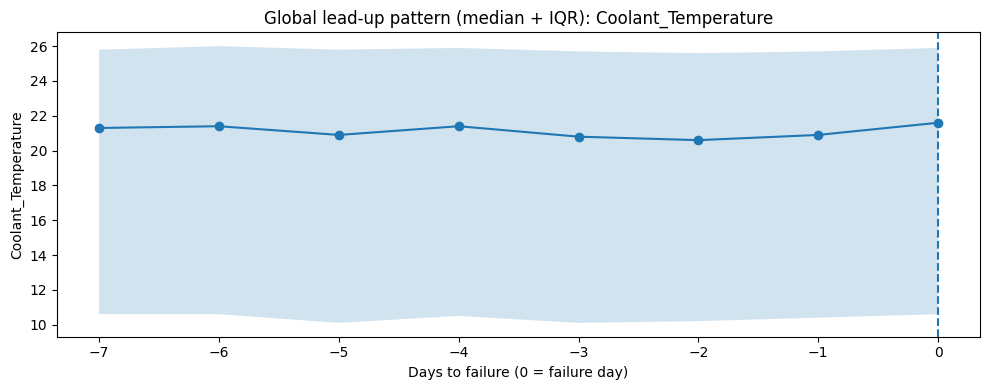

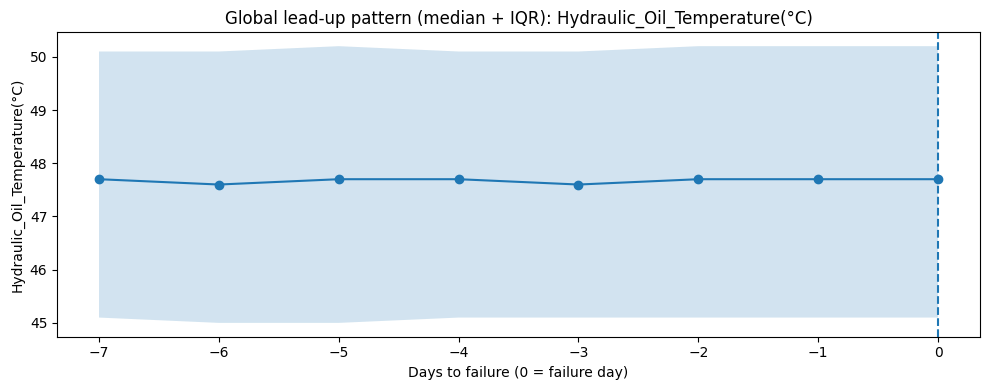

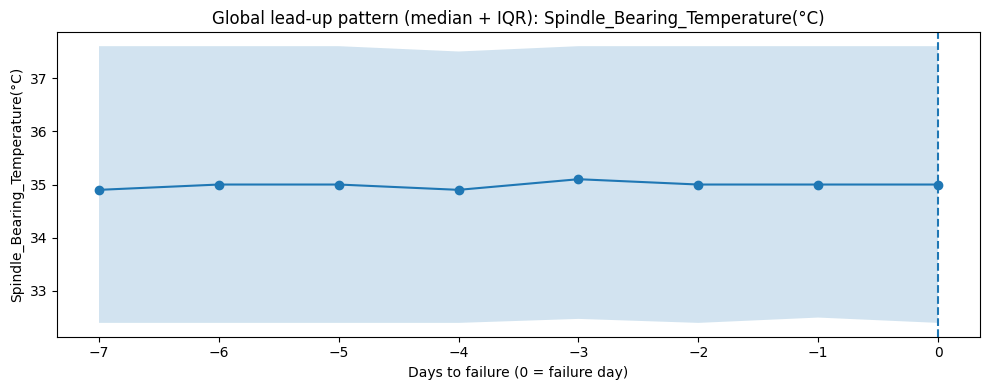

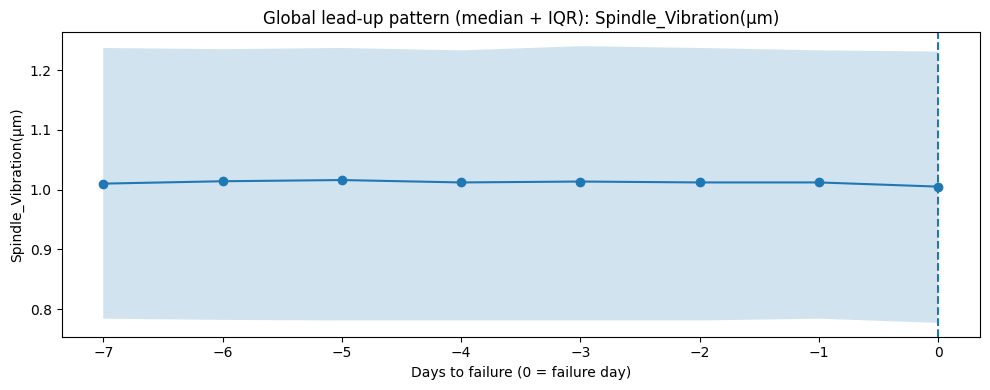

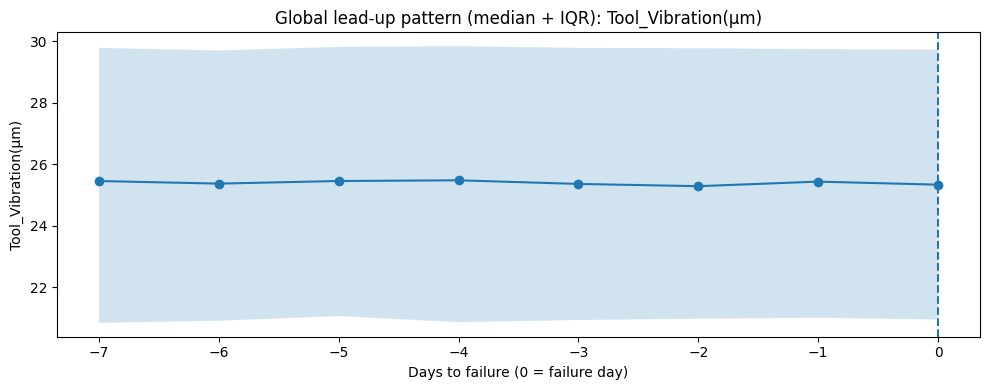

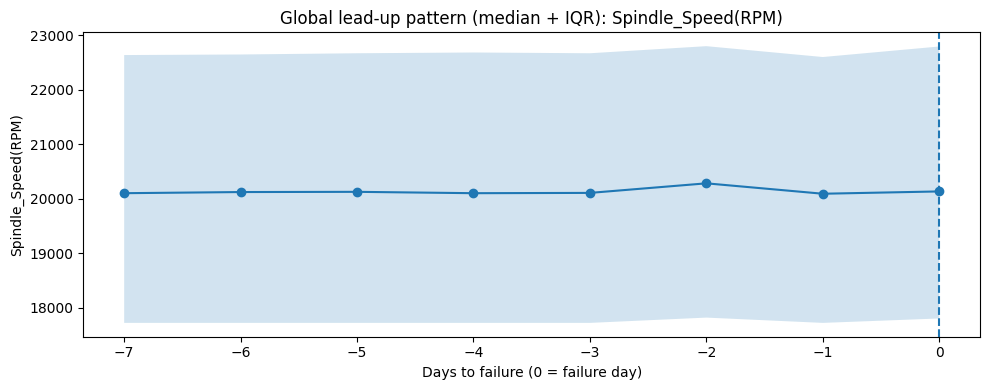

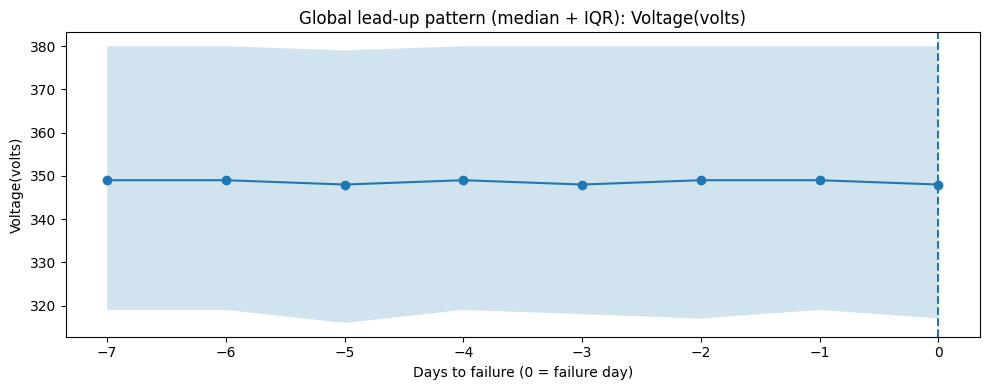

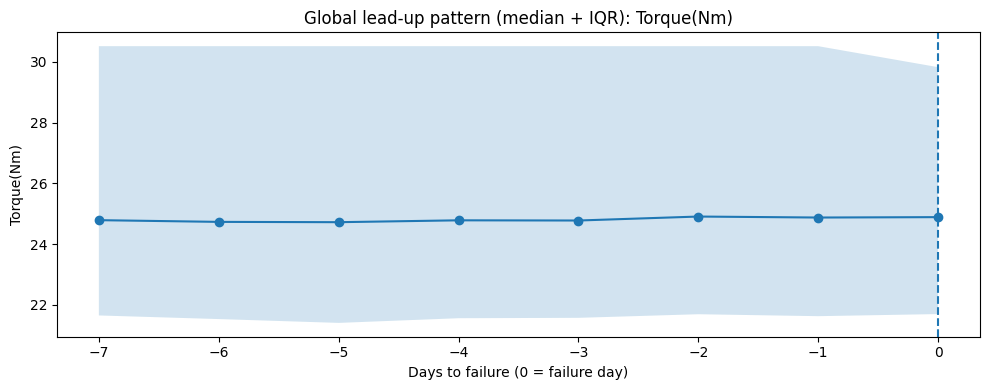

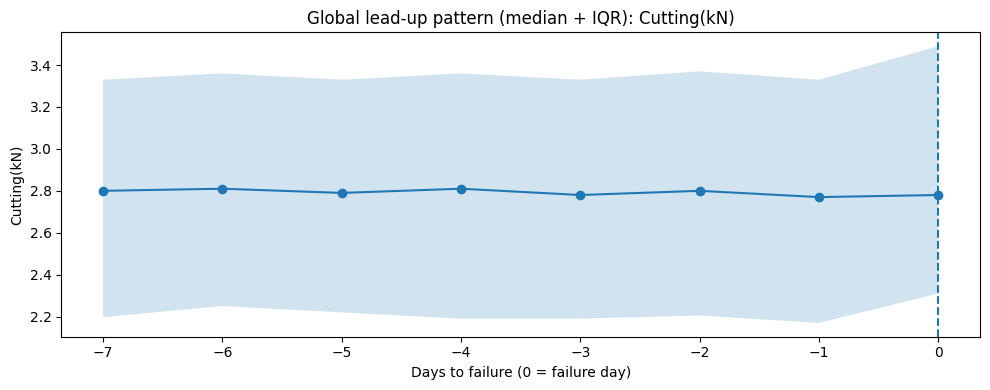

,Cutting(kN)
days_to_failure,
-7,10292
-6,10486
-5,10349
-4,10486
-3,10524
-2,10459
-1,10316
0,11836


In [ ]:
if AGG_USE_ALL_EVENTS:

    aligned_all = []
    for _, row in fail_events.iterrows():
        mid, fdate = row["Machine_ID"], row["Date"]
        sub = df_lead[df_lead["Machine_ID"] == mid].copy()
        sub["days_to_failure"] = (sub["Date"] - fdate).dt.days
        win = sub[(sub["days_to_failure"] >= -WINDOW_DAYS) & (sub["days_to_failure"] <= 0)].copy()
        if win.empty:
            continue
        win["event_id"] = f"{mid}__{fdate.date()}"
        aligned_all.append(win)

    aligned_global = pd.concat(aligned_all, axis=0) if len(aligned_all) else pd.DataFrame()
    print("Global aligned events:", aligned_global["event_id"].nunique() if not aligned_global.empty else 0)

    if not aligned_global.empty:
        for col in sensor_cols:

            grp = aligned_global.groupby("days_to_failure")[col]
            med = grp.median()
            q25 = grp.quantile(0.25)
            q75 = grp.quantile(0.75)

            xs = med.index.values

            plt.figure(figsize=(10, 4))
            plt.plot(xs, med.values, marker="o")
            plt.fill_between(xs, q25.values, q75.values, alpha=0.2)
            plt.title(f"Global lead-up pattern (median + IQR): {col}")
            plt.xlabel("Days to failure (0 = failure day)")
            plt.ylabel(col)
            plt.axvline(0, linestyle="--")
            plt.tight_layout()
            plt.show()
    else:
        print("Tidak bisa buat agregasi (aligned_global kosong).")

cnt = aligned_global.groupby("days_to_failure")[col].count()
display(cnt)

## --- **Ranking sensor yang paling berubah sebelum failure (heuristic)** ---

In [ ]:
if "aligned_global" not in globals():
    aligned_global = pd.DataFrame()

def score_sensor_shift(aligned_df, sensor_cols, window_days, last_k_days=2, min_pts=1):
    """
    Hitung perubahan sensor mendekati failure:
    shift = mean(recent[-last_k_days..-1]) - mean(baseline[-window_days..-(last_k_days+1)])
    """
    if aligned_df is None or aligned_df.empty:
        return pd.DataFrame(columns=["sensor", "n_events", "mean_shift", "mean_abs_shift", "median_abs_shift"])

    scores = []
    for col in sensor_cols:
        shifts = []
        for eid, g in aligned_df.groupby("event_id"):
            g = g.sort_values("days_to_failure")

            baseline = g[(g["days_to_failure"] >= -window_days) & (g["days_to_failure"] <= -(last_k_days+1))][col].dropna()
            recent   = g[(g["days_to_failure"] >= -last_k_days) & (g["days_to_failure"] <= -1)][col].dropna()

            if len(baseline) < min_pts or len(recent) < min_pts:
                continue

            shifts.append(recent.mean() - baseline.mean())

        if len(shifts) == 0:
            continue

        scores.append({
            "sensor": col,
            "n_events": len(shifts),
            "mean_shift": float(np.mean(shifts)),
            "mean_abs_shift": float(np.mean(np.abs(shifts))),
            "median_abs_shift": float(np.median(np.abs(shifts))),
        })

    return pd.DataFrame(scores).sort_values("mean_abs_shift", ascending=False)

aligned_for_score = aligned_global if (isinstance(aligned_global, pd.DataFrame) and not aligned_global.empty) else aligned
score_df = score_sensor_shift(aligned_for_score, sensor_cols, WINDOW_DAYS, last_k_days=2)

display(score_df.head(12))


print("\nCatatan interpretasi:")
print("- mean_shift > 0: rata-rata sensor naik mendekati failure; < 0: turun.")
print("- Kalau timeline tidak harian/ada gap besar, 'Days to failure' bisa bolong; catat sebagai limitation.")

,sensor,n_events,mean_shift,mean_abs_shift,median_abs_shift
8,Spindle_Speed(RPM),338,-52.780465,1372.260498,1115.310000
9,Voltage(volts),338,1.162738,15.326054,12.372170
0,Hydraulic_Pressure(bar),338,0.283320,10.712163,8.171070
3,Coolant_Temperature,338,-0.090582,3.469120,2.979361
10,Torque(Nm),338,-0.029051,2.363720,1.900524
7,Tool_Vibration(µm),338,0.033505,2.138583,1.612695
4,Hydraulic_Oil_Temperature(°C),338,0.108245,1.407426,1.065175
5,Spindle_Bearing_Temperature(°C),338,0.052260,1.333312,0.958333
1,Coolant_Pressure(bar),338,-0.001999,0.381915,0.282360
11,Cutting(kN),338,-0.011751,0.234565,0.187911



Catatan interpretasi:
- mean_shift > 0: rata-rata sensor naik mendekati failure; < 0: turun.
- Kalau timeline tidak harian/ada gap besar, 'Days to failure' bisa bolong; catat sebagai limitation.


## --- **Analisis** ---

Analisis lead-up 7 hari menunjukkan bahwa sinyal menjelang failure lebih kuat di level **event** daripada pola **global**. (1) Dengan `WINDOW_DAYS=7`, data disejajarkan ke `days_to_failure` (-7…0) dan karena ada **multi-record pada tanggal yang sama** serta hari yang **tidak selalu lengkap**, definisi event perlu konsisten (idealnya 1 event per `Machine_ID`+`Date`) dan interpretasi tren harian sebaiknya memakai **agregasi per hari**. (2) Ringkasan shift lintas event menempatkan `Spindle_Speed(RPM)` sebagai sensor dengan perubahan terbesar (abs shift paling tinggi), sementara `Voltage(volts)` dan `Hydraulic_Pressure(bar)` menunjukkan perubahan menengah, dan sensor lain relatif kecil. (3) Pada contoh event `Makino-L1-Unit1-2013`, terlihat pola lokal seperti `Hydraulic_Pressure(bar)` yang sering **turun tajam** mendekati hari 0 pada beberapa event, `Coolant_Temperature`/`Hydraulic_Oil_Temperature(°C)` yang cenderung **naik** (thermal build-up), serta `Torque(Nm)` yang umumnya stabil namun kadang **drop mendadak** tepat di hari 0; `Cutting(kN)` lebih sering **spike/bervariasi** (indikasi mode operasi). (4) Namun saat dilihat secara global (median+IQR) untuk `Spindle_Speed(RPM)`, `Voltage(volts)`, `Torque(Nm)`, dan `Cutting(kN)`, median cenderung **datar**—yang menandakan heterogenitas antar event/mode operasi “menutupi” tren rata-rata; karenanya fitur terbaik untuk modeling adalah fitur window seperti **delta (0 vs -1), max/min, slope, volatility, dan flag spike/drop**, plus interaksi dengan `Machine_ID`/mode operasi.

# **Feature engineering khusus early warning**

## --- **INPUT: pakai df_model (yang sudah punya y_next), atau df** ---

In [ ]:
if "df_model" in globals():
    data = df_model.copy()
elif "df_clean" in globals():
    data = df_clean.copy()
else:
    data = df.copy()

## --- **Prep: parse Date + urutkan per Machine_ID, Date** ---

In [ ]:
data["Date"] = pd.to_datetime(data["Date"], dayfirst=True, errors="coerce")
data = data.dropna(subset=["Date"]).sort_values(["Machine_ID", "Date"]).reset_index(drop=True)

print("Shape:", data.shape)
print("Date range:", data["Date"].min(), "->", data["Date"].max())
display(data[["Machine_ID", "Date"]].head(10))

if "is_failure" not in data.columns:
    data["Downtime_clean"] = data["Downtime"].astype(str).str.strip()
    data["is_failure"] = (data["Downtime_clean"] == "Machine_Failure").astype(int)

if "y_next" not in data.columns:
    data["y_next"] = data.groupby("Machine_ID")["is_failure"].shift(-1)
    data = data.dropna(subset=["y_next"]).copy()
    data["y_next"] = data["y_next"].astype(int)

Shape: (2497, 24)
Date range: 2021-11-24 00:00:00 -> 2022-06-19 00:00:00


,Machine_ID,Date
0,Makino-L1-Unit1-2013,2021-12-17
1,Makino-L1-Unit1-2013,2021-12-17
2,Makino-L1-Unit1-2013,2021-12-24
3,Makino-L1-Unit1-2013,2021-12-24
4,Makino-L1-Unit1-2013,2021-12-26
5,Makino-L1-Unit1-2013,2021-12-27
6,Makino-L1-Unit1-2013,2021-12-27
7,Makino-L1-Unit1-2013,2021-12-28
8,Makino-L1-Unit1-2013,2021-12-28
9,Makino-L1-Unit1-2013,2021-12-30


## --- **Deteksi sensor columns (numerik)** ---

In [ ]:
num_cols = df_lead.select_dtypes(include=["number"]).columns.tolist()
exclude_numeric = {
    "Machine_ID",
    "is_failure",
    "y_next",
    "days_to_failure",
    "year", "month", "day", "dayofweek",
    "gap_days", "days_to_next"
}
sensor_cols = [c for c in num_cols if c not in exclude_numeric]

print("Sensor cols:", sensor_cols)
print("Jumlah sensor:", len(sensor_cols))

Sensor cols: ['Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)']
Jumlah sensor: 12


## --- **Lag features (t-1, t-2) + Delta (t - t-1) per Machine_ID** ---

In [ ]:
g = data.groupby("Machine_ID", group_keys=False)

for c in sensor_cols:
    data[f"{c}_lag1"] = g[c].shift(1)
    data[f"{c}_lag2"] = g[c].shift(2)
    data[f"{c}_delta1"] = data[c] - data[f"{c}_lag1"]

show_cols = ["Machine_ID", "Date"] + sensor_cols[:2] + [f"{sensor_cols[0]}_lag1", f"{sensor_cols[0]}_lag2", f"{sensor_cols[0]}_delta1"]
display(data[show_cols].head(10))

,Machine_ID,Date,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Hydraulic_Pressure(bar)_lag1,Hydraulic_Pressure(bar)_lag2,Hydraulic_Pressure(bar)_delta1
0,Makino-L1-Unit1-2013,2021-12-17,74.540000,6.580195,NaN,NaN,NaN
1,Makino-L1-Unit1-2013,2021-12-17,88.280000,6.839413,74.540000,NaN,13.740000
2,Makino-L1-Unit1-2013,2021-12-24,96.786973,5.150505,88.280000,74.540000,8.506973
3,Makino-L1-Unit1-2013,2021-12-24,114.145368,5.145508,96.786973,88.280000,17.358395
4,Makino-L1-Unit1-2013,2021-12-26,115.776093,3.164805,114.145368,96.786973,1.630725
5,Makino-L1-Unit1-2013,2021-12-27,76.690000,6.839413,115.776093,114.145368,-39.086093
6,Makino-L1-Unit1-2013,2021-12-27,83.640000,4.860862,76.690000,115.776093,6.950000
7,Makino-L1-Unit1-2013,2021-12-28,58.180000,4.905755,83.640000,76.690000,-25.460000
8,Makino-L1-Unit1-2013,2021-12-28,112.430664,5.128736,58.180000,83.640000,54.250664
9,Makino-L1-Unit1-2013,2021-12-30,57.300000,4.916313,112.430664,58.180000,-55.130664


## --- **Rolling features 3 hari & 7 hari (time-based per mesin)** ---

In [ ]:
def add_time_rollings(group):
    group = group.sort_values("Date").set_index("Date")
    for c in sensor_cols:
        group[f"{c}_roll3D_mean"] = group[c].rolling("3D", min_periods=1).mean()
        group[f"{c}_roll3D_std"]  = group[c].rolling("3D", min_periods=2).std()

        group[f"{c}_roll7D_mean"] = group[c].rolling("7D", min_periods=1).mean()
        group[f"{c}_roll7D_std"]  = group[c].rolling("7D", min_periods=2).std()
    return group.reset_index()

data = data.groupby("Machine_ID", group_keys=False).apply(add_time_rollings)

c0 = sensor_cols[0]
display(
    data[["Machine_ID","Date",c0,f"{c0}_roll3D_mean",f"{c0}_roll3D_std",f"{c0}_roll7D_mean",f"{c0}_roll7D_std"]]
    .head(12)
)

/tmp/ipython-input-2589566043.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby("Machine_ID", group_keys=False).apply(add_time_rollings)


,Machine_ID,Date,Hydraulic_Pressure(bar),Hydraulic_Pressure(bar)_roll3D_mean,Hydraulic_Pressure(bar)_roll3D_std,Hydraulic_Pressure(bar)_roll7D_mean,Hydraulic_Pressure(bar)_roll7D_std
0,Makino-L1-Unit1-2013,2021-12-17,74.540000,74.540000,NaN,74.540000,NaN
1,Makino-L1-Unit1-2013,2021-12-17,88.280000,81.410000,9.715647,81.410000,9.715647
2,Makino-L1-Unit1-2013,2021-12-24,96.786973,96.786973,NaN,96.786973,NaN
3,Makino-L1-Unit1-2013,2021-12-24,114.145368,105.466170,12.274239,105.466170,12.274239
4,Makino-L1-Unit1-2013,2021-12-26,115.776093,108.902811,10.524256,108.902811,10.524256
5,Makino-L1-Unit1-2013,2021-12-27,76.690000,96.233046,27.638041,100.849608,18.255308
6,Makino-L1-Unit1-2013,2021-12-27,83.640000,92.035364,20.851673,97.407687,17.583411
7,Makino-L1-Unit1-2013,2021-12-28,58.180000,83.571523,24.008497,90.869739,22.445704
8,Makino-L1-Unit1-2013,2021-12-28,112.430664,89.343351,24.471942,93.949871,22.051119
9,Makino-L1-Unit1-2013,2021-12-30,57.300000,75.970221,31.578735,89.368637,24.180342


## --- **Baseline historis per mesin (expanding mean sampai t-1) + deviasi dari baseline** ---

In [ ]:
g = data.groupby("Machine_ID", group_keys=False)

for c in sensor_cols:

    data[f"{c}_baseline_exp"] = g[c].apply(lambda s: s.expanding(min_periods=1).mean().shift(1))
    data[f"{c}_dev_from_base"] = data[c] - data[f"{c}_baseline_exp"]

display(
    data[["Machine_ID","Date",c0,f"{c0}_baseline_exp",f"{c0}_dev_from_base"]]
    .head(12)
)

,Machine_ID,Date,Hydraulic_Pressure(bar),Hydraulic_Pressure(bar)_baseline_exp,Hydraulic_Pressure(bar)_dev_from_base
0,Makino-L1-Unit1-2013,2021-12-17,74.540000,NaN,NaN
1,Makino-L1-Unit1-2013,2021-12-17,88.280000,74.540000,13.740000
2,Makino-L1-Unit1-2013,2021-12-24,96.786973,81.410000,15.376973
3,Makino-L1-Unit1-2013,2021-12-24,114.145368,86.535658,27.609710
4,Makino-L1-Unit1-2013,2021-12-26,115.776093,93.438085,22.338008
5,Makino-L1-Unit1-2013,2021-12-27,76.690000,97.905687,-21.215687
6,Makino-L1-Unit1-2013,2021-12-27,83.640000,94.369739,-10.729739
7,Makino-L1-Unit1-2013,2021-12-28,58.180000,92.836919,-34.656919
8,Makino-L1-Unit1-2013,2021-12-28,112.430664,88.504804,23.925860
9,Makino-L1-Unit1-2013,2021-12-30,57.300000,91.163233,-33.863233


## --- **Missing check (lag/baseline) + opsi drop/fill** ---

In [ ]:
created_cols = [col for col in data.columns if any(
    col.endswith(suf) for suf in ["_lag1","_lag2","_delta1","_roll3D_mean","_roll3D_std","_roll7D_mean","_roll7D_std","_baseline_exp","_dev_from_base"]
)]
miss_created = data[created_cols].isna().mean().sort_values(ascending=False).head(15) * 100

print("Top missing% pada fitur baru (biasanya karena record awal tiap mesin):")
display(miss_created.to_frame("missing_%").round(2))

data_fe = data.dropna(subset=[f"{c}_lag1" for c in sensor_cols]).copy()

std_cols = [c for c in created_cols if c.endswith("_std")]
data_fe[std_cols] = data_fe[std_cols].fillna(0)

print("data_fe shape (setelah drop lag1-NaN):", data_fe.shape)
display(data_fe.head())

Top missing% pada fitur baru (biasanya karena record awal tiap mesin):


,missing_%
Coolant_Pressure(bar)_roll3D_std,1.00
Hydraulic_Pressure(bar)_roll3D_std,1.00
Torque(Nm)_roll3D_std,1.00
Cutting(kN)_roll3D_std,1.00
Spindle_Vibration(µm)_roll3D_std,1.00
Tool_Vibration(µm)_roll3D_std,1.00
Voltage(volts)_roll3D_std,1.00
Spindle_Speed(RPM)_roll3D_std,1.00
Hydraulic_Oil_Temperature(°C)_roll3D_std,1.00
Spindle_Bearing_Temperature(°C)_roll3D_std,1.00


data_fe shape (setelah drop lag1-NaN): (2494, 132)


,Date,Machine_ID,Assembly_Line_No,Hydraulic_Pressure(bar),Coolant_Pressure(bar),Air_System_Pressure(bar),Coolant_Temperature,Hydraulic_Oil_Temperature(°C),Spindle_Bearing_Temperature(°C),Spindle_Vibration(µm),...,Tool_Vibration(µm)_baseline_exp,Tool_Vibration(µm)_dev_from_base,Spindle_Speed(RPM)_baseline_exp,Spindle_Speed(RPM)_dev_from_base,Voltage(volts)_baseline_exp,Voltage(volts)_dev_from_base,Torque(Nm)_baseline_exp,Torque(Nm)_dev_from_base,Cutting(kN)_baseline_exp,Cutting(kN)_dev_from_base
1,2021-12-17,Makino-L1-Unit1-2013,Shopfloor-L1,88.280000,6.839413,6.560381,5.2,49.4,34.2,1.266,...,25.048000,5.158000,27957.000000,0.000000,307.000000,33.000000,23.923929,-8.023213,3.590000,-0.890000
2,2021-12-24,Makino-L1-Unit1-2013,Shopfloor-L1,96.786973,5.150505,6.585693,9.9,44.4,32.2,0.436,...,27.627000,-9.602000,27957.000000,-12740.000000,323.500000,35.500000,19.912322,3.129427,3.145000,-1.195000
3,2021-12-24,Makino-L1-Unit1-2013,Shopfloor-L1,114.145368,5.145508,6.637016,21.7,45.5,30.3,0.666,...,24.426333,6.534667,23710.333333,-3015.333333,335.333333,27.666667,20.955465,2.113006,2.746667,0.143333
4,2021-12-26,Makino-L1-Unit1-2013,Shopfloor-L1,115.776093,3.164805,6.156036,11.9,49.5,40.5,1.147,...,26.060000,6.106000,22956.500000,-2251.500000,342.250000,16.750000,21.483716,1.573613,2.782500,-0.612500
5,2021-12-27,Makino-L1-Unit1-2013,Shopfloor-L1,76.690000,6.839413,6.046277,23.7,51.7,29.4,0.671,...,27.281200,0.991800,22506.200000,925.800000,345.600000,20.400000,21.798439,2.090773,2.660000,0.890000


## --- **Pilih dataset & target** ---

In [ ]:
df_use = data_fe.copy() if "data_fe" in globals() else data.copy()
date_col = "Date"
machine_col = "Machine_ID"

if "y_next" in df_use.columns:
    target_col = "y_next"
elif "is_failure" in df_use.columns:
    target_col = "is_failure"
else:
    target_col = "Downtime"
    df_use["is_failure"] = (df_use["Downtime"].astype(str).str.strip() == "Machine_Failure").astype(int)
    target_col = "is_failure"

df_use[date_col] = pd.to_datetime(df_use[date_col], dayfirst=True, errors="coerce")
df_use = df_use.dropna(subset=[date_col]).copy()

print("Target:", target_col)
print("Date range:", df_use[date_col].min(), "->", df_use[date_col].max())
print("Rows:", len(df_use))
display(df_use[[date_col, machine_col, target_col]].head())

Target: y_next
Date range: 2021-12-17 00:00:00 -> 2022-06-19 00:00:00
Rows: 2494


,Date,Machine_ID,y_next
1,2021-12-17,Makino-L1-Unit1-2013,0
2,2021-12-24,Makino-L1-Unit1-2013,0
3,2021-12-24,Makino-L1-Unit1-2013,0
4,2021-12-26,Makino-L1-Unit1-2013,1
5,2021-12-27,Makino-L1-Unit1-2013,1


## --- **Split berbasis waktu (20% tanggal terakhir untuk test)** ---



In [ ]:
TEST_FRAC = 0.20

df_use = df_use.sort_values(date_col).reset_index(drop=True)

unique_dates = np.array(sorted(df_use[date_col].dt.normalize().unique()))
cut_idx = int(np.floor(len(unique_dates) * (1 - TEST_FRAC)))
cut_idx = max(1, min(cut_idx, len(unique_dates) - 1))
cut_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df_use[df_use[date_col] < cut_date].copy()
test_df  = df_use[df_use[date_col] >= cut_date].copy()

print("Cut date (mulai test):", cut_date.date())
print("Train rows:", len(train_df), "| Test rows:", len(test_df))
print("Train date range:", train_df[date_col].min(), "->", train_df[date_col].max())
print("Test  date range:", test_df[date_col].min(), "->", test_df[date_col].max())

display(train_df[[date_col, machine_col, target_col]].head(3))
display(test_df[[date_col, machine_col, target_col]].head(3))

Cut date (mulai test): 2022-05-02
Train rows: 2385 | Test rows: 109
Train date range: 2021-12-17 00:00:00 -> 2022-05-01 00:00:00
Test  date range: 2022-05-02 00:00:00 -> 2022-06-19 00:00:00


,Date,Machine_ID,y_next
0,2021-12-17,Makino-L1-Unit1-2013,0
1,2021-12-17,Makino-L2-Unit1-2015,1
2,2021-12-21,Makino-L2-Unit1-2015,0


,Date,Machine_ID,y_next
2385,2022-05-02,Makino-L2-Unit1-2015,0
2386,2022-05-02,Makino-L2-Unit1-2015,0
2387,2022-05-02,Makino-L1-Unit1-2013,0


## ---**Siapkan X/y + train model baseline (anti-leakage)**---

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

test_meta = test_df[[machine_col, date_col]].copy()

drop_cols = [target_col]
for c in ["Downtime", "is_failure", "y_next", "next_date"]:
    if c in df_use.columns and c not in drop_cols:
        drop_cols.append(c)

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
y_train = train_df[target_col].astype(int)

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])
y_test  = test_df[target_col].astype(int)

if date_col in X_train.columns:
    X_train = X_train.drop(columns=[date_col])
    X_test  = X_test.drop(columns=[date_col])

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Num cols:", len(num_cols), "| Cat cols:", len(cat_cols))
display(pd.DataFrame({"num_cols": num_cols[:10]}).head())
display(pd.DataFrame({"cat_cols": cat_cols[:10]}).head())

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

clf.fit(X_train, y_train)

print("Model fitted.")
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Num cols: 125 | Cat cols: 2


,num_cols
0,Hydraulic_Pressure(bar)
1,Coolant_Pressure(bar)
2,Air_System_Pressure(bar)
3,Coolant_Temperature
4,Hydraulic_Oil_Temperature(°C)


,cat_cols
0,Machine_ID
1,Assembly_Line_No


Model fitted.
Train size: (2385, 127) Test size: (109, 127)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## ---**Evaluasi global (test)**---

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
try:
    auc = roc_auc_score(y_test, y_prob)
except Exception:
    auc = np.nan

print("Accuracy :", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall   :", round(rec, 4))
print("F1       :", round(f1, 4))
print("ROC-AUC  :", round(auc, 4))
print("\nConfusion matrix [ [TN FP], [FN TP] ]:\n", confusion_matrix(y_test, y_pred))

Accuracy : 0.4495
Precision: 0.3721
Recall   : 0.3265
F1       : 0.3478
ROC-AUC  : 0.4439

Confusion matrix [ [TN FP], [FN TP] ]:
 [[33 27]
 [33 16]]


## ---**Performa per Machine_ID (test)**---

In [ ]:
test_eval = test_meta.copy()
test_eval["y_true"] = y_test.values
test_eval["y_pred"] = y_pred
test_eval["y_prob"] = y_prob

def safe_auc(y_true, y_prob):

    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_prob)

per_machine = (
    test_eval.groupby(machine_col)
    .apply(lambda g: pd.Series({
        "n": len(g),
        "failure_rate_true": g["y_true"].mean(),
        "acc": accuracy_score(g["y_true"], g["y_pred"]),
        "precision": precision_score(g["y_true"], g["y_pred"], zero_division=0),
        "recall": recall_score(g["y_true"], g["y_pred"], zero_division=0),
        "f1": f1_score(g["y_true"], g["y_pred"], zero_division=0),
        "auc": safe_auc(g["y_true"], g["y_prob"]),
    }))
    .reset_index()
)

MIN_N = 20
per_machine_f = per_machine[per_machine["n"] >= MIN_N].copy()

print("Mesin di test:", per_machine.shape[0], "| Mesin dengan n >= ", MIN_N, ":", per_machine_f.shape[0])

print("\nTop 10 mesin (paling rendah F1):")
display(per_machine_f.sort_values("f1", ascending=True).head(10))

print("\nTop 10 mesin (paling tinggi F1):")
display(per_machine_f.sort_values("f1", ascending=False).head(10))

Mesin di test: 3 | Mesin dengan n >=  20 : 3

Top 10 mesin (paling rendah F1):


/tmp/ipython-input-655215966.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,Machine_ID,n,failure_rate_true,acc,precision,recall,f1,auc
0,Makino-L1-Unit1-2013,37.0,0.432432,0.486486,0.363636,0.250000,0.296296,0.413690
1,Makino-L2-Unit1-2015,43.0,0.488372,0.465116,0.428571,0.285714,0.342857,0.493506
2,Makino-L3-Unit1-2015,29.0,0.413793,0.379310,0.333333,0.500000,0.400000,0.411765



Top 10 mesin (paling tinggi F1):


,Machine_ID,n,failure_rate_true,acc,precision,recall,f1,auc
2,Makino-L3-Unit1-2015,29.0,0.413793,0.379310,0.333333,0.500000,0.400000,0.411765
1,Makino-L2-Unit1-2015,43.0,0.488372,0.465116,0.428571,0.285714,0.342857,0.493506
0,Makino-L1-Unit1-2013,37.0,0.432432,0.486486,0.363636,0.250000,0.296296,0.413690


# ---**Analisis**---

Dataset modeling berukuran **(2497, 24)** dengan rentang `Date` **2021-11-24 s.d. 2022-06-19** dan **12 sensor**, lalu dibuat fitur time-series seperti `*_lag1`, `*_lag2`, `*_delta1`, rolling 3D/7D (mean & std), serta baseline eksponensial dan deviasi (`*_dev_from_base`) yang terlihat mampu menangkap perubahan tajam pada contoh `Hydraulic_Pressure(bar)`. Target yang digunakan adalah `y_next` (status failure pada record berikutnya), sehingga setelah shifting tersisa **2494 baris**, kemudian dilakukan split berbasis waktu dengan `cut_date=2022-05-02` menjadi **train 2385** (2021-12-17 s.d. 2022-05-01) dan **test 109** (2022-05-02 s.d. 2022-06-19). Model baseline **Logistic Regression** dilatih dengan total **127 fitur** (125 numerik + 2 kategorikal), namun muncul **ConvergenceWarning** dan performanya rendah: **Accuracy 0.4495**, **F1 0.3478**, dan **ROC-AUC 0.4439** (lebih buruk dari acak), dengan confusion matrix `[[33,27],[33,16]]` yang menunjukkan banyak salah klasifikasi baik false positive maupun false negative. Evaluasi per `Machine_ID` pada test (3 mesin, semuanya n≥20) juga tidak jauh berbeda (F1 sekitar **0.296–0.400**), mengindikasikan isu utama kemungkinan bersifat **global**—misalnya target `y_next` yang berpotensi noisy karena banyak record di hari yang sama tanpa timestamp, pola yang non-linear/multimodal sehingga kurang cocok untuk model linear, serta ukuran test yang kecil dan kemungkinan pergeseran distribusi antar periode.

# **Modeling**

## ---**Ambil train/test + tentukan target**---

In [ ]:
train_df = train_df.copy()
test_df = test_df.copy()

if "Machine_ID" in train_df.columns:
    train_df["Machine_ID"] = train_df["Machine_ID"].astype(str)
    test_df["Machine_ID"]  = test_df["Machine_ID"].astype(str)

if "y_next" in train_df.columns:
    target_col = "y_next"
elif "is_failure" in train_df.columns:
    target_col = "is_failure"
else:
    train_df["is_failure"] = (train_df["Downtime"].astype(str).str.strip() == "Machine_Failure").astype(int)
    test_df["is_failure"]  = (test_df["Downtime"].astype(str).str.strip() == "Machine_Failure").astype(int)
    target_col = "is_failure"

print("Target:", target_col)

Target: y_next


## ---**Siapkan X/y (drop label & kolom leakage)**---

In [ ]:
leak_cols = {"Downtime", "is_failure", "y_next", "next_date"}
drop_cols = [target_col] + [c for c in leak_cols if c in train_df.columns and c != target_col]

X_train = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns]).copy()
y_train = train_df[target_col].astype(int).copy()

X_test  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns]).copy()
y_test  = test_df[target_col].astype(int).copy()

if "Date" in X_train.columns:
    X_train = X_train.drop(columns=["Date"])
    X_test  = X_test.drop(columns=["Date"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)
print("y distribution (train):")
display(y_train.value_counts(normalize=True).rename("pct").mul(100).round(2).to_frame())

X_train: (2385, 127) | X_test: (109, 127)
y distribution (train):


,pct
y_next,
1,50.82
0,49.18


## ---**Build preprocessing pipeline (impute + one-hot)**---

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("Num cols:", len(num_cols), "| Cat cols:", len(cat_cols))

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
        ]), num_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore")),
        ]), cat_cols),
    ],
    remainder="drop"
)

Num cols: 125 | Cat cols: 2


## ---**Train baseline: Logistic Regression**---

In [ ]:
from sklearn.linear_model import LogisticRegression

pipe_lr = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe_lr.fit(X_train, y_train)
print("LR fitted.")

LR fitted.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## ---**Train model utama: RandomForest + HistGradientBoosting**---

In [ ]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

pipe_rf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample",
        min_samples_leaf=2
    ))
])

pipe_hgb = Pipeline(steps=[
    ("prep", preprocess),
    ("model", HistGradientBoostingClassifier(
        random_state=42,
        max_depth=None,
        learning_rate=0.1,
        max_iter=300
    ))
])

pipe_rf.fit(X_train, y_train)
pipe_hgb.fit(X_train, y_train)
print("RF & HGB fitted.")

RF & HGB fitted.


## ---**Evaluasi test (Accuracy/Precision/Recall/F1/AUC)**---

In [ ]:
from sklearn.metrics import average_precision_score

def eval_model(name, model, X_te, y_te, thr=0.5):
    y_prob = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    if y_prob is None:

        y_pred = model.predict(X_te)
        auc = np.nan
    else:
        y_pred = (y_prob >= thr).astype(int)
        auc = roc_auc_score(y_te, y_prob) if len(np.unique(y_te)) > 1 else np.nan

    out = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1": f1_score(y_te, y_pred, zero_division=0),
        "auc": auc
    }
    return out, y_pred, y_prob

rows = []
preds = {}

for name, model in [("LogReg", pipe_lr), ("RandomForest", pipe_rf), ("HistGB", pipe_hgb)]:
    out, y_pred, y_prob = eval_model(name, model, X_test, y_test, thr=0.5)
    rows.append(out)
    preds[name] = {"y_pred": y_pred, "y_prob": y_prob}
    print(f"\n=== {name} ===")
    print("Confusion matrix [ [TN FP], [FN TP] ]:\n", confusion_matrix(y_test, y_pred))

results = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(results)


=== LogReg ===
Confusion matrix [ [TN FP], [FN TP] ]:
 [[33 27]
 [36 13]]

=== RandomForest ===
Confusion matrix [ [TN FP], [FN TP] ]:
 [[35 25]
 [21 28]]

=== HistGB ===
Confusion matrix [ [TN FP], [FN TP] ]:
 [[33 27]
 [29 20]]


,model,accuracy,precision,recall,f1,auc
1,RandomForest,0.577982,0.528302,0.571429,0.549020,0.518707
2,HistGB,0.486239,0.425532,0.408163,0.416667,0.475170
0,LogReg,0.422018,0.325000,0.265306,0.292135,0.417007


## ---**Threshold tuning cepat (contoh untuk model terbaik)**---

In [ ]:
best_name = results.iloc[0]["model"]
best_model = {"LogReg": pipe_lr, "RandomForest": pipe_rf, "HistGB": pipe_hgb}[best_name]

if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)

    scan = []
    for t in thresholds:
        yp = (y_prob >= t).astype(int)
        scan.append({
            "threshold": t,
            "precision": precision_score(y_test, yp, zero_division=0),
            "recall": recall_score(y_test, yp, zero_division=0),
            "f1": f1_score(y_test, yp, zero_division=0),
        })
    scan_df = pd.DataFrame(scan).sort_values("f1", ascending=False)
    display(scan_df.head(10))
else:
    print("Model terbaik tidak punya predict_proba; skip threshold tuning.")

,threshold,precision,recall,f1
0,0.05,0.449541,1.000000,0.620253
1,0.10,0.449541,1.000000,0.620253
2,0.15,0.449541,1.000000,0.620253
3,0.20,0.449541,1.000000,0.620253
4,0.25,0.449541,1.000000,0.620253
5,0.30,0.449541,1.000000,0.620253
6,0.35,0.449541,1.000000,0.620253
7,0.40,0.439252,0.959184,0.602564
9,0.50,0.528302,0.571429,0.549020
8,0.45,0.413793,0.734694,0.529412


## --- **Analisis** ---

Dengan target `y_next`, data train **seimbang** (≈50.82% vs 49.18%) pada `X_train (2385,127)` dan `X_test (109,127)`. Perbandingan model menunjukkan **RandomForest terbaik**: accuracy **0.578**, F1 **0.549**, recall **0.571**, AUC **0.519** dengan confusion matrix `[[35,25],[21,28]]` (lebih sedikit **FN** dibanding LogReg). **HistGB** sedang (F1 **0.417**, AUC **0.475**) dan **LogReg** terburuk (F1 **0.292**, AUC **0.417**) serta masih kena **ConvergenceWarning**. Tuning threshold RandomForest memberi trade-off: threshold rendah (≤0.35) menghasilkan **recall 1.0** tapi precision ~**0.45** (banyak alarm), sedangkan threshold 0.50 lebih seimbang (precision **0.528**, recall **0.571**).

# **Metrik yang fokus ke failure**

## ---**Siapkan model candidates**---

In [ ]:
models = {}
for name, var in [("LogReg", "pipe_lr"), ("RandomForest", "pipe_rf"), ("HistGB", "pipe_hgb")]:
    if var in globals():
        models[name] = globals()[var]

print("Models found:", list(models.keys()))
assert len(models) > 0, "Tidak ada model pipeline ditemukan (pipe_lr/pipe_rf/pipe_hgb)."

y_true = y_test.astype(int).values
print("Positive class (failure) rate in test:", y_true.mean().round(4))

Models found: ['LogReg', 'RandomForest', 'HistGB']
Positive class (failure) rate in test: 0.4495


## ---**Ambil model yang tersedia (auto-detect)**---

In [ ]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    precision_recall_curve, average_precision_score
)

models = {}
if "pipe_lr" in globals():  models["LogReg"] = pipe_lr
if "pipe_rf" in globals():  models["RandomForest"] = pipe_rf
if "pipe_hgb" in globals(): models["HistGB"] = pipe_hgb
if (len(models) == 0) and ("clf" in globals()):
    models["Model"] = clf

print("Models found:", list(models.keys()))
if len(models) == 0:
    raise NameError("Tidak menemukan model. Pastikan sudah fit pipe_lr/pipe_rf/pipe_hgb (atau clf).")

if "X_test" not in globals() or "y_test" not in globals():
    raise NameError("X_test / y_test belum ada. Jalankan time-based split + modeling dulu.")

y_true = np.asarray(y_test).astype(int)

Models found: ['LogReg', 'RandomForest', 'HistGB']


## ---**Metrik fokus failure (Recall, Precision, PR-AUC) @ threshold=0.5**---

In [ ]:
def eval_failure_metrics(name, model, X, y, thr=0.5):
    if not hasattr(model, "predict_proba"):
        raise ValueError(f"Model {name} tidak punya predict_proba (PR-AUC butuh skor/proba).")

    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= thr).astype(int)

    prec = precision_score(y, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y, y_pred, pos_label=1, zero_division=0)

    pr_auc = average_precision_score(y, y_prob) if len(np.unique(y)) > 1 else np.nan

    cm = confusion_matrix(y, y_pred)
    return {
        "model": name,
        "threshold": thr,
        "precision_failure": prec,
        "recall_failure": rec,
        "f1_failure": f1,
        "pr_auc(AP)": pr_auc,
        "TN": cm[0,0], "FP": cm[0,1], "FN": cm[1,0], "TP": cm[1,1],
    }, y_prob, y_pred

rows = []
cache = {}

for name, model in models.items():
    out, y_prob, y_pred = eval_failure_metrics(name, model, X_test, y_true, thr=0.5)
    rows.append(out)
    cache[name] = {"y_prob": y_prob, "y_pred": y_pred}

    print(f"\n--- {name} ---")
    print("Confusion matrix [[TN FP],[FN TP]]:\n", np.array([[out["TN"], out["FP"]],[out["FN"], out["TP"]]]))
    print("Recall(failure):", round(out["recall_failure"], 4),
          "| Precision(failure):", round(out["precision_failure"], 4),
          "| PR-AUC:", round(out["pr_auc(AP)"], 4))

results_focus = pd.DataFrame(rows).sort_values(["recall_failure", "pr_auc(AP)"], ascending=False)
display(results_focus)


--- LogReg ---
Confusion matrix [[TN FP],[FN TP]]:
 [[33 27]
 [36 13]]
Recall(failure): 0.2653 | Precision(failure): 0.325 | PR-AUC: 0.3952

--- RandomForest ---
Confusion matrix [[TN FP],[FN TP]]:
 [[35 25]
 [21 28]]
Recall(failure): 0.5714 | Precision(failure): 0.5283 | PR-AUC: 0.4622

--- HistGB ---
Confusion matrix [[TN FP],[FN TP]]:
 [[33 27]
 [29 20]]
Recall(failure): 0.4082 | Precision(failure): 0.4255 | PR-AUC: 0.438


,model,threshold,precision_failure,recall_failure,f1_failure,pr_auc(AP),TN,FP,FN,TP
1,RandomForest,0.5,0.528302,0.571429,0.549020,0.462186,35,25,21,28
2,HistGB,0.5,0.425532,0.408163,0.416667,0.438015,33,27,29,20
0,LogReg,0.5,0.325000,0.265306,0.292135,0.395221,33,27,36,13


## ---**Precision-Recall Curve (ranking quality)**---

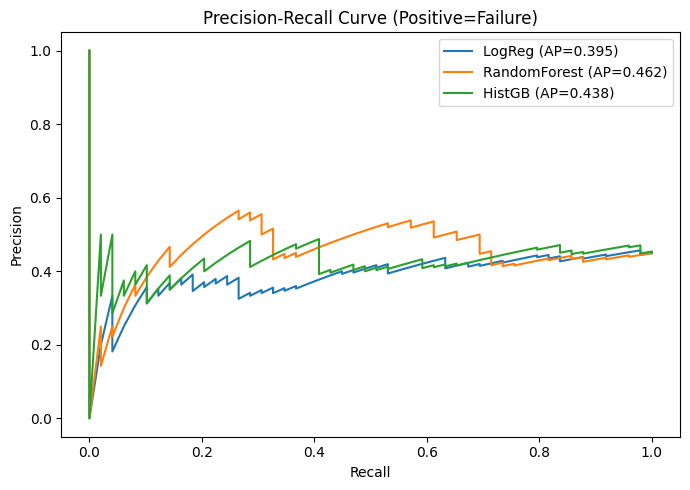

In [ ]:
plt.figure(figsize=(7, 5))
for name, obj in cache.items():
    y_prob = obj["y_prob"]
    if len(np.unique(y_true)) < 2:
        continue
    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

plt.title("Precision-Recall Curve (Positive=Failure)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## ---**Threshold selection untuk Recall target**---

In [ ]:
RECALL_TARGET = 0.90
THRESHOLDS = np.linspace(0.01, 0.99, 99)

tune_rows = []
for name, model in models.items():
    if not hasattr(model, "predict_proba"):
        continue
    y_prob = model.predict_proba(X_test)[:, 1]

    best = None
    for t in THRESHOLDS:
        y_pred = (y_prob >= t).astype(int)
        rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        if rec >= RECALL_TARGET:
            if (best is None) or (t > best["threshold"]):
                best = {"model": name, "threshold": t, "recall": rec, "precision": prec, "f1": f1}

    if best is None:
        best_rec = -1
        best_alt = None
        for t in THRESHOLDS:
            y_pred = (y_prob >= t).astype(int)
            rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
            prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
            f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
            if rec > best_rec:
                best_rec = rec
                best_alt = {"model": name, "threshold": t, "recall": rec, "precision": prec, "f1": f1,
                            "note": "Tidak mencapai recall target; ini recall maksimum di grid"}
        tune_rows.append(best_alt)
    else:
        best["note"] = "Memenuhi recall target"
        tune_rows.append(best)

tune_df = pd.DataFrame(tune_rows).sort_values(["recall", "precision"], ascending=False)
display(tune_df)

,model,threshold,recall,precision,f1,note
1,RandomForest,0.41,0.959184,0.443396,0.606452,Memenuhi recall target
2,HistGB,0.06,0.938776,0.464646,0.621622,Memenuhi recall target
0,LogReg,0.25,0.918367,0.445545,0.600000,Memenuhi recall target


## --- **Analisis** ---

Dari **PR curve** dan metrik test (failure rate ≈ **0.4495**), urutan performa adalah **RandomForest** terbaik (**PR-AUC 0.462**), lalu **HistGB** (**0.438**), dan **LogReg** terendah (**0.395**)—semuanya hanya **sedikit** di atas baseline proporsi kelas, jadi sinyal prediksi masih **lemah**. Pada threshold **0.5**, `RandomForest` paling seimbang (precision **0.528**, recall **0.571**, TP=28, FN=21), sedangkan `HistGB` (precision **0.426**, recall **0.408**) dan `LogReg` (precision **0.325**, recall **0.265**) lebih banyak melewatkan failure. Jika targetnya **recall tinggi**, threshold bisa diturunkan agar recall ~**0.92–0.96** (mis. `RandomForest` ~**0.41**, `HistGB` ~**0.06**, `LogReg` ~**0.25**), tetapi precision turun ke ~**0.44–0.46** (false alarm naik).

# **Threshold & kebijakan alarm**

## ---**Pilih model untuk scoring risiko (probability of failure)**---

In [ ]:
model = None
if "best_model" in globals():
    model = best_model
    model_name = "best_model"
elif "pipe_hgb" in globals():
    model = pipe_hgb
    model_name = "HistGB"
elif "pipe_rf" in globals():
    model = pipe_rf
    model_name = "RandomForest"
elif "pipe_lr" in globals():
    model = pipe_lr
    model_name = "LogReg"
elif "clf" in globals():
    model = clf
    model_name = "clf"

print("Model dipakai:", model_name)
if model is None:
    raise NameError("Tidak menemukan model. Pastikan kamu sudah fit pipe_lr/pipe_rf/pipe_hgb (atau set best_model).")

if not hasattr(model, "predict_proba"):
    raise ValueError("Model tidak punya predict_proba, tidak bisa bikin risiko/probability.")

if "X_test" not in globals():
    raise NameError("X_test belum ada. Jalankan time-based split + modeling dulu.")

Model dipakai: best_model


## ---**Buat risk table di TEST set**---

In [ ]:
if "test_df" in globals():
    meta = test_df[["Machine_ID", "Date"]].copy()
elif "test_meta" in globals():
    meta = test_meta[["Machine_ID", "Date"]].copy()
else:
    raise NameError("Tidak menemukan test_df atau test_meta yang berisi Machine_ID & Date.")

meta["Date"] = pd.to_datetime(meta["Date"], dayfirst=True, errors="coerce")

risk = model.predict_proba(X_test)[:, 1]
risk_df = meta.reset_index(drop=True).copy()
risk_df["risk"] = risk

if "y_test" in globals():
    risk_df["y_true"] = np.asarray(y_test).astype(int)

print("Risk table preview:")
display(risk_df.head(10))
print("Risk summary:")
display(risk_df["risk"].describe())

Risk table preview:


,Machine_ID,Date,risk,y_true
0,Makino-L2-Unit1-2015,2022-05-02,0.461736,0
1,Makino-L2-Unit1-2015,2022-05-02,0.497977,0
2,Makino-L1-Unit1-2013,2022-05-02,0.466809,0
3,Makino-L3-Unit1-2015,2022-05-02,0.597149,1
4,Makino-L3-Unit1-2015,2022-05-03,0.463819,0
5,Makino-L3-Unit1-2015,2022-05-03,0.441224,1
6,Makino-L3-Unit1-2015,2022-05-03,0.652107,0
7,Makino-L3-Unit1-2015,2022-05-03,0.432001,1
8,Makino-L1-Unit1-2013,2022-05-03,0.482627,0
9,Makino-L2-Unit1-2015,2022-05-03,0.537416,0


Risk summary:


,risk
count,109.000000
mean,0.498606
std,0.054383
min,0.363994
25%,0.463819
50%,0.497961
75%,0.539862
max,0.652107


## ---**Kebijakan alarm: risk > T => masuk daftar inspeksi**---

In [ ]:
T = 0.5
risk_df["alert"] = (risk_df["risk"] > T).astype(int)

print("Threshold T =", T)
print("Jumlah alert (records):", int(risk_df["alert"].sum()))
print("Proporsi alert:", round(risk_df["alert"].mean() * 100, 2), "%")

if "y_true" in risk_df.columns:
    tp = int(((risk_df["alert"] == 1) & (risk_df["y_true"] == 1)).sum())
    fp = int(((risk_df["alert"] == 1) & (risk_df["y_true"] == 0)).sum())
    fn = int(((risk_df["alert"] == 0) & (risk_df["y_true"] == 1)).sum())
    print("TP:", tp, "FP:", fp, "FN:", fn)


Threshold T = 0.5
Jumlah alert (records): 53
Proporsi alert: 48.62 %
TP: 28 FP: 25 FN: 21


## ---**Simulasi beban inspeksi: mesin per hari (unique Machine_ID)**---

In [ ]:
risk_df["day"] = risk_df["Date"].dt.floor("D")

inspections_per_day = (
    risk_df[risk_df["alert"] == 1]
    .groupby("day")["Machine_ID"]
    .nunique()
    .rename("machines_to_inspect")
    .reset_index()
    .sort_values("day")
)

print("Preview inspections/day:")
display(inspections_per_day.head(10))

print("Ringkasan inspections/day:")
if len(inspections_per_day) > 0:
    display(inspections_per_day["machines_to_inspect"].describe())
else:
    print("Tidak ada alert pada threshold ini (0 mesin diinspeksi).")

Preview inspections/day:


,day,machines_to_inspect
0,2022-05-02,1
1,2022-05-03,2
2,2022-05-04,2
3,2022-05-06,3
4,2022-05-07,2
5,2022-05-09,1
6,2022-05-10,2
7,2022-05-11,2
8,2022-05-12,3
9,2022-05-13,2


Ringkasan inspections/day:


,machines_to_inspect
count,24.000000
mean,1.625000
std,0.710939
min,1.000000
25%,1.000000
50%,1.500000
75%,2.000000
max,3.000000


## ---**Simulasi multi-threshold: rata-rata mesin/hari**---

In [ ]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
rows = []

for t in thresholds:
    alert = (risk_df["risk"] > t).astype(int)
    tmp = risk_df.copy()
    tmp["alert"] = alert

    per_day = (
        tmp[tmp["alert"] == 1]
        .groupby("day")["Machine_ID"]
        .nunique()
    )
    avg_per_day = per_day.mean() if len(per_day) else 0.0
    p90_per_day = per_day.quantile(0.90) if len(per_day) else 0.0
    max_per_day = per_day.max() if len(per_day) else 0.0

    if "y_true" in tmp.columns:
        tp = int(((tmp["alert"] == 1) & (tmp["y_true"] == 1)).sum())
        fp = int(((tmp["alert"] == 1) & (tmp["y_true"] == 0)).sum())
        fn = int(((tmp["alert"] == 0) & (tmp["y_true"] == 1)).sum())
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
    else:
        precision, recall = np.nan, np.nan

    rows.append({
        "T": t,
        "alerts_records": int(alert.sum()),
        "avg_machines_per_day": float(avg_per_day),
        "p90_machines_per_day": float(p90_per_day),
        "max_machines_per_day": float(max_per_day),
        "precision_record_level": precision,
        "recall_record_level": recall
    })

sim_df = pd.DataFrame(rows).sort_values("T")
display(sim_df)

,T,alerts_records,avg_machines_per_day,p90_machines_per_day,max_machines_per_day,precision_record_level,recall_record_level
0,0.1,109,1.9375,3.0,3.0,0.449541,1.000000
1,0.2,109,1.9375,3.0,3.0,0.449541,1.000000
2,0.3,109,1.9375,3.0,3.0,0.449541,1.000000
3,0.4,107,1.9375,3.0,3.0,0.439252,0.959184
4,0.5,53,1.6250,2.7,3.0,0.528302,0.571429
5,0.6,3,1.0000,1.0,1.0,0.000000,0.000000
6,0.7,0,0.0000,0.0,0.0,0.000000,0.000000


## ---**Analisis**---

Dengan `best_model`, skor `risk` pada 109 record test **rapat di sekitar 0.5** (mean **0.4986**, std **0.0544**, max **0.652**), sehingga threshold sangat menentukan jumlah alert. Pada `T=0.5` muncul **53 alert** (48.6%) dengan **TP=28, FP=25, FN=21** → precision **0.528** dan recall **0.571**; beban inspeksi harian masih moderat: rata-rata **~1.63 mesin/hari** (p90 **~2.7**, max **3**, selama 24 hari). `T=0.1–0.3` menandai hampir semua record (recall **1.0** tapi precision turun ke baseline ~**0.45** dan inspeksi naik ~**1.94 mesin/hari**), sedangkan `T≥0.6` terlalu ketat (hampir tidak ada alert dan recall **0**). Jadi, `T=0.5` paling seimbang untuk beban vs akurasi, sementara `T≈0.4` cocok jika prioritas utama adalah **recall tinggi** (dengan lebih banyak false alarm).

# **Interpretasi**

## ---**Pilih model + scoring risk di TEST**---

In [ ]:
model = None
model_name = None
if "best_model" in globals():
    model, model_name = best_model, "best_model"
elif "pipe_hgb" in globals():
    model, model_name = pipe_hgb, "HistGB"
elif "pipe_rf" in globals():
    model, model_name = pipe_rf, "RandomForest"
elif "pipe_lr" in globals():
    model, model_name = pipe_lr, "LogReg"
elif "clf" in globals():
    model, model_name = clf, "clf"

print("Model dipakai:", model_name)
if model is None:
    raise NameError("Tidak menemukan model. Pastikan sudah fit pipe_hgb/pipe_rf/pipe_lr (atau best_model).")

if "X_test" not in globals() or "y_test" not in globals():
    raise NameError("X_test / y_test belum ada. Jalankan time-based split + modeling dulu.")

if not hasattr(model, "predict_proba"):
    raise ValueError("Model tidak punya predict_proba. Tidak bisa bikin risk/probability.")

if "test_df" not in globals():
    raise NameError("test_df tidak ada. Simpan test_df saat split waktu supaya bisa tampilkan Machine_ID & Date.")

meta = test_df[["Machine_ID", "Date"]].copy()
meta["Date"] = pd.to_datetime(meta["Date"], dayfirst=True, errors="coerce")

y_true = np.asarray(y_test).astype(int)
risk = model.predict_proba(X_test)[:, 1]

risk_df = meta.reset_index(drop=True).copy()
risk_df["risk"] = risk
risk_df["y_true"] = y_true

display(risk_df.head())
print("Risk summary:")
display(risk_df["risk"].describe())

Model dipakai: best_model


,Machine_ID,Date,risk,y_true
0,Makino-L2-Unit1-2015,2022-05-02,0.461736,0
1,Makino-L2-Unit1-2015,2022-05-02,0.497977,0
2,Makino-L1-Unit1-2013,2022-05-02,0.466809,0
3,Makino-L3-Unit1-2015,2022-05-02,0.597149,1
4,Makino-L3-Unit1-2015,2022-05-03,0.463819,0


Risk summary:


,risk
count,109.000000
mean,0.498606
std,0.054383
min,0.363994
25%,0.463819
50%,0.497961
75%,0.539862
max,0.652107


## ---**Feature importance (Permutation Importance, fokus sensor)**---

In [ ]:
from sklearn.inspection import permutation_importance

def build_Xy_from_df(df_in, target_col_guess=None):
    df_in = df_in.copy()

    if target_col_guess and target_col_guess in df_in.columns:
        target_col = target_col_guess
    elif "y_next" in df_in.columns:
        target_col = "y_next"
    elif "is_failure" in df_in.columns:
        target_col = "is_failure"
    else:
        df_in["is_failure"] = (df_in["Downtime"].astype(str).str.strip() == "Machine_Failure").astype(int)
        target_col = "is_failure"

    y = df_in[target_col].astype(int)

    leak_cols = {"Downtime", "is_failure", "y_next", "next_date"}
    drop_cols = [target_col] + [c for c in leak_cols if c in df_in.columns and c != target_col]

    X = df_in.drop(columns=[c for c in drop_cols if c in df_in.columns])

    if "Date" in X.columns:
        X = X.drop(columns=["Date"])

    return X, y, target_col

if "X_train" in globals():
    X_train_raw = X_train.copy()
else:
    X_train_raw, _, _ = build_Xy_from_df(train_df)

X_test_raw = X_test.copy()

print("X_train_raw shape:", X_train_raw.shape, "| X_test_raw shape:", X_test_raw.shape)

SCORING = "average_precision"

perm = permutation_importance(
    model, X_test_raw, y_true,
    scoring=SCORING,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

imp_df = pd.DataFrame({
    "feature": X_test_raw.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(f"Top 20 importance (scoring={SCORING}):")
display(imp_df.head(20))

exclude_numeric = {"year","month","day","dayofweek","gap_days","days_to_next"}
sensor_cols = [
    c for c in X_test_raw.select_dtypes(include=["number"]).columns
    if c not in exclude_numeric
]

sensor_imp = imp_df[imp_df["feature"].isin(sensor_cols)].copy().sort_values("importance_mean", ascending=False)

print("\nTop sensor (paling pengaruh ke ranking risiko):")
display(sensor_imp.head(15))

X_train_raw shape: (2385, 127) | X_test_raw shape: (109, 127)
Top 20 importance (scoring=average_precision):


,feature,importance_mean,importance_std
22,Coolant_Pressure(bar)_lag1,0.011526,0.002579
2,Hydraulic_Pressure(bar),0.009453,0.009505
96,Torque(Nm)_roll3D_std,0.009080,0.005590
98,Torque(Nm)_roll7D_std,0.009002,0.005336
91,Voltage(volts)_roll3D_mean,0.008616,0.005116
99,Cutting(kN)_roll3D_mean,0.008545,0.001818
41,Tool_Vibration(µm)_lag2,0.007765,0.002899
74,Hydraulic_Oil_Temperature(°C)_roll7D_std,0.007270,0.003323
93,Voltage(volts)_roll7D_mean,0.006317,0.002789
66,Air_System_Pressure(bar)_roll7D_std,0.006207,0.002358



Top sensor (paling pengaruh ke ranking risiko):


,feature,importance_mean,importance_std
22,Coolant_Pressure(bar)_lag1,0.011526,0.002579
2,Hydraulic_Pressure(bar),0.009453,0.009505
96,Torque(Nm)_roll3D_std,0.009080,0.005590
98,Torque(Nm)_roll7D_std,0.009002,0.005336
91,Voltage(volts)_roll3D_mean,0.008616,0.005116
99,Cutting(kN)_roll3D_mean,0.008545,0.001818
41,Tool_Vibration(µm)_lag2,0.007765,0.002899
74,Hydraulic_Oil_Temperature(°C)_roll7D_std,0.007270,0.003323
93,Voltage(volts)_roll7D_mean,0.006317,0.002789
66,Air_System_Pressure(bar)_roll7D_std,0.006207,0.002358


## ---**Contoh 5 kasus risiko tinggi + nilai sensor yang mendukung**---

In [ ]:
TOP_K_CASES = 5
TOP_K_FEATURES = 8

train_num = X_train_raw.select_dtypes(include=["number"]).copy()
train_mean = train_num.mean()
train_std = train_num.std(ddof=1).replace(0, np.nan)

top_cases = risk_df.sort_values("risk", ascending=False).head(TOP_K_CASES).reset_index(drop=True)
display(top_cases)

idxs = risk_df.sort_values("risk", ascending=False).head(TOP_K_CASES).index.to_list()

for rank, idx in enumerate(idxs, start=1):
    row_meta = risk_df.loc[idx, ["Machine_ID", "Date", "risk", "y_true"]]
    print(f"--- Kasus #{rank} | Machine_ID={row_meta['Machine_ID']} | Date={row_meta['Date'].date() if pd.notna(row_meta['Date']) else row_meta['Date']} | risk={row_meta['risk']:.4f} | y_true={int(row_meta['y_true'])} ---")

    x_row = X_test_raw.iloc[idx]

    x_num = x_row[sensor_cols].astype(float)

    z = (x_num - train_mean[sensor_cols]) / train_std[sensor_cols]
    z = z.replace([np.inf, -np.inf], np.nan)

    support = pd.DataFrame({
        "feature": sensor_cols,
        "value": x_num.values,
        "train_mean": train_mean[sensor_cols].values,
        "train_std": train_std[sensor_cols].values,
        "z_score": z.values,
        "abs_z": np.abs(z.values)
    }).sort_values("abs_z", ascending=False).head(TOP_K_FEATURES)

    cat_show = {}
    for c in ["Machine_ID", "Assembly_Line_No"]:
        if c in test_df.columns:
            cat_show[c] = test_df.iloc[idx][c]
    if cat_show:
        print("Kategori:", cat_show)

    display(support[["feature","value","train_mean","train_std","z_score"]])

,Machine_ID,Date,risk,y_true
0,Makino-L3-Unit1-2015,2022-05-03,0.652107,0
1,Makino-L2-Unit1-2015,2022-05-13,0.618491,0
2,Makino-L2-Unit1-2015,2022-05-06,0.602690,0
3,Makino-L3-Unit1-2015,2022-05-02,0.597149,1
4,Makino-L3-Unit1-2015,2022-05-04,0.594683,0


--- Kasus #1 | Machine_ID=Makino-L3-Unit1-2015 | Date=2022-05-03 | risk=0.6521 | y_true=0 ---
Kategori: {'Machine_ID': 'Makino-L3-Unit1-2015', 'Assembly_Line_No': 'Shopfloor-L3'}


,feature,value,train_mean,train_std,z_score
86,Voltage(volts)_roll7D_mean,368.865455,348.986665,7.041719,2.823002
16,Coolant_Pressure(bar)_lag2,6.960636,4.948133,0.978801,2.056089
69,Spindle_Bearing_Temperature(°C)_roll3D_std,2.256534,3.611128,0.662442,-2.044848
59,Air_System_Pressure(bar)_roll7D_std,0.489999,0.393808,0.049465,1.944638
47,Cutting(kN)_delta1,1.510000,0.000172,0.777231,1.942574
119,Cutting(kN)_dev_from_base,1.125379,-0.026297,0.618540,1.861926
65,Hydraulic_Oil_Temperature(°C)_roll3D_std,4.937976,3.551297,0.753674,1.839894
42,Torque(Nm)_lag1,14.202890,25.245390,6.034811,-1.829801


--- Kasus #2 | Machine_ID=Makino-L2-Unit1-2015 | Date=2022-05-13 | risk=0.6185 | y_true=0 ---
Kategori: {'Machine_ID': 'Makino-L2-Unit1-2015', 'Assembly_Line_No': 'Shopfloor-L2'}


,feature,value,train_mean,train_std,z_score
78,Tool_Vibration(µm)_roll7D_mean,31.782276,25.349963,1.036661,6.204836
58,Air_System_Pressure(bar)_roll7D_mean,6.298092,6.500561,0.060206,-3.362959
69,Spindle_Bearing_Temperature(°C)_roll3D_std,5.533986,3.611128,0.662442,2.902680
76,Tool_Vibration(µm)_roll3D_mean,30.052000,25.356026,1.660831,2.827486
29,Spindle_Bearing_Temperature(°C)_delta1,-14.200000,0.003899,5.198769,-2.732166
81,Spindle_Speed(RPM)_roll3D_std,1230.020610,3519.036757,876.898928,-2.610353
87,Voltage(volts)_roll7D_std,31.123800,44.205008,5.138038,-2.545954
85,Voltage(volts)_roll3D_std,23.849528,43.748248,7.950446,-2.502843


...

,feature,value,train_mean,train_std,z_score
58,Air_System_Pressure(bar)_roll7D_mean,6.670891,6.500561,0.060206,2.829117
64,Hydraulic_Oil_Temperature(°C)_roll3D_mean,44.775000,47.635814,1.039201,-2.752898
90,Torque(Nm)_roll7D_mean,21.509797,25.229492,1.391020,-2.674077
38,Spindle_Speed(RPM)_delta1,11759.000000,4.251992,4732.013903,2.484090
105,Hydraulic_Oil_Temperature(°C)_dev_from_base,-8.540645,0.080110,3.710151,-2.323559
4,Hydraulic_Oil_Temperature(°C),39.200000,47.617191,3.696086,-2.277325
50,Hydraulic_Pressure(bar)_roll7D_mean,112.853445,101.301319,5.589878,2.066615
8,Spindle_Speed(RPM),27957.000000,20325.248218,3726.225701,2.048118


--- Kasus #4 | Machine_ID=Makino-L3-Unit1-2015 | Date=2022-05-02 | risk=0.5971 | y_true=1 ---
Kategori: {'Machine_ID': 'Makino-L3-Unit1-2015', 'Assembly_Line_No': 'Shopfloor-L3'}


,feature,value,train_mean,train_std,z_score
86,Voltage(volts)_roll7D_mean,373.475789,348.986665,7.041719,3.477720
17,Coolant_Pressure(bar)_delta1,3.907185,-0.002522,1.274337,3.068033
84,Voltage(volts)_roll3D_mean,384.577143,348.975120,11.741945,3.032038
61,Coolant_Temperature_roll3D_std,4.143612,8.148962,1.344172,-2.979790
48,Hydraulic_Pressure(bar)_roll3D_mean,125.038166,101.201778,8.195411,2.908504
64,Hydraulic_Oil_Temperature(°C)_roll3D_mean,50.171429,47.635814,1.039201,2.439966
24,Hydraulic_Oil_Temperature(°C)_lag1,56.300000,47.611950,3.692163,2.353106
68,Spindle_Bearing_Temperature(°C)_roll3D_mean,37.328571,35.041763,1.019562,2.242933


--- Kasus #5 | Machine_ID=Makino-L3-Unit1-2015 | Date=2022-05-04 | risk=0.5947 | y_true=0 ---
Kategori: {'Machine_ID': 'Makino-L3-Unit1-2015', 'Assembly_Line_No': 'Shopfloor-L3'}


,feature,value,train_mean,train_std,z_score
35,Tool_Vibration(µm)_delta1,-24.166000,-0.010644,9.036736,-2.673018
86,Voltage(volts)_roll7D_mean,366.446667,348.986665,7.041719,2.479508
63,Coolant_Temperature_roll7D_std,6.340927,8.330286,0.876007,-2.270940
19,Air_System_Pressure(bar)_lag2,7.372149,6.498918,0.397349,2.197639
77,Tool_Vibration(µm)_roll3D_std,8.853388,6.163745,1.244356,2.161473
33,Tool_Vibration(µm)_lag1,38.314000,25.381437,6.328011,2.043701
14,Hydraulic_Pressure(bar)_delta1,-79.136183,0.014619,39.368159,-2.010528
58,Air_System_Pressure(bar)_roll7D_mean,6.383940,6.500561,0.060206,-1.937040


## --- **Analisis** ---

Dengan `best_model`, skor `risk` pada test (109 record) **menumpuk di sekitar 0.5** (`mean` 0.499; `min` 0.364; `max` 0.652), jadi threshold sensitif dan banyak skor “borderline”. *Permutation importance* (average_precision) menunjukkan model paling dipengaruhi fitur **lag/rolling & volatility**, terutama `Coolant_Pressure(bar)_lag1`, `Hydraulic_Pressure(bar)`, `Torque(Nm)_roll3D_std`/`_roll7D_std`, `Voltage(volts)_roll3D_mean`/`_roll7D_mean`, `Cutting(kN)_roll3D_mean`, `Tool_Vibration(µm)_lag2`, `Hydraulic_Oil_Temperature(°C)_roll7D_std`, `Air_System_Pressure(bar)_roll7D_std`, serta `Spindle_Speed(RPM)_delta1`—artinya model “membaca” **perubahan/ketidakstabilan jangka pendek** lebih dari nilai mentah.

Pada contoh risiko tertinggi, banyak yang **false positive** karena ada anomali kuat tapi tidak berujung failure: misalnya `Makino-L3-Unit1-2015` 2022-05-03 (`risk` 0.652, `y_true` 0) dipicu `Voltage(volts)_roll7D_mean` tinggi, `Coolant_Pressure(bar)` tinggi, lonjakan `Cutting(kN)` (delta/dev), dan variabilitas tekanan udara; `Makino-L2-Unit1-2015` 2022-05-13 (`risk` 0.618, `y_true` 0) didorong `Tool_Vibration(µm)` rolling mean sangat tinggi; `Makino-L2-Unit1-2015` 2022-05-06 (`risk` 0.603, `y_true` 0) dipicu spike `Spindle_Speed(RPM)` dan pressure rolling tinggi. Satu contoh **true positive** (`Makino-L3-Unit1-2015` 2022-05-02, `risk` 0.597, `y_true` 1) lebih “konsisten” dengan kombinasi sinyal naik bersama: **voltage rolling tinggi + lonjakan coolant pressure + oil temperature tinggi + hydraulic pressure rolling tinggi**. Intinya, skor tinggi biasanya muncul saat ada **tegangan tinggi**, **vibrasi tool tinggi**, **spike RPM**, dan/atau **shift dari baseline**—tetapi kombinasi sinyal yang “serempak” lebih cenderung benar-benar failure, sedangkan anomali tunggal sering jadi false alarm.

# **Deliverable akhir**

## ---**Pilih model + dataset untuk deliverable**---

In [ ]:
model = None
model_name = None
if "best_model" in globals():
    model, model_name = best_model, "best_model"
elif "pipe_hgb" in globals():
    model, model_name = pipe_hgb, "HistGB"
elif "pipe_rf" in globals():
    model, model_name = pipe_rf, "RandomForest"
elif "pipe_lr" in globals():
    model, model_name = pipe_lr, "LogReg"
elif "clf" in globals():
    model, model_name = clf, "clf"

print("Model dipakai:", model_name)
if model is None:
    raise NameError("Tidak menemukan model. Pastikan sudah fit pipe_hgb/pipe_rf/pipe_lr (atau set best_model).")
if not hasattr(model, "predict_proba"):
    raise ValueError("Model tidak punya predict_proba, tidak bisa bikin risk_score.")

if "test_df" in globals():
    df_score = test_df.copy()
    print("df_score = test_df")
elif "df_model" in globals():
    df_score = df_model.copy()
    print("df_score = df_model")
else:
    df_score = df.copy()
    print("df_score = df (fallback)")

for c in ["Date", "Machine_ID"]:
    if c not in df_score.columns:
        raise NameError(f"Kolom '{c}' tidak ada di df_score.")

df_score["Date"] = pd.to_datetime(df_score["Date"], dayfirst=True, errors="coerce")
df_score = df_score.dropna(subset=["Date"]).copy()
df_score["day"] = df_score["Date"].dt.floor("D")

print("Rows scoring:", len(df_score))
print("Date range:", df_score["Date"].min(), "->", df_score["Date"].max())
display(df_score[["Date", "Machine_ID"]].head())

Model dipakai: best_model
df_score = test_df
Rows scoring: 109
Date range: 2022-05-02 00:00:00 -> 2022-06-19 00:00:00


,Date,Machine_ID
2385,2022-05-02,Makino-L2-Unit1-2015
2386,2022-05-02,Makino-L2-Unit1-2015
2387,2022-05-02,Makino-L1-Unit1-2013
2388,2022-05-02,Makino-L3-Unit1-2015
2389,2022-05-03,Makino-L3-Unit1-2015


## ---**Scoring risk_score per record**---

In [ ]:
if "y_next" in df_score.columns:
    target_col = "y_next"
elif "is_failure" in df_score.columns:
    target_col = "is_failure"
elif "Downtime" in df_score.columns:
    df_score["is_failure"] = (df_score["Downtime"].astype(str).str.strip() == "Machine_Failure").astype(int)
    target_col = "is_failure"
else:
    target_col = None

leak_cols = {"Downtime", "is_failure", "y_next", "next_date"}
drop_cols = set()
if target_col is not None:
    drop_cols.add(target_col)
drop_cols |= (leak_cols & set(df_score.columns))

feature_columns_for_model = X_train.columns.tolist()

X_score = df_score[feature_columns_for_model].copy()

for col in ['year', 'month', 'day', 'dayofweek', 'days_to_next']:
    if col in X_score.columns:
        if X_score[col].dtype == 'datetime64[ns]':

            X_score[col] = X_score[col].astype(int) / 10**9
        elif not pd.api.types.is_numeric_dtype(X_score[col]):
            X_score[col] = pd.to_numeric(X_score[col], errors='coerce')

print("X_score dtypes before predict_proba:")
print(X_score.dtypes)

risk = model.predict_proba(X_score)[:, 1]
score_tbl = df_score[["day", "Date", "Machine_ID"]].copy()
if "Assembly_Line_No" in df_score.columns:
    score_tbl["Assembly_Line_No"] = df_score["Assembly_Line_No"].values
score_tbl["risk_score"] = risk
if target_col is not None:
    score_tbl["y_true"] = df_score[target_col].astype(int).values

display(score_tbl.head())
display(score_tbl["risk_score"].describe())

X_score dtypes before predict_proba:
Machine_ID                       object
Assembly_Line_No                 object
Hydraulic_Pressure(bar)         float64
Coolant_Pressure(bar)           float64
Air_System_Pressure(bar)        float64
                                 ...   
Voltage(volts)_dev_from_base    float64
Torque(Nm)_baseline_exp         float64
Torque(Nm)_dev_from_base        float64
Cutting(kN)_baseline_exp        float64
Cutting(kN)_dev_from_base       float64
Length: 127, dtype: object


,day,Date,Machine_ID,Assembly_Line_No,risk_score,y_true
2385,2022-05-02,2022-05-02,Makino-L2-Unit1-2015,Shopfloor-L2,0.451106,0
2386,2022-05-02,2022-05-02,Makino-L2-Unit1-2015,Shopfloor-L2,0.484704,0
2387,2022-05-02,2022-05-02,Makino-L1-Unit1-2013,Shopfloor-L1,0.469963,0
2388,2022-05-02,2022-05-02,Makino-L3-Unit1-2015,Shopfloor-L3,0.596983,1
2389,2022-05-03,2022-05-03,Makino-L3-Unit1-2015,Shopfloor-L3,0.491484,0


,risk_score
count,109.000000
mean,0.500496
std,0.055450
min,0.364239
25%,0.463736
50%,0.496541
75%,0.539276
max,0.665617


## ---**Hitung top_drivers per record (sensor yang paling menyimpang)**---

In [ ]:
df_base = train_df.copy() if "train_df" in globals() else df_score.copy()
df_base["Date"] = pd.to_datetime(df_base["Date"], dayfirst=True, errors="coerce")
df_base = df_base.dropna(subset=["Date"]).copy()

num_cols = df_base.select_dtypes(include=["number"]).columns.tolist()
exclude_numeric = {"y_next", "is_failure", "year", "month", "day", "dayofweek", "gap_days", "days_to_next"}
raw_like = []
bad_tokens = ["_lag", "_roll", "_delta", "_baseline", "_dev", "_te"]
for c in num_cols:
    if c in exclude_numeric:
        continue
    if any(tok in c for tok in bad_tokens):
        continue
    raw_like.append(c)

sensor_cols = [c for c in raw_like if c in df_score.columns]
print("Sensor cols untuk drivers:", sensor_cols)

if len(sensor_cols) == 0:
    raise ValueError("Tidak menemukan sensor numerik raw untuk top_drivers. (Cek kolom / fitur engineered.)")

mu = df_base[sensor_cols].mean()
sd = df_base[sensor_cols].std(ddof=1).replace(0, np.nan)

Z = (df_score[sensor_cols] - mu) / sd
Z = Z.replace([np.inf, -np.inf], np.nan).fillna(0)

TOP_K_DRIVERS = 3

def topk_driver_string(z_row, cols, k=3):

    absz = np.abs(z_row)
    idx = np.argpartition(-absz, kth=min(k-1, len(absz)-1))[:k]
    idx = idx[np.argsort(-absz[idx])]
    parts = []
    for j in idx:
        parts.append(f"{cols[j]} (z={z_row[j]:.2f})")
    return "; ".join(parts)

cols_arr = np.array(sensor_cols)
Z_arr = Z[sensor_cols].to_numpy()

top_drivers = []
for i in range(Z_arr.shape[0]):
    top_drivers.append(topk_driver_string(Z_arr[i], cols_arr, k=TOP_K_DRIVERS))

score_tbl["top_drivers"] = top_drivers
display(score_tbl[["day", "Machine_ID", "risk_score", "top_drivers"]].head(10))

Sensor cols untuk drivers: ['Hydraulic_Pressure(bar)', 'Coolant_Pressure(bar)', 'Air_System_Pressure(bar)', 'Coolant_Temperature', 'Hydraulic_Oil_Temperature(°C)', 'Spindle_Bearing_Temperature(°C)', 'Spindle_Vibration(µm)', 'Tool_Vibration(µm)', 'Spindle_Speed(RPM)', 'Voltage(volts)', 'Torque(Nm)', 'Cutting(kN)']


,day,Machine_ID,risk_score,top_drivers
2385,2022-05-02,Makino-L2-Unit1-2015,0.451106,Coolant_Pressure(bar) (z=-1.88); Spindle_Beari...
2386,2022-05-02,Makino-L2-Unit1-2015,0.484704,Spindle_Vibration(µm) (z=2.41); Coolant_Pressu...
2387,2022-05-02,Makino-L1-Unit1-2013,0.469963,Voltage(volts) (z=-2.42); Hydraulic_Oil_Temper...
2388,2022-05-02,Makino-L3-Unit1-2015,0.596983,Coolant_Pressure(bar) (z=2.06); Tool_Vibration...
2389,2022-05-03,Makino-L3-Unit1-2015,0.491484,Air_System_Pressure(bar) (z=2.19); Torque(Nm) ...
2390,2022-05-03,Makino-L3-Unit1-2015,0.443231,Hydraulic_Oil_Temperature(°C) (z=-2.11); Volta...
2391,2022-05-03,Makino-L3-Unit1-2015,0.665617,Cutting(kN) (z=1.83); Hydraulic_Pressure(bar) ...
2392,2022-05-03,Makino-L3-Unit1-2015,0.437019,Torque(Nm) (z=-1.83); Hydraulic_Oil_Temperatur...
2393,2022-05-03,Makino-L1-Unit1-2013,0.482397,Air_System_Pressure(bar) (z=2.30); Spindle_Spe...
2394,2022-05-03,Makino-L2-Unit1-2015,0.535325,Hydraulic_Oil_Temperature(°C) (z=1.65); Hydrau...


## ---**Tabel harian (per hari, per mesin) = record dengan risk tertinggi**---

In [ ]:
daily_table = score_tbl.copy()

idx = daily_table.groupby(["day", "Machine_ID"])["risk_score"].idxmax()
daily_table = daily_table.loc[idx].sort_values(["day", "risk_score"], ascending=[True, False]).reset_index(drop=True)

cols_out = ["day", "Machine_ID", "risk_score", "top_drivers"]
if "Assembly_Line_No" in daily_table.columns:
    cols_out.insert(2, "Assembly_Line_No")
if "y_true" in daily_table.columns:
    cols_out.append("y_true")

daily_table = daily_table[cols_out].rename(columns={"day": "Date"})
display(daily_table.head(20))

,Date,Machine_ID,Assembly_Line_No,risk_score,top_drivers,y_true
0,2022-05-02,Makino-L3-Unit1-2015,Shopfloor-L3,0.596983,Coolant_Pressure(bar) (z=2.06); Tool_Vibration...,1
1,2022-05-02,Makino-L2-Unit1-2015,Shopfloor-L2,0.484704,Spindle_Vibration(µm) (z=2.41); Coolant_Pressu...,0
2,2022-05-02,Makino-L1-Unit1-2013,Shopfloor-L1,0.469963,Voltage(volts) (z=-2.42); Hydraulic_Oil_Temper...,0
3,2022-05-03,Makino-L3-Unit1-2015,Shopfloor-L3,0.665617,Cutting(kN) (z=1.83); Hydraulic_Pressure(bar) ...,0
4,2022-05-03,Makino-L2-Unit1-2015,Shopfloor-L2,0.560838,Tool_Vibration(µm) (z=-1.54); Coolant_Temperat...,1
5,2022-05-03,Makino-L1-Unit1-2013,Shopfloor-L1,0.482397,Air_System_Pressure(bar) (z=2.30); Spindle_Spe...,0
6,2022-05-04,Makino-L3-Unit1-2015,Shopfloor-L3,0.608253,Tool_Vibration(µm) (z=-1.77); Spindle_Vibratio...,0
7,2022-05-04,Makino-L2-Unit1-2015,Shopfloor-L2,0.568438,Coolant_Pressure(bar) (z=1.94); Spindle_Speed(...,1
8,2022-05-04,Makino-L1-Unit1-2013,Shopfloor-L1,0.487907,Spindle_Vibration(µm) (z=-2.32); Spindle_Beari...,1
9,2022-05-05,Makino-L1-Unit1-2013,Shopfloor-L1,0.491716,Spindle_Vibration(µm) (z=-2.19); Torque(Nm) (z...,0


## ---**Threshold alarm: risk_score > T => inspeksi (simulasi beban mesin/hari**---

In [ ]:
T = 0.5
daily_table["alert"] = (daily_table["risk_score"] > T).astype(int)

print("Threshold T =", T)
print("Total alerts (rows di daily_table):", int(daily_table["alert"].sum()))
print("Jumlah hari dengan alert:", daily_table.loc[daily_table["alert"]==1, "Date"].nunique())

inspections_per_day = (
    daily_table[daily_table["alert"] == 1]
    .groupby("Date")["Machine_ID"]
    .nunique()
    .rename("machines_to_inspect")
    .reset_index()
    .sort_values("Date")
)
display(inspections_per_day.head(10))
display(inspections_per_day["machines_to_inspect"].describe() if len(inspections_per_day) else pd.DataFrame({"machines_to_inspect":[0]}))

Threshold T = 0.5
Total alerts (rows di daily_table): 39
Jumlah hari dengan alert: 24


,Date,machines_to_inspect
0,2022-05-02,1
1,2022-05-03,2
2,2022-05-04,2
3,2022-05-06,3
4,2022-05-07,2
5,2022-05-09,1
6,2022-05-10,2
7,2022-05-11,2
8,2022-05-12,3
9,2022-05-13,2


,machines_to_inspect
count,24.000000
mean,1.625000
std,0.710939
min,1.000000
25%,1.000000
50%,1.500000
75%,2.000000
max,3.000000


## ---**Grafik: Trend failure vs average risk (harian)**---

,Date,avg_risk,max_risk,n_alert,n_machines,failures
0,2022-05-02,0.517217,0.596983,1,3,1
1,2022-05-03,0.569618,0.665617,2,3,1
2,2022-05-04,0.554866,0.608253,2,3,2
3,2022-05-05,0.463404,0.491716,0,3,0
4,2022-05-06,0.549749,0.604260,3,3,1
5,2022-05-07,0.536339,0.596944,2,3,0
6,2022-05-08,0.443387,0.443387,0,1,0
7,2022-05-09,0.473960,0.512866,1,3,2
8,2022-05-10,0.532733,0.590067,2,3,1
9,2022-05-11,0.544340,0.563705,2,2,0


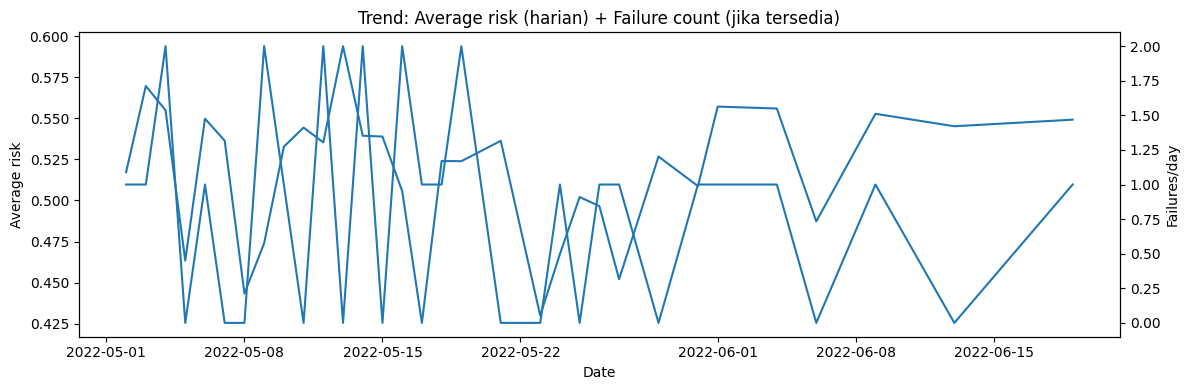

6B) Grafik: Top risk machines (rata-rata risk, periode scoring)


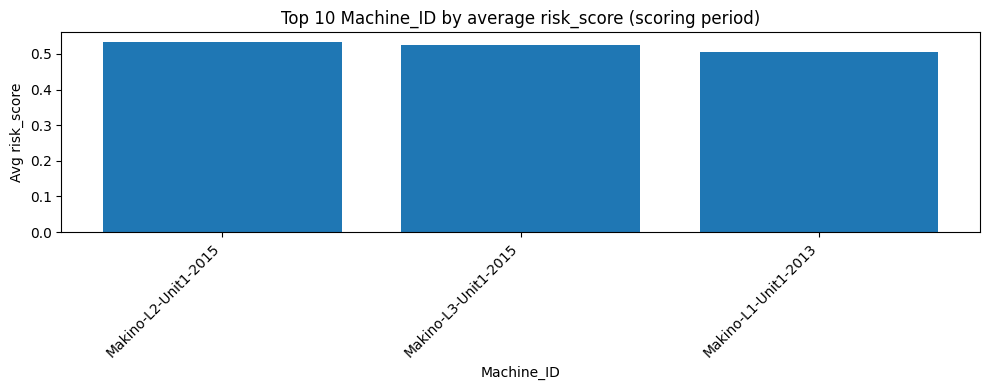

In [ ]:
trend = daily_table.groupby("Date").agg(
    avg_risk=("risk_score", "mean"),
    max_risk=("risk_score", "max"),
    n_alert=("alert", "sum"),
    n_machines=("Machine_ID", "nunique"),
).reset_index()

if "y_true" in daily_table.columns:
    trend["failures"] = daily_table.groupby("Date")["y_true"].sum().values
else:
    trend["failures"] = np.nan

display(trend.head(10))

plt.figure(figsize=(12, 4))
ax1 = plt.gca()
ax1.plot(trend["Date"], trend["avg_risk"])
ax1.set_title("Trend: Average risk (harian) + Failure count (jika tersedia)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Average risk")

if trend["failures"].notna().any():
    ax2 = ax1.twinx()
    ax2.plot(trend["Date"], trend["failures"])
    ax2.set_ylabel("Failures/day")

plt.tight_layout()
plt.show()

print("6B) Grafik: Top risk machines (rata-rata risk, periode scoring)") # Changed from section("...")

topN = 10
top_machines = (
    daily_table.groupby("Machine_ID")["risk_score"]
    .mean()
    .sort_values(ascending=False)
    .head(topN)
)

plt.figure(figsize=(10, 4))
plt.bar(top_machines.index.astype(str), top_machines.values)
plt.title(f"Top {topN} Machine_ID by average risk_score (scoring period)")
plt.xlabel("Machine_ID")
plt.ylabel("Avg risk_score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## ---**Rekomendasi tindakan (berdasarkan top_drivers dominan)**---

In [ ]:
alert_rows = daily_table[daily_table["alert"] == 1].copy()

def extract_driver_names(s):
    if pd.isna(s) or not isinstance(s, str):
        return []
    parts = [p.strip() for p in s.split(";")]
    names = []
    for p in parts:
        if "(" in p:
            names.append(p.split("(")[0].strip())
        else:
            names.append(p.strip())
    return names

driver_list = []
for s in alert_rows["top_drivers"].tolist():
    driver_list.extend(extract_driver_names(s))

driver_counts = pd.Series(driver_list).value_counts().rename_axis("sensor").reset_index(name="count")
display(driver_counts.head(10))

action_map = {
    "Hydraulic_Pressure": "Cek sistem hidrolik: kemungkinan kebocoran, kondisi pompa/valve, dan filter.",
    "Spindle_Vibration": "Cek vibrasi spindle: bearing, alignment, imbalance, dan kondisi mounting.",
    "Torque": "Cek beban/torque: tool wear, material load, misalignment, atau setting proses.",
    "Motor_Current": "Cek arus motor: overloading, friksi meningkat, wiring/koneksi, dan kondisi motor.",
    "Temperature": "Cek temperatur: pendinginan, pelumasan, airflow, dan heat buildup.",
    "Coolant_Pressure": "Cek coolant: tekanan/aliran, sumbatan, kebocoran, pompa coolant.",
    "Coolant_Temperature": "Cek coolant temperature: chiller/radiator, flow rate, dan kondisi coolant.",
    "Oil_Temperature": "Cek oil temperature: kualitas oli, pendinginan, dan friksi berlebih.",
    "Oil_Pressure": "Cek oil pressure: pompa oli, filter, kebocoran, dan viskositas.",
}

reco = []
for _, r in driver_counts.head(5).iterrows():
    sensor = r["sensor"]
    msg = action_map.get(sensor, f"Investigasi {sensor}: cek sensor, kalibrasi, dan komponen terkait proses.")
    reco.append({"sensor_driver": sensor, "count_in_alerts": int(r["count"]), "recommended_action": msg})

reco_df = pd.DataFrame(reco)
display(reco_df)

print("\nRingkasan singkat:")
if len(reco_df):
    for _, r in reco_df.iterrows():
        print(f"- {r['sensor_driver']}: {r['recommended_action']} (muncul {r['count_in_alerts']}x di alert)")
else:
    print("- Tidak ada alert pada threshold ini; pertimbangkan turunkan T atau gunakan window periode lain.")

,sensor,count
0,Torque,17
1,Cutting,13
2,Spindle_Vibration,12
3,Tool_Vibration,10
4,Coolant_Temperature,10
5,Voltage,9
6,Air_System_Pressure,9
7,Spindle_Speed,9
8,Hydraulic_Pressure,8
9,Coolant_Pressure,7


,sensor_driver,count_in_alerts,recommended_action
0,Torque,17,"Cek beban/torque: tool wear, material load, mi..."
1,Cutting,13,"Investigasi Cutting: cek sensor, kalibrasi, da..."
2,Spindle_Vibration,12,"Cek vibrasi spindle: bearing, alignment, imbal..."
3,Tool_Vibration,10,"Investigasi Tool_Vibration: cek sensor, kalibr..."
4,Coolant_Temperature,10,"Cek coolant temperature: chiller/radiator, flo..."



Ringkasan singkat:
- Torque: Cek beban/torque: tool wear, material load, misalignment, atau setting proses. (muncul 17x di alert)
- Cutting: Investigasi Cutting: cek sensor, kalibrasi, dan komponen terkait proses. (muncul 13x di alert)
- Spindle_Vibration: Cek vibrasi spindle: bearing, alignment, imbalance, dan kondisi mounting. (muncul 12x di alert)
- Tool_Vibration: Investigasi Tool_Vibration: cek sensor, kalibrasi, dan komponen terkait proses. (muncul 10x di alert)
- Coolant_Temperature: Cek coolant temperature: chiller/radiator, flow rate, dan kondisi coolant. (muncul 10x di alert)


## --- **Analisis** ---

Periode scoring **109 record (2022-05-02–2022-06-19)** untuk **3 mesin** menghasilkan **risk_score** yang rapat di sekitar **0.5** (mean **0.500**, std **0.055**, min **0.364**, max **0.666**, median **0.497**). Secara harian, **avg_risk** fluktuatif dan beberapa hari dengan **avg/max risk lebih tinggi** juga bertepatan dengan adanya failure (contoh awal Mei).

Dengan **threshold T=0.5**, ada **39 alert (machine-day)** di **24 hari**, sehingga beban inspeksi **~1.63 mesin/hari** (maks **3**). Mesin dengan **rata-rata risk tertinggi** didominasi **Makino-L2-Unit1-2015** dan **Makino-L3-Unit1-2015** (prioritas monitoring). Driver alert paling sering: **Torque (17x), Cutting (13x), Spindle_Vibration (12x), Tool_Vibration (10x), Coolant_Temperature (10x)** → fokus cek **beban proses/tool wear & cutting**, **stabilitas mekanik (bearing/alignment/imbalance, chatter)**, dan **sistem coolant (flow/chiller/kondisi coolant)**.